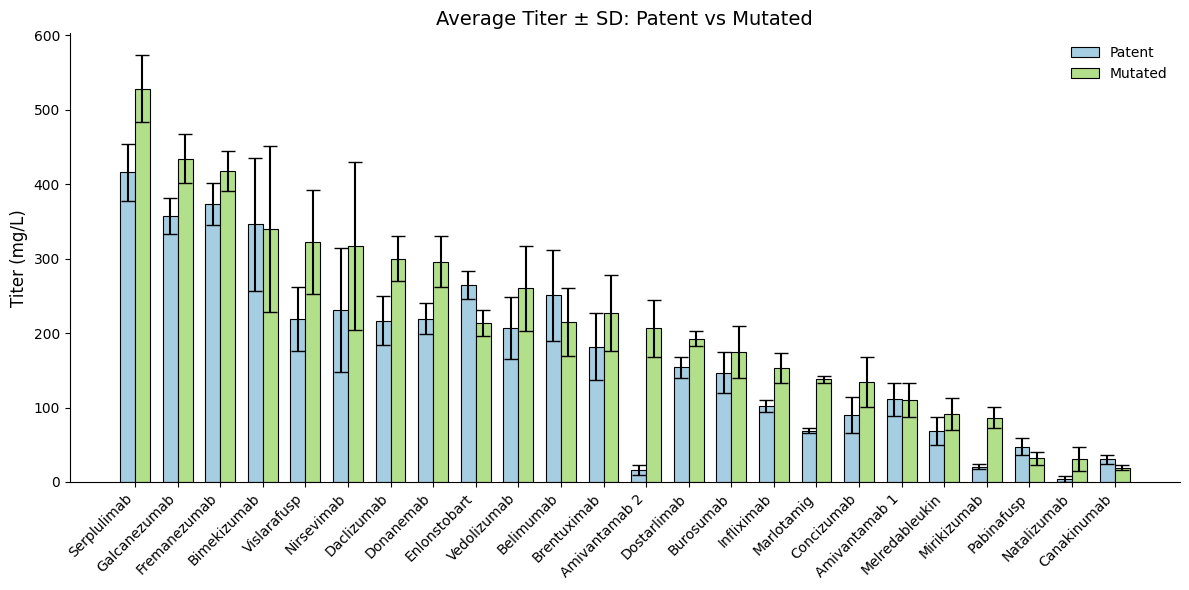

Titer columns used: ['Titer mg/L Rep 1', 'Titer mg/L Rep 2', 'Titer mg/L Rep 3']
   Base_Molecule  Patent_Mean  Patent_SD  Mutated_Mean  Mutated_SD
21   Serplulimab   416.238495  38.412255    528.510467   45.464378
13  Galcanezumab   356.964083  24.312621    434.114719   32.947781
12  Fremanezumab   373.672450  27.979786    418.112953   26.750330
3    Bimekizumab   345.958154  89.180962    339.852492  111.497950
23   Vislarafusp   218.870337  43.354192    322.343509   69.283866


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from IPython.display import display

# -----------------------------
# Load data
# -----------------------------
df = pd.read_excel("master-data.xlsx", engine="openpyxl")

# -----------------------------
# Required Molecule column
# -----------------------------
id_col = "Molecule"

if id_col not in df.columns:
    raise ValueError(
        f"Expected a '{id_col}' column, but it was not found. "
        f"Columns available: {list(df.columns)}"
    )

df = df.dropna(subset=[id_col]).copy()
df[id_col] = df[id_col].astype(str).str.strip()

# -----------------------------
# Parse base molecule name and variant
# Expects names ending in "Mutated" or "Patent"
# Example: "Amivantamab 1 Mutated" -> Base="Amivantamab 1", Variant="Mutated"
# -----------------------------
parsed = df[id_col].str.extract(r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$")

df["Base_Molecule"] = parsed["Base_Molecule"]
df["Variant"] = parsed["Variant"]

# Drop rows that do not match expected naming pattern
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

# -----------------------------
# Find titer replicate columns
# Matches: "Titer mg/L Rep 1", "Titer mg/L Rep 2", etc.
# -----------------------------
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

if len(titer_cols) == 0:
    raise ValueError(
        f"Could not find titer replicate columns.\n"
        f"Found titer_cols={titer_cols}\n"
        f"Check headers like 'Titer mg/L Rep 1'."
    )

# Sort columns by replicate number
def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

titer_cols = sorted(titer_cols, key=rep_num)

# -----------------------------
# Clean numeric columns
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": 0,
            "too low": 0,
            "TOO LOW": 0,
            "": np.nan,
            " ": np.nan
        }),
        errors="coerce"
    )

for c in titer_cols:
    df[c] = clean_numeric(df[c])

# -----------------------------
# Compute row-level mean and SD
# -----------------------------
df["Titer_Mean"] = df[titer_cols].mean(axis=1, skipna=True)
df["Titer_SD"] = df[titer_cols].std(axis=1, skipna=True)

# -----------------------------
# Aggregate in case there are duplicate Base_Molecule + Variant rows
# -----------------------------
summary_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(
          Titer_Mean=("Titer_Mean", "mean"),
          Titer_SD=("Titer_SD", "mean"),
          N_rows=("Titer_Mean", "size")
      )
      .reset_index()
)

# -----------------------------
# Pivot to wide format
# -----------------------------
mean_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Titer_Mean"
)

sd_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Titer_SD"
)

# Make sure both expected columns exist
for variant in ["Patent", "Mutated"]:
    if variant not in mean_wide.columns:
        mean_wide[variant] = np.nan
    if variant not in sd_wide.columns:
        sd_wide[variant] = np.nan

summary = pd.DataFrame({
    "Patent_Mean": mean_wide["Patent"],
    "Patent_SD": sd_wide["Patent"],
    "Mutated_Mean": mean_wide["Mutated"],
    "Mutated_SD": sd_wide["Mutated"]
}).reset_index()

# --------------------------------------------------
# Order molecules by MAX mean titer across Patent/Mutated
# --------------------------------------------------
summary["MaxMean"] = summary[["Patent_Mean", "Mutated_Mean"]].max(axis=1)
summary = summary.sort_values("MaxMean", ascending=False).drop(columns=["MaxMean"])

names = summary["Base_Molecule"].astype(str).tolist()
x = np.arange(len(names))
width = 0.35

# -----------------------------
# Plot settings
# -----------------------------
colors = {
    "Patent": "#A6CEE3",   # pastel blue
    "Mutated": "#B2DF8A"   # pastel green
}

fig, ax = plt.subplots(figsize=(12, 6))

# -----------------------------
# Plot bars
# -----------------------------
ax.bar(
    x - width / 2,
    summary["Patent_Mean"],
    width,
    yerr=summary["Patent_SD"],
    capsize=5,
    label="Patent",
    color=colors["Patent"],
    edgecolor="black",
    linewidth=0.8
)

ax.bar(
    x + width / 2,
    summary["Mutated_Mean"],
    width,
    yerr=summary["Mutated_SD"],
    capsize=5,
    label="Mutated",
    color=colors["Mutated"],
    edgecolor="black",
    linewidth=0.8
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_ylabel("Titer (mg/L)", fontsize=12)
ax.set_title("Average Titer ± SD: Patent vs Mutated", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Optional diagnostic printout
print("Titer columns used:", titer_cols)
print(summary.head())

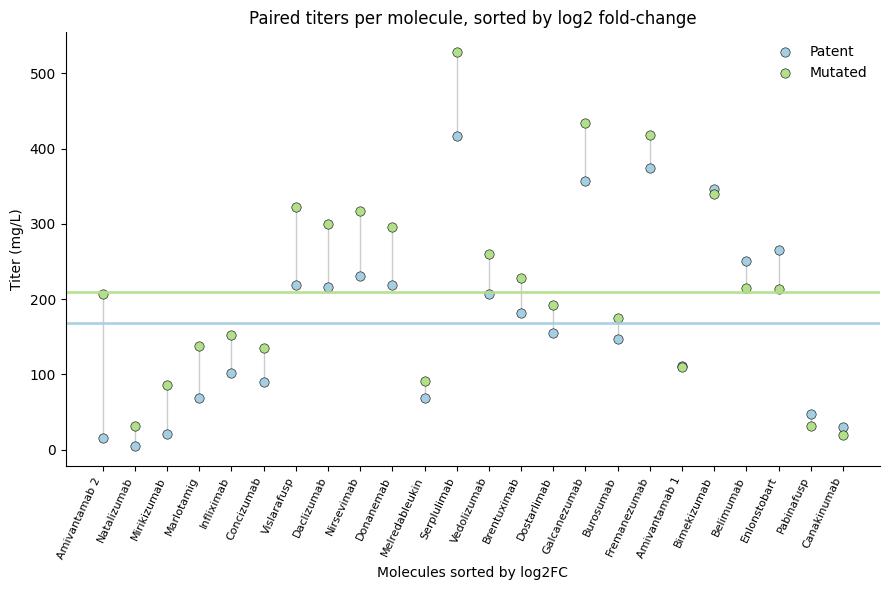

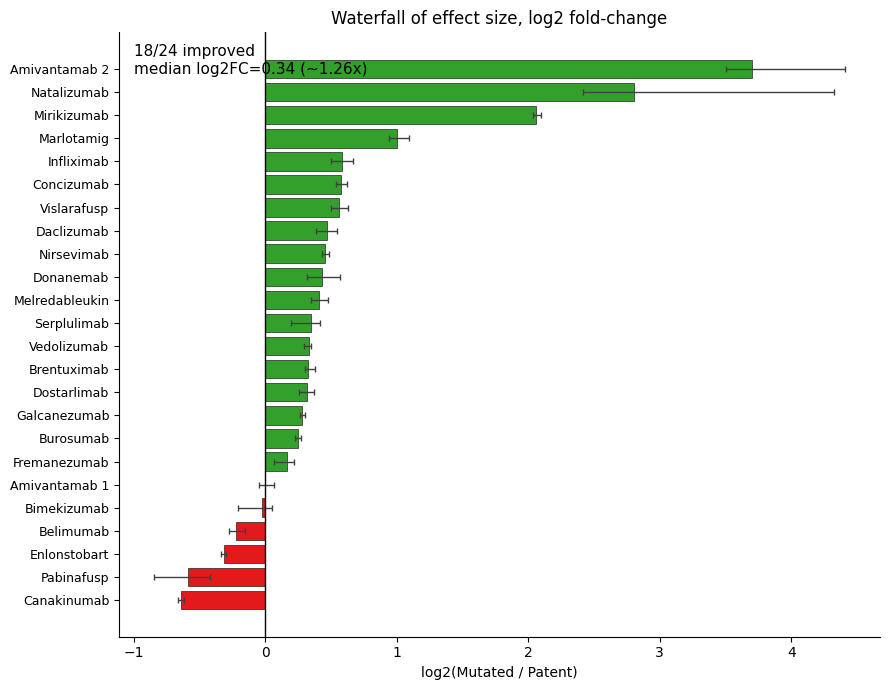

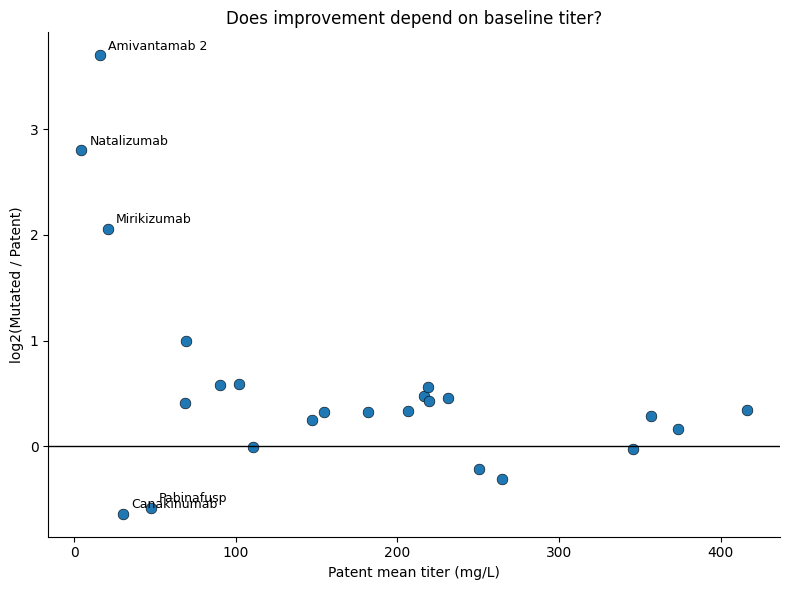

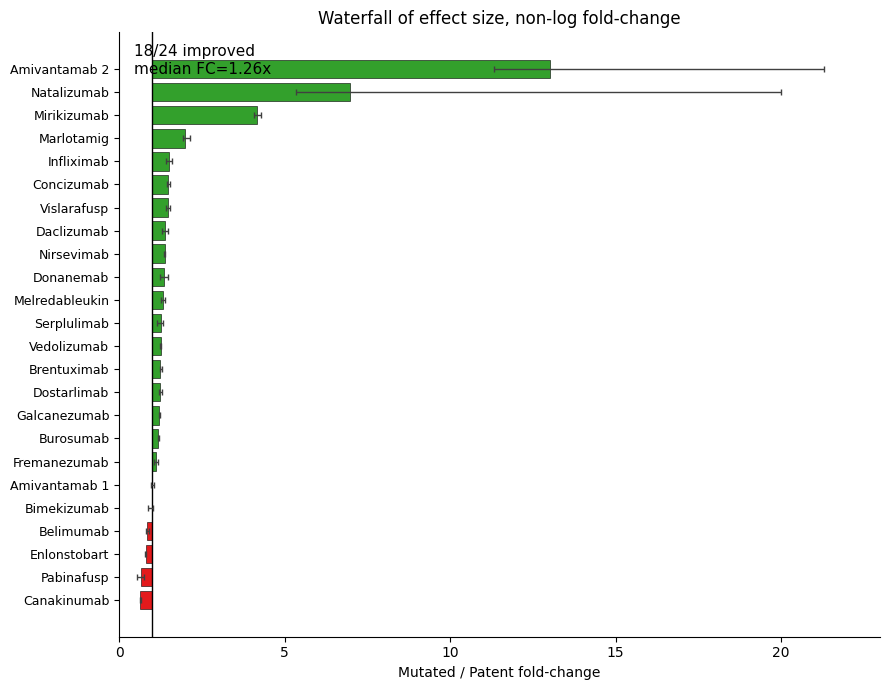

Saved:
 - Figure_Waterfall_FC_nonlog_bars_from_1_with_errorbars.pdf
Saved:
 - Figure_Paired_Slope.pdf
 - Figure_Waterfall_log2FC.pdf
 - Figure_BaselineVsChange.pdf

Titer columns used:
['Titer mg/L Rep 1', 'Titer mg/L Rep 2', 'Titer mg/L Rep 3']

Summary preview:
   Base_Molecule  Parental_Mean  Mutated_Mean  N_parent_vals  N_mutant_vals  \
0  Amivantamab 2      15.799506    206.309949              3              3   
1    Natalizumab       4.394343     30.926761              3              3   
2    Mirikizumab      20.660510     86.134258              3              3   
3     Marlotamig      68.946487    137.806694              3              3   
4     Infliximab     101.899989    152.778763              3              3   

     log2FC         FC  log2FC_ci_low  log2FC_ci_high  
0  3.703162  13.024556       3.502860        4.411821  
1  2.802830   6.978077       2.419271        4.321307  
2  2.057382   4.162303       2.032235        2.097374  
3  0.998638   1.998112       0.941013

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =============================
# User-configurable settings
# =============================
INPUT_FILE = "master-data.xlsx"
ID_COL = "Molecule"

# Variant labels in the new file
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

# How to treat "Too Low"
TOO_LOW_AS = np.nan   # recommended; set to 0 only if you have a defined reason

# In the new file, Rep 1 Patent corresponds to Rep 1 Mutated after pivoting by Base_Molecule
PAIRED_REPLICATES = True

# If you have an assay LLOQ, set it here, e.g. 1.0 mg/L. If None, pseudocount is data-derived.
ASSAY_LLOQ = None

# Output files
OUT_PAIRED = "Figure_Paired_Slope.pdf"
OUT_WATERFALL = "Figure_Waterfall_log2FC.pdf"
OUT_SCATTER = "Figure_BaselineVsChange.pdf"

# Plot styling
COLOR_PARENT = "#A6CEE3"
COLOR_MUT = "#B2DF8A"
COLOR_POS = "#33a02c"
COLOR_NEG = "#e31a1c"

# =============================
# Load / validate
# =============================
df = pd.read_excel(INPUT_FILE, engine="openpyxl")

if ID_COL not in df.columns:
    raise ValueError(f"Expected '{ID_COL}' column, but not found. Available: {list(df.columns)}")

df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

# =============================
# Parse Molecule into Base_Molecule and Variant
# Example:
# "Amivantamab 1 Mutated" -> Base_Molecule="Amivantamab 1", Variant="Mutated"
# "Amivantamab 1 Patent"  -> Base_Molecule="Amivantamab 1", Variant="Patent"
# =============================
parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()

# Keep only rows that matched the expected pattern
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

if df.empty:
    raise ValueError(
        "No rows matched the expected Molecule naming pattern ending in 'Mutated' or 'Patent'."
    )

# =============================
# Find titer replicate columns
# New format: "Titer mg/L Rep 1", "Titer mg/L Rep 2", etc.
# =============================
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

if len(titer_cols) == 0:
    raise ValueError(
        f"Could not find titer replicate columns.\n"
        f"Found titer_cols={titer_cols}\n"
        f"Expected headers like 'Titer mg/L Rep 1'."
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

titer_cols = sorted(titer_cols, key=rep_num)

# =============================
# Clean numeric columns
# =============================
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS,
            "too low": TOO_LOW_AS,
            "TOO LOW": TOO_LOW_AS,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

for c in titer_cols:
    df[c] = clean_numeric(df[c])

# =============================
# Aggregate to one row per Base_Molecule + Variant
# This handles accidental duplicate rows safely.
# =============================
df["Mean_row"] = df[titer_cols].mean(axis=1, skipna=True)

summary_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(
          Mean=("Mean_row", "mean"),
          N_rows=("Mean_row", "size")
      )
      .reset_index()
)

# Pivot means to wide format:
# Base_Molecule | Patent | Mutated
mean_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Mean"
)

for variant in [PARENT_LABEL, MUT_LABEL]:
    if variant not in mean_wide.columns:
        mean_wide[variant] = np.nan

summary = pd.DataFrame({
    "Base_Molecule": mean_wide.index,
    "Parental_Mean": mean_wide[PARENT_LABEL].values,
    "Mutated_Mean": mean_wide[MUT_LABEL].values
})

ID_SUMMARY_COL = "Base_Molecule"

# =============================
# Count numeric replicate values for QC / captions
# =============================
def count_numeric_values(g, variant):
    sub = g[g["Variant"] == variant]
    if sub.empty:
        return 0
    return int(np.isfinite(sub[titer_cols].values).sum())

counts = []
for name, g in df.groupby("Base_Molecule", dropna=False):
    counts.append({
        "Base_Molecule": name,
        "N_parent_vals": count_numeric_values(g, PARENT_LABEL),
        "N_mutant_vals": count_numeric_values(g, MUT_LABEL)
    })

counts_df = pd.DataFrame(counts)
summary = summary.merge(counts_df, on="Base_Molecule", how="left")

# =============================
# Choose pseudocount epsilon for fold-change stability
# =============================
if ASSAY_LLOQ is not None:
    eps = ASSAY_LLOQ / 2.0
else:
    min_pos = summary["Parental_Mean"].replace([0, np.inf, -np.inf], np.nan).dropna()
    min_pos = min_pos[min_pos > 0]
    eps = 0.01 * (min_pos.min() if len(min_pos) else 1.0)

summary["log2FC"] = np.log2(
    (summary["Mutated_Mean"] + eps) / (summary["Parental_Mean"] + eps)
)

summary["FC"] = (
    (summary["Mutated_Mean"] + eps) / (summary["Parental_Mean"] + eps)
)

# =============================
# Bootstrap CI for log2FC
# In new format, paired replicate-level log2FC is made by matching
# Patent Rep 1 with Mutated Rep 1, etc., for each Base_Molecule.
# =============================
def bootstrap_ci(values, n_boot=5000, ci=95, seed=0):
    """Nonparametric bootstrap CI for the median of values."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    boots = []

    for _ in range(n_boot):
        samp = rng.choice(values, size=len(values), replace=True)
        boots.append(np.nanmedian(samp))

    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)

    return lo, hi

ci_rows = []

for name, g in df.groupby("Base_Molecule", dropna=False):

    patent_rows = g[g["Variant"] == PARENT_LABEL]
    mutated_rows = g[g["Variant"] == MUT_LABEL]

    if patent_rows.empty or mutated_rows.empty:
        ci_rows.append({
            "Base_Molecule": name,
            "log2FC_ci_low": np.nan,
            "log2FC_ci_high": np.nan
        })
        continue

    vals = []

    if PAIRED_REPLICATES:
        # Pair titer replicate columns by rep number.
        # If duplicate rows exist, this loops through all available combinations by row index.
        # Usually there should be one Patent row and one Mutated row per Base_Molecule.
        for _, prow in patent_rows.iterrows():
            for _, mrow in mutated_rows.iterrows():
                for c in titer_cols:
                    pv = prow[c]
                    mv = mrow[c]
                    if np.isfinite(pv) and np.isfinite(mv):
                        vals.append(np.log2((mv + eps) / (pv + eps)))
    else:
        pvals = patent_rows[titer_cols].values.flatten()
        mvals = mutated_rows[titer_cols].values.flatten()

        pvals = pvals[np.isfinite(pvals)]
        mvals = mvals[np.isfinite(mvals)]

        if len(pvals) > 0 and len(mvals) > 0:
            vals.append(np.log2((np.mean(mvals) + eps) / (np.mean(pvals) + eps)))

    lo, hi = bootstrap_ci(vals, n_boot=2000, ci=95, seed=0)

    ci_rows.append({
        "Base_Molecule": name,
        "log2FC_ci_low": lo,
        "log2FC_ci_high": hi
    })

ci_df = pd.DataFrame(ci_rows)
summary = summary.merge(ci_df, on="Base_Molecule", how="left")

# =============================
# Sort by effect for cleaner plots
# =============================
summary_sorted = summary.sort_values("log2FC", ascending=False).reset_index(drop=True)

# ============================================================
# FIGURE 1: Sorted paired slope plot
# ============================================================
fig1, ax1 = plt.subplots(figsize=(9, 6))

x = np.arange(len(summary_sorted))
y0 = summary_sorted["Parental_Mean"].values
y1 = summary_sorted["Mutated_Mean"].values

# Draw paired lines
for i in range(len(x)):
    if np.isfinite(y0[i]) and np.isfinite(y1[i]):
        ax1.plot([x[i], x[i]], [y0[i], y1[i]], color="0.8", lw=1, zorder=1)

# Points
ax1.scatter(
    x, y0,
    s=45,
    color=COLOR_PARENT,
    edgecolor="k",
    linewidth=0.4,
    label=PARENT_LABEL,
    zorder=2
)

ax1.scatter(
    x, y1,
    s=45,
    color=COLOR_MUT,
    edgecolor="k",
    linewidth=0.4,
    label=MUT_LABEL,
    zorder=2
)

# Median lines
ax1.axhline(np.nanmedian(y0), color=COLOR_PARENT, lw=2, alpha=0.9)
ax1.axhline(np.nanmedian(y1), color=COLOR_MUT, lw=2, alpha=0.9)

ax1.set_title("Paired titers per molecule, sorted by log2 fold-change")
ax1.set_ylabel("Titer (mg/L)")
ax1.set_xlabel("Molecules sorted by log2FC")
ax1.set_xticks(x)
ax1.set_xticklabels(
    summary_sorted[ID_SUMMARY_COL].astype(str).tolist(),
    rotation=65,
    ha="right",
    fontsize=8
)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.legend(frameon=False, loc="upper right")

plt.tight_layout()
fig1.savefig(OUT_PAIRED)
plt.show()

# ============================================================
# FIGURE 2: Horizontal waterfall plot of log2FC
# ============================================================
fig2, ax2 = plt.subplots(figsize=(9, 7))

names = summary_sorted[ID_SUMMARY_COL].astype(str).tolist()
vals = summary_sorted["log2FC"].values
ypos = np.arange(len(vals))

colors = np.where(vals >= 0, COLOR_POS, COLOR_NEG)

ax2.barh(
    ypos,
    vals,
    color=colors,
    edgecolor="black",
    linewidth=0.4
)

# Optional CI error bars
lo = summary_sorted["log2FC_ci_low"].values
hi = summary_sorted["log2FC_ci_high"].values

xerr_left = vals - lo
xerr_right = hi - vals

valid_err = (
    np.isfinite(vals) &
    np.isfinite(xerr_left) &
    np.isfinite(xerr_right) &
    (xerr_left >= 0) &
    (xerr_right >= 0)
)

if valid_err.any():
    ax2.errorbar(
        vals[valid_err],
        ypos[valid_err],
        xerr=[xerr_left[valid_err], xerr_right[valid_err]],
        fmt="none",
        ecolor="0.25",
        elinewidth=1,
        capsize=2
    )

ax2.axvline(0, color="k", lw=1)
ax2.set_yticks(ypos)
ax2.set_yticklabels(names, fontsize=9)
ax2.invert_yaxis()

ax2.set_xlabel(f"log2({MUT_LABEL} / {PARENT_LABEL})")
ax2.set_title("Waterfall of effect size, log2 fold-change")

n_improved = int(np.sum(vals > 0))
n_total = int(np.sum(np.isfinite(vals)))
med = np.nanmedian(vals)

ax2.text(
    0.02,
    0.98,
    f"{n_improved}/{n_total} improved\nmedian log2FC={med:.2f} (~{2**med:.2f}x)",
    transform=ax2.transAxes,
    va="top",
    ha="left",
    fontsize=11
)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
fig2.savefig(OUT_WATERFALL)
plt.show()

# ============================================================
# FIGURE 3: Baseline vs improvement scatter
# ============================================================
fig3, ax3 = plt.subplots(figsize=(8, 6))

ax3.scatter(
    summary["Parental_Mean"],
    summary["log2FC"],
    s=60,
    color="#1f78b4",
    edgecolor="k",
    linewidth=0.4
)

ax3.axhline(0, color="k", lw=1)
ax3.set_xlabel(f"{PARENT_LABEL} mean titer (mg/L)")
ax3.set_ylabel(f"log2({MUT_LABEL} / {PARENT_LABEL})")
ax3.set_title("Does improvement depend on baseline titer?")

# Label a few extremes: top 3 and bottom 2 by log2FC
top_k, bottom_k = 3, 2
extremes = pd.concat(
    [summary_sorted.head(top_k), summary_sorted.tail(bottom_k)],
    axis=0
)

for _, r in extremes.iterrows():
    x0, y0 = r["Parental_Mean"], r["log2FC"]

    if np.isfinite(x0) and np.isfinite(y0):
        ax3.annotate(
            str(r[ID_SUMMARY_COL]),
            (x0, y0),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=9
        )

ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

plt.tight_layout()
fig3.savefig(OUT_SCATTER)
plt.show()
# ============================================================
# Non-log fold-change waterfall plot only
# Axis starts at 0, bars start at 1 and go left/right
# Includes error bars converted from log2FC CI
# ============================================================

OUT_WATERFALL_FC = "Figure_Waterfall_FC_nonlog_bars_from_1_with_errorbars.pdf"

# Make sure FC exists
if "FC" not in summary.columns:
    summary["FC"] = (
        (summary["Mutated_Mean"] + eps) / 
        (summary["Parental_Mean"] + eps)
    )

# Convert log2FC confidence intervals to non-log FC confidence intervals
summary["FC_ci_low"] = 2 ** summary["log2FC_ci_low"]
summary["FC_ci_high"] = 2 ** summary["log2FC_ci_high"]

# Sort by non-log fold-change
summary_sorted_fc = summary.sort_values("FC", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))

names = summary_sorted_fc[ID_SUMMARY_COL].astype(str).tolist()
vals = summary_sorted_fc["FC"].values
ypos = np.arange(len(vals))

colors = np.where(vals >= 1, COLOR_POS, COLOR_NEG)

# Bars start at 1:
# FC > 1 extends right
# FC < 1 extends left
ax.barh(
    ypos,
    vals - 1,
    left=1,
    color=colors,
    edgecolor="black",
    linewidth=0.4
)

# Add error bars in raw FC space
lo = summary_sorted_fc["FC_ci_low"].values
hi = summary_sorted_fc["FC_ci_high"].values

xerr_left = vals - lo
xerr_right = hi - vals

valid_err = (
    np.isfinite(vals) &
    np.isfinite(xerr_left) &
    np.isfinite(xerr_right) &
    (xerr_left >= 0) &
    (xerr_right >= 0)
)

if valid_err.any():
    ax.errorbar(
        vals[valid_err],
        ypos[valid_err],
        xerr=[xerr_left[valid_err], xerr_right[valid_err]],
        fmt="none",
        ecolor="0.25",
        elinewidth=1,
        capsize=2,
        zorder=3
    )

# No-change reference line
ax.axvline(1, color="k", lw=1)

ax.set_yticks(ypos)
ax.set_yticklabels(names, fontsize=9)
ax.invert_yaxis()

ax.set_xlabel(f"{MUT_LABEL} / {PARENT_LABEL} fold-change")
ax.set_title("Waterfall of effect size, non-log fold-change")

# Axis starts at 0, with padding on the right
xmax = np.nanmax([
    np.nanmax(vals),
    np.nanmax(hi)
])
ax.set_xlim(0, xmax * 1.08)

n_improved = int(np.sum(vals > 1))
n_total = int(np.sum(np.isfinite(vals)))
med_fc = np.nanmedian(vals)

ax.text(
    0.02,
    0.98,
    f"{n_improved}/{n_total} improved\nmedian FC={med_fc:.2f}x",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=11
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_WATERFALL_FC)
plt.show()

print("Saved:")
print(" -", OUT_WATERFALL_FC)
print("Saved:")
print(" -", OUT_PAIRED)
print(" -", OUT_WATERFALL)
print(" -", OUT_SCATTER)

print("\nTiter columns used:")
print(titer_cols)

print("\nSummary preview:")
print(summary_sorted.head())

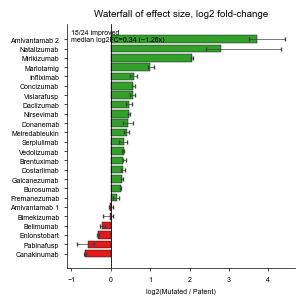

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =============================
# User-configurable settings
# =============================
INPUT_FILE = "master-data.xlsx"
ID_COL = "Molecule"

# Variant labels in the new file
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

# How to treat "Too Low"
TOO_LOW_AS = np.nan   # recommended; set to 0 only if you have a defined reason

# In this new file, Rep 1 Patent corresponds to Rep 1 Mutated after grouping by Base_Molecule
PAIRED_REPLICATES = True

# If you have an assay LLOQ, set it here, e.g. 1.0 mg/L. If None, pseudocount is data-derived.
ASSAY_LLOQ = None

# Output file
OUT_WATERFALL = "Figure_Waterfall_log2FC.svg"

# Plot styling
COLOR_POS = "#33a02c"
COLOR_NEG = "#e31a1c"

# Waterfall figure sizing
MM_TO_INCH = 1 / 25.4
WATERFALL_WIDTH_MM = 80
WATERFALL_HEIGHT_MM = 80
WATERFALL_FIGSIZE = (
    WATERFALL_WIDTH_MM * MM_TO_INCH,
    WATERFALL_HEIGHT_MM * MM_TO_INCH
)

# Waterfall font settings
WATERFALL_FONT = "Arial"
WATERFALL_TITLE_FONTSIZE = 7
WATERFALL_AXIS_FONTSIZE = 5
WATERFALL_TICK_FONTSIZE = 5
WATERFALL_TEXT_FONTSIZE = 5

# Keep SVG text editable rather than converting fonts to paths
plt.rcParams["svg.fonttype"] = "none"

# =============================
# Load / validate
# =============================
df = pd.read_excel(INPUT_FILE, engine="openpyxl")

if ID_COL not in df.columns:
    raise ValueError(f"Expected '{ID_COL}' column, but not found. Available: {list(df.columns)}")

df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

# =============================
# Parse Molecule into Base_Molecule and Variant
# =============================
parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()

df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

if df.empty:
    raise ValueError(
        "No rows matched the expected Molecule naming pattern ending in 'Mutated' or 'Patent'."
    )

# =============================
# Find replicate columns
# =============================
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

if len(titer_cols) == 0:
    raise ValueError(
        f"Could not find titer replicate columns.\n"
        f"Found titer_cols={titer_cols}\n"
        f"Expected headers like 'Titer mg/L Rep 1'."
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

titer_cols = sorted(titer_cols, key=rep_num)

# =============================
# Clean numeric columns
# =============================
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS,
            "too low": TOO_LOW_AS,
            "TOO LOW": TOO_LOW_AS,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

for c in titer_cols:
    df[c] = clean_numeric(df[c])

# =============================
# Aggregate to one row per Base_Molecule + Variant
# =============================
df["Mean_row"] = df[titer_cols].mean(axis=1, skipna=True)

summary_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(
          Mean=("Mean_row", "mean"),
          N_rows=("Mean_row", "size")
      )
      .reset_index()
)

mean_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Mean"
)

for variant in [PARENT_LABEL, MUT_LABEL]:
    if variant not in mean_wide.columns:
        mean_wide[variant] = np.nan

summary = pd.DataFrame({
    "Base_Molecule": mean_wide.index,
    "Parental_Mean": mean_wide[PARENT_LABEL].values,
    "Mutated_Mean": mean_wide[MUT_LABEL].values
})

ID_SUMMARY_COL = "Base_Molecule"

# =============================
# Choose pseudocount epsilon
# =============================
if ASSAY_LLOQ is not None:
    eps = ASSAY_LLOQ / 2.0
else:
    min_pos = summary["Parental_Mean"].replace([0, np.inf, -np.inf], np.nan).dropna()
    min_pos = min_pos[min_pos > 0]
    eps = 0.01 * (min_pos.min() if len(min_pos) else 1.0)

summary["log2FC"] = np.log2(
    (summary["Mutated_Mean"] + eps) /
    (summary["Parental_Mean"] + eps)
)

# =============================
# Bootstrap CI for log2FC
# =============================
def bootstrap_ci(values, n_boot=5000, ci=95, seed=0):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    boots = []

    for _ in range(n_boot):
        samp = rng.choice(values, size=len(values), replace=True)
        boots.append(np.nanmedian(samp))

    lo = np.percentile(boots, (100 - ci) / 2)
    hi = np.percentile(boots, 100 - (100 - ci) / 2)

    return lo, hi

ci_rows = []

for name, g in df.groupby("Base_Molecule", dropna=False):

    patent_rows = g[g["Variant"] == PARENT_LABEL]
    mutated_rows = g[g["Variant"] == MUT_LABEL]

    if patent_rows.empty or mutated_rows.empty:
        ci_rows.append({
            "Base_Molecule": name,
            "log2FC_ci_low": np.nan,
            "log2FC_ci_high": np.nan
        })
        continue

    vals = []

    if PAIRED_REPLICATES:
        for _, prow in patent_rows.iterrows():
            for _, mrow in mutated_rows.iterrows():
                for c in titer_cols:
                    pv = prow[c]
                    mv = mrow[c]

                    if np.isfinite(pv) and np.isfinite(mv):
                        vals.append(np.log2((mv + eps) / (pv + eps)))

    else:
        pvals = patent_rows[titer_cols].values.flatten()
        mvals = mutated_rows[titer_cols].values.flatten()

        pvals = pvals[np.isfinite(pvals)]
        mvals = mvals[np.isfinite(mvals)]

        if len(pvals) > 0 and len(mvals) > 0:
            vals.append(np.log2((np.mean(mvals) + eps) / (np.mean(pvals) + eps)))

    lo, hi = bootstrap_ci(vals, n_boot=2000, ci=95, seed=0)

    ci_rows.append({
        "Base_Molecule": name,
        "log2FC_ci_low": lo,
        "log2FC_ci_high": hi
    })

ci_df = pd.DataFrame(ci_rows)
summary = summary.merge(ci_df, on="Base_Molecule", how="left")

# =============================
# Sort by effect
# =============================
summary_sorted = summary.sort_values("log2FC", ascending=False).reset_index(drop=True)

# ============================================================
# Horizontal waterfall plot, log2FC, saved as SVG
# ============================================================
fig2, ax2 = plt.subplots(figsize=WATERFALL_FIGSIZE)

names = summary_sorted[ID_SUMMARY_COL].astype(str).tolist()
vals = summary_sorted["log2FC"].values
ypos = np.arange(len(vals))

colors = np.where(vals >= 0, COLOR_POS, COLOR_NEG)

ax2.barh(
    ypos,
    vals,
    color=colors,
    edgecolor="black",
    linewidth=0.3
)

# Optional CI error bars
lo = summary_sorted["log2FC_ci_low"].values
hi = summary_sorted["log2FC_ci_high"].values

xerr_left = vals - lo
xerr_right = hi - vals

valid_err = (
    np.isfinite(vals) &
    np.isfinite(xerr_left) &
    np.isfinite(xerr_right) &
    (xerr_left >= 0) &
    (xerr_right >= 0)
)

if valid_err.any():
    ax2.errorbar(
        vals[valid_err],
        ypos[valid_err],
        xerr=[xerr_left[valid_err], xerr_right[valid_err]],
        fmt="none",
        ecolor="0.25",
        elinewidth=0.5,
        capsize=1.5
    )

ax2.axvline(0, color="k", lw=0.6)

ax2.set_yticks(ypos)
ax2.set_yticklabels(
    names,
    fontsize=WATERFALL_TICK_FONTSIZE,
    fontname=WATERFALL_FONT
)

ax2.invert_yaxis()

ax2.set_xlabel(
    f"log2({MUT_LABEL} / {PARENT_LABEL})",
    fontsize=WATERFALL_AXIS_FONTSIZE,
    fontname=WATERFALL_FONT
)

ax2.set_title(
    "Waterfall of effect size, log2 fold-change",
    fontsize=WATERFALL_TITLE_FONTSIZE,
    fontname=WATERFALL_FONT
)

n_improved = int(np.sum(vals > 0))
n_total = int(np.sum(np.isfinite(vals)))
med = np.nanmedian(vals)

ax2.text(
    0.02,
    0.98,
    f"{n_improved}/{n_total} improved\nmedian log2FC={med:.2f} (~{2**med:.2f}x)",
    transform=ax2.transAxes,
    va="top",
    ha="left",
    fontsize=WATERFALL_TEXT_FONTSIZE,
    fontname=WATERFALL_FONT
)

ax2.tick_params(
    axis="both",
    which="major",
    labelsize=WATERFALL_TICK_FONTSIZE,
    width=0.5,
    length=2
)

for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontname(WATERFALL_FONT)
    label.set_fontsize(WATERFALL_TICK_FONTSIZE)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_linewidth(0.5)
ax2.spines["bottom"].set_linewidth(0.5)

plt.tight_layout()

fig2.savefig(
    OUT_WATERFALL,
    format="svg",
    bbox_inches="tight"
)

plt.show()

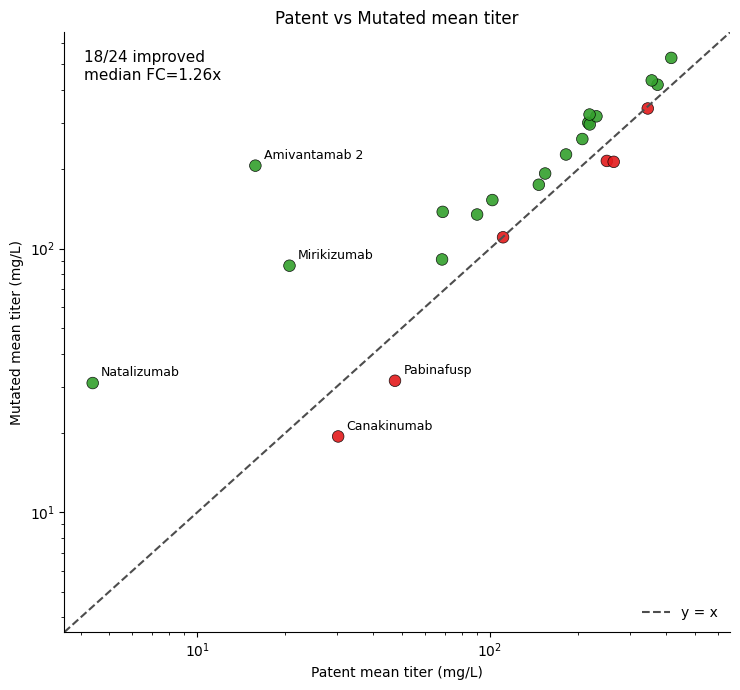

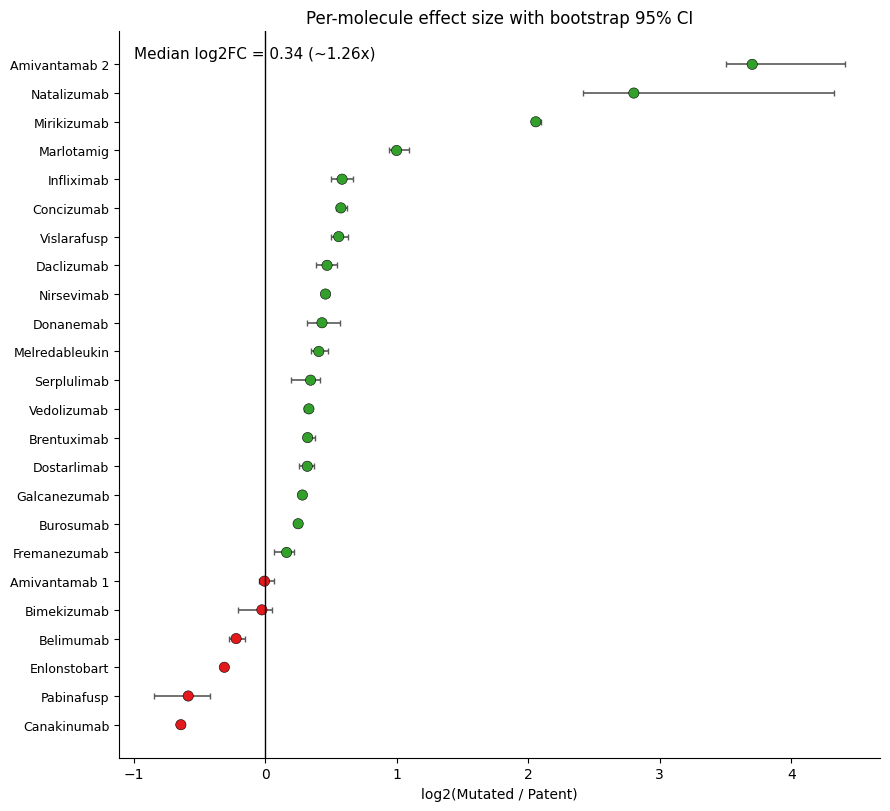

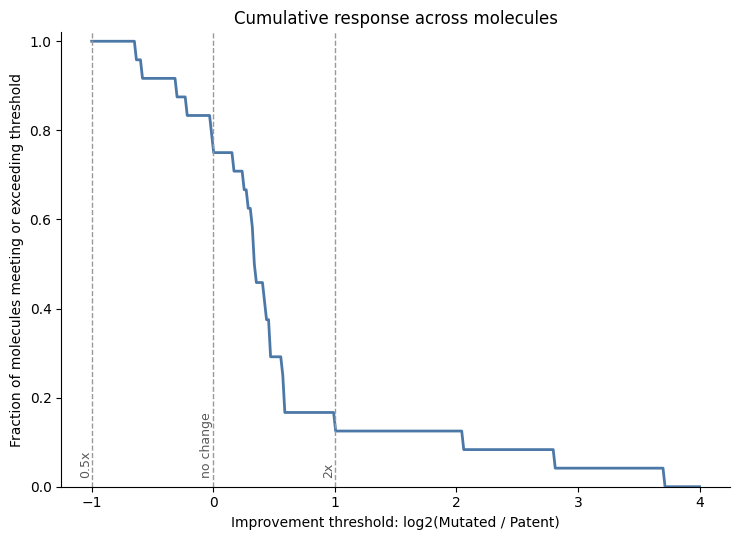

Saved:
 - Figure_IdentityScatter_loglog.pdf
 - Figure_Forest_log2FC_CI.pdf
 - Figure_CumulativeImprovement.pdf


In [4]:
# ============================================================
# NEW FIGURES: identity-line scatter, forest plot, ECDF/survival
# Assumes previous cell already created:
#   - summary
#   - summary_sorted
#   - COLOR_POS, COLOR_NEG
#
# For the new Excel format:
#   - Base_Molecule is the grouped molecule name
#   - Parental_Mean internally means Patent_Mean
#   - Mutated_Mean means Mutated_Mean
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output files
OUT_IDENTITY = "Figure_IdentityScatter_loglog.pdf"
OUT_FOREST = "Figure_Forest_log2FC_CI.pdf"
OUT_ECDF = "Figure_CumulativeImprovement.pdf"

# Optional styling
COLOR_NEUTRAL = "#4c78a8"
ANNOTATE_TOP = 3
ANNOTATE_BOTTOM = 2

# Labels for the new file format
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

# ID column in summary/summary_sorted from the updated upstream script
ID_SUMMARY_COL = "Base_Molecule"

if ID_SUMMARY_COL not in summary.columns:
    raise ValueError(
        f"Expected '{ID_SUMMARY_COL}' in summary, but found: {list(summary.columns)}"
    )

if ID_SUMMARY_COL not in summary_sorted.columns:
    raise ValueError(
        f"Expected '{ID_SUMMARY_COL}' in summary_sorted, but found: {list(summary_sorted.columns)}"
    )

# ------------------------------------------------------------
# Helper: finite rows only
# ------------------------------------------------------------
plot_df = summary.copy()
plot_df = plot_df[
    np.isfinite(plot_df["Parental_Mean"]) &
    np.isfinite(plot_df["Mutated_Mean"]) &
    np.isfinite(plot_df["log2FC"])
].copy()

# ==============================
# FIGURE 4: Identity-line scatter
# ==============================
fig4, ax4 = plt.subplots(figsize=(7.5, 7))

x = plot_df["Parental_Mean"].values
y = plot_df["Mutated_Mean"].values
fc = plot_df["log2FC"].values

# Color by direction of change
pt_colors = np.where(fc >= 0, COLOR_POS, COLOR_NEG)

ax4.scatter(
    x, y,
    s=70,
    c=pt_colors,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.9
)

# Identity line
all_vals = np.concatenate([x, y])
all_vals = all_vals[np.isfinite(all_vals) & (all_vals > 0)]

if len(all_vals) == 0:
    raise ValueError("No positive values available for log-scale identity scatter.")

vmin = all_vals.min() * 0.8
vmax = all_vals.max() * 1.25

ax4.plot(
    [vmin, vmax],
    [vmin, vmax],
    color="0.3",
    lw=1.5,
    linestyle="--",
    label="y = x"
)

# Log axes
ax4.set_xscale("log")
ax4.set_yscale("log")
ax4.set_xlim(vmin, vmax)
ax4.set_ylim(vmin, vmax)

ax4.set_xlabel(f"{PARENT_LABEL} mean titer (mg/L)")
ax4.set_ylabel(f"{MUT_LABEL} mean titer (mg/L)")
ax4.set_title(f"{PARENT_LABEL} vs {MUT_LABEL} mean titer")

# Annotate strongest improvers / decliners
to_label = pd.concat([
    plot_df.sort_values("log2FC", ascending=False).head(ANNOTATE_TOP),
    plot_df.sort_values("log2FC", ascending=True).head(ANNOTATE_BOTTOM)
]).drop_duplicates(subset=[ID_SUMMARY_COL])

for _, r in to_label.iterrows():
    xi, yi = r["Parental_Mean"], r["Mutated_Mean"]

    if np.isfinite(xi) and np.isfinite(yi) and xi > 0 and yi > 0:
        ax4.annotate(
            str(r[ID_SUMMARY_COL]),
            (xi, yi),
            textcoords="offset points",
            xytext=(6, 5),
            fontsize=9
        )

n_improved = int(np.sum(plot_df["log2FC"] > 0))
n_total = int(np.sum(np.isfinite(plot_df["log2FC"])))

# Optional median FC if you want it later
median_fc = np.nanmedian(
    (plot_df["Mutated_Mean"] / plot_df["Parental_Mean"])
    .replace([np.inf, -np.inf], np.nan)
)

ax4.text(
    0.03,
    0.97,
    f"{n_improved}/{n_total} improved\nmedian FC={median_fc:.2f}x",
    transform=ax4.transAxes,
    ha="left",
    va="top",
    fontsize=11
)

ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.legend(frameon=False, loc="lower right")

plt.tight_layout()
fig4.savefig(OUT_IDENTITY)
plt.show()


# ==========================================
# FIGURE 5: Forest plot of log2FC with 95% CI
# ==========================================
forest_df = summary_sorted.copy()
forest_df = forest_df[np.isfinite(forest_df["log2FC"])].copy()

fig5, ax5 = plt.subplots(figsize=(9, max(6, 0.28 * len(forest_df) + 1.5)))

vals = forest_df["log2FC"].values
names = forest_df[ID_SUMMARY_COL].astype(str).tolist()
ypos = np.arange(len(forest_df))

# Plot CI if available
has_ci = (
    "log2FC_ci_low" in forest_df.columns and
    "log2FC_ci_high" in forest_df.columns and
    np.isfinite(forest_df["log2FC_ci_low"]).any() and
    np.isfinite(forest_df["log2FC_ci_high"]).any()
)

if has_ci:
    lo = forest_df["log2FC_ci_low"].values
    hi = forest_df["log2FC_ci_high"].values

    xerr_left = vals - lo
    xerr_right = hi - vals

    valid_err = (
        np.isfinite(vals) &
        np.isfinite(xerr_left) &
        np.isfinite(xerr_right) &
        (xerr_left >= 0) &
        (xerr_right >= 0)
    )

    if valid_err.any():
        ax5.errorbar(
            vals[valid_err],
            ypos[valid_err],
            xerr=[xerr_left[valid_err], xerr_right[valid_err]],
            fmt="none",
            ecolor="0.35",
            elinewidth=1.2,
            capsize=2,
            zorder=1
        )

# Point estimates
pt_colors = np.where(vals >= 0, COLOR_POS, COLOR_NEG)

ax5.scatter(
    vals,
    ypos,
    s=55,
    c=pt_colors,
    edgecolor="black",
    linewidth=0.4,
    zorder=2
)

ax5.axvline(0, color="black", lw=1)
ax5.set_yticks(ypos)
ax5.set_yticklabels(names, fontsize=9)
ax5.invert_yaxis()

ax5.set_xlabel(f"log2({MUT_LABEL} / {PARENT_LABEL})")
ax5.set_title("Per-molecule effect size with bootstrap 95% CI")

# Helpful annotation
med = np.nanmedian(vals)

ax5.text(
    0.02,
    0.98,
    f"Median log2FC = {med:.2f} (~{2**med:.2f}x)",
    transform=ax5.transAxes,
    ha="left",
    va="top",
    fontsize=11
)

ax5.spines["top"].set_visible(False)
ax5.spines["right"].set_visible(False)

plt.tight_layout()
fig5.savefig(OUT_FOREST)
plt.show()


# =======================================================
# FIGURE 6: Cumulative improvement curve, survival-style
# Fraction of molecules with effect >= threshold
# =======================================================
ecdf_vals = plot_df["log2FC"].dropna().values
ecdf_vals = np.sort(ecdf_vals)

if len(ecdf_vals) == 0:
    raise ValueError("No finite log2FC values available for cumulative improvement plot.")

fig6, ax6 = plt.subplots(figsize=(7.5, 5.5))

# Use a threshold grid spanning observed effects
xmin = np.floor(ecdf_vals.min() * 2) / 2
xmax = np.ceil(ecdf_vals.max() * 2) / 2
thresholds = np.linspace(xmin, xmax, 300)

# Fraction >= threshold
frac_ge = np.array([(ecdf_vals >= t).mean() for t in thresholds])

ax6.plot(thresholds, frac_ge, color=COLOR_NEUTRAL, lw=2)

# Reference lines at useful effect thresholds
for t, label in [(0, "no change"), (1, "2x"), (-1, "0.5x")]:
    ax6.axvline(t, color="0.6", lw=1, linestyle="--")
    ax6.text(
        t,
        0.02,
        label,
        rotation=90,
        va="bottom",
        ha="right",
        fontsize=9,
        color="0.35"
    )

ax6.set_xlabel(f"Improvement threshold: log2({MUT_LABEL} / {PARENT_LABEL})")
ax6.set_ylabel("Fraction of molecules meeting or exceeding threshold")
ax6.set_title("Cumulative response across molecules")
ax6.set_ylim(0, 1.02)

ax6.spines["top"].set_visible(False)
ax6.spines["right"].set_visible(False)

plt.tight_layout()
fig6.savefig(OUT_ECDF)
plt.show()

print("Saved:")
print(" -", OUT_IDENTITY)
print(" -", OUT_FOREST)
print(" -", OUT_ECDF)

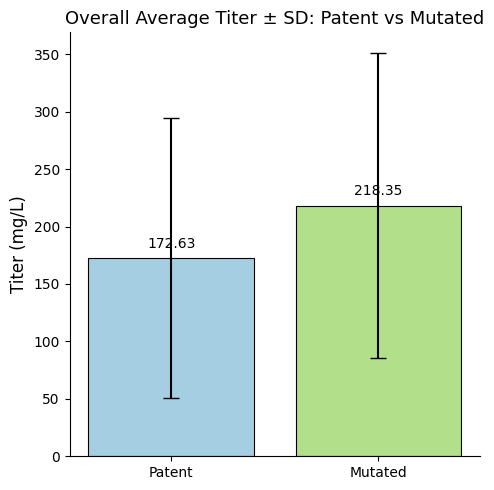

In [5]:
# -----------------------------
# Simple 2-bar plot: overall Patent vs Mutated (mean ± SD)
# Using the per-molecule means in `summary`
#
# Note:
# In the updated upstream script:
#   Parental_Mean = Patent mean
#   Mutated_Mean  = Mutated mean
# -----------------------------

import numpy as np
import matplotlib.pyplot as plt

# Overall mean across molecules; each molecule contributes equally
patent_mean = np.nanmean(summary["Parental_Mean"])
mut_mean    = np.nanmean(summary["Mutated_Mean"])

# SD across molecules; variation between constructs/molecules
patent_sd = np.nanstd(summary["Parental_Mean"], ddof=1)
mut_sd    = np.nanstd(summary["Mutated_Mean"], ddof=1)

labels = ["Patent", "Mutated"]
means  = [patent_mean, mut_mean]
sds    = [patent_sd, mut_sd]

colors = ["#A6CEE3", "#B2DF8A"]  # same palette as your main plot

fig, ax = plt.subplots(figsize=(5, 5))

ax.bar(
    labels,
    means,
    yerr=sds,
    capsize=6,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_ylabel("Titer (mg/L)", fontsize=12)
ax.set_title("Overall Average Titer ± SD: Patent vs Mutated", fontsize=13)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Optional: show mean values on top of bars
for i, (m, sd) in enumerate(zip(means, sds)):
    if np.isfinite(m):
        y_text = m + (sd * 0.05 if np.isfinite(sd) else 0)
        ax.text(
            i,
            y_text,
            f"{m:.2f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import re
from scipy.stats import ttest_rel

# If df is not already loaded, uncomment:
# df = pd.read_excel("codons-data-new.xlsx", engine="openpyxl")

id_col = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

if id_col not in df.columns:
    raise ValueError(f"Expected '{id_col}' column not found. Available columns: {list(df.columns)}")

df = df.dropna(subset=[id_col]).copy()
df[id_col] = df[id_col].astype(str).str.strip()

# ------------------------------------------------
# Parse Molecule into Base_Molecule and Variant
# Example:
# "Amivantamab 1 Patent"  -> Base_Molecule="Amivantamab 1", Variant="Patent"
# "Amivantamab 1 Mutated" -> Base_Molecule="Amivantamab 1", Variant="Mutated"
# ------------------------------------------------
parsed = df[id_col].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()

df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

if df.empty:
    raise ValueError(
        "No rows matched the expected Molecule naming pattern ending in 'Mutated' or 'Patent'."
    )

# ------------------------------------------------
# Find titer replicate columns robustly
# New format: "Titer mg/L Rep 1", "Titer mg/L Rep 2", etc.
# ------------------------------------------------
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

titer_cols = sorted(titer_cols, key=rep_num)

if len(titer_cols) < 2:
    raise ValueError(
        f"Not enough replicate titer columns to run paired t-test. "
        f"Found titer_cols={titer_cols}"
    )

# ------------------------------------------------
# Clean numeric
# Original script used Too Low -> 0
# If you prefer censoring missing/low values, change 0 to np.nan
# ------------------------------------------------
def clean_numeric(s):
    return pd.to_numeric(
        s.replace({
            "Too Low": 0,
            "too low": 0,
            "TOO LOW": 0,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

for c in titer_cols:
    df[c] = clean_numeric(df[c])

# ------------------------------------------------
# Paired t-test per Base_Molecule
# Patent Rep 1 is paired with Mutated Rep 1, etc.
# ------------------------------------------------
results = []

for mol, sub in df.groupby("Base_Molecule", dropna=False):

    patent_rows = sub[sub["Variant"] == PARENT_LABEL]
    mutated_rows = sub[sub["Variant"] == MUT_LABEL]

    # Need both Patent and Mutated rows
    if patent_rows.empty or mutated_rows.empty:
        continue

    pairs_parent = []
    pairs_mut = []

    # Usually there is one Patent row and one Mutated row per Base_Molecule.
    # If duplicates exist, this uses all row combinations.
    for _, prow in patent_rows.iterrows():
        for _, mrow in mutated_rows.iterrows():
            for c in titer_cols:
                pv = prow[c]
                mv = mrow[c]

                if np.isfinite(pv) and np.isfinite(mv):
                    pairs_parent.append(pv)
                    pairs_mut.append(mv)

    parental = np.array(pairs_parent, dtype=float)
    mutated = np.array(pairs_mut, dtype=float)

    n_pairs = len(parental)

    # Need at least 2 paired observations for paired t-test
    if n_pairs < 2:
        continue

    tstat, pval = ttest_rel(mutated, parental, nan_policy="omit")

    parental_mean = float(np.mean(parental))
    mutated_mean = float(np.mean(mutated))

    results.append({
        "Base_Molecule": mol,
        "N_pairs": n_pairs,
        "Patent_Mean": parental_mean,
        "Mutated_Mean": mutated_mean,
        "Mutated_Higher": mutated_mean > parental_mean,
        "Mean_Difference": mutated_mean - parental_mean,
        "Fold_Change": mutated_mean / parental_mean if parental_mean != 0 else np.nan,
        "log2FC": np.log2(mutated_mean / parental_mean) if parental_mean > 0 and mutated_mean > 0 else np.nan,
        "t_stat": float(tstat),
        "p_value": float(pval)
    })

results_df = (
    pd.DataFrame(results)
      .sort_values("p_value")
      .reset_index(drop=True)
)

results_df

,Base_Molecule,N_pairs,Patent_Mean,Mutated_Mean,Mutated_Higher,Mean_Difference,Fold_Change,log2FC,t_stat,p_value
0,Enlonstobart,3,264.665024,213.312488,False,-51.352536,0.805972,-0.311199,-32.632216,0.000938
1,Marlotamig,3,68.946487,137.806694,True,68.860207,1.998749,0.999097,20.711896,0.002323
2,Melredableukin,3,68.603452,90.968051,True,22.364599,1.325998,0.407079,19.316764,0.002669
3,Daclizumab,3,216.671302,300.104532,True,83.433230,1.385068,0.469957,17.710208,0.003173
4,Dostarlimab,3,154.340682,192.619881,True,38.279199,1.248018,0.319638,14.686139,0.004604
5,Brentuximab,3,181.888915,227.417355,True,45.528440,1.250309,0.322285,14.120961,0.004978
6,Galcanezumab,3,356.964083,434.114719,True,77.150636,1.216130,0.282297,14.049519,0.005028
7,Mirikizumab,3,20.660510,86.134258,True,65.473748,4.169029,2.059711,10.928463,0.008269
8,Amivantamab 2,3,15.799506,206.309949,True,190.510443,13.058000,3.706862,10.682264,0.008650
9,Concizumab,3,90.379066,134.668572,True,44.289507,1.490042,0.575353,8.157217,0.014698


In [7]:
summary_table = pd.DataFrame({
    "Metric": [
        "Total molecules tested",
        "Mutated mean > Patent mean",
        "Mutated higher AND p < 0.05"
    ],
    "Count": [
        len(results_df),
        int(results_df["Mutated_Higher"].sum()),
        int(((results_df["Mutated_Higher"]) & (results_df["p_value"] < 0.05)).sum())
    ]
})

summary_table

,Metric,Count
0,Total molecules tested,24
1,Mutated mean > Patent mean,18
2,Mutated higher AND p < 0.05,16


In [8]:
from scipy.stats import ttest_rel, wilcoxon
import numpy as np
import pandas as pd
import re

# ------------------------------------
# Assumes df is already loaded:
# df = pd.read_excel("codons-data-new.xlsx", engine="openpyxl")
# ------------------------------------

id_col = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

if id_col not in df.columns:
    raise ValueError(f"Expected '{id_col}' column not found in df. Available columns: {list(df.columns)}")

df = df.dropna(subset=[id_col]).copy()
df[id_col] = df[id_col].astype(str).str.strip()

# ------------------------------------
# Parse Molecule into Base_Molecule and Variant
# Example:
# "Amivantamab 1 Patent"  -> Base_Molecule="Amivantamab 1", Variant="Patent"
# "Amivantamab 1 Mutated" -> Base_Molecule="Amivantamab 1", Variant="Mutated"
# ------------------------------------
parsed = df[id_col].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()

df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

if df.empty:
    raise ValueError(
        "No rows matched the expected Molecule naming pattern ending in 'Mutated' or 'Patent'."
    )

# ------------------------------------
# Find titer replicate columns
# New format: "Titer mg/L Rep 1", "Titer mg/L Rep 2", etc.
# ------------------------------------
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else None

titer_cols = sorted(titer_cols, key=lambda c: rep_num(c) if rep_num(c) is not None else 999)

if len(titer_cols) == 0:
    raise ValueError(
        f"No titer replicate columns found. Expected headers like 'Titer mg/L Rep 1'. "
        f"Available columns: {list(df.columns)}"
    )

# ------------------------------------
# Clean replicate columns
# Original script used Too Low -> 0.
# Change 0 to np.nan if you want to censor low values instead.
# ------------------------------------
def clean_numeric(s):
    return pd.to_numeric(
        s.replace({
            "Too Low": 0,
            "too low": 0,
            "TOO LOW": 0,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

for c in titer_cols:
    df[c] = clean_numeric(df[c])

# ------------------------------------
# Convert to long format:
# one row per Base_Molecule / Variant / Replicate
# ------------------------------------
long_df = df.melt(
    id_vars=["Base_Molecule", "Variant"],
    value_vars=titer_cols,
    var_name="Replicate_Column",
    value_name="Titer"
)

long_df["Replicate"] = long_df["Replicate_Column"].apply(rep_num)
long_df = long_df.dropna(subset=["Titer", "Replicate"]).copy()
long_df["Replicate"] = long_df["Replicate"].astype(int)

# ------------------------------------
# If duplicate rows exist for same Base_Molecule / Variant / Replicate,
# average them so each pair is represented once.
# ------------------------------------
long_summary = (
    long_df.groupby(["Base_Molecule", "Variant", "Replicate"], dropna=False)
           .agg(Titer=("Titer", "mean"))
           .reset_index()
)

# ------------------------------------
# Pivot Patent and Mutated side-by-side
# ------------------------------------
paired_df = (
    long_summary.pivot_table(
        index=["Base_Molecule", "Replicate"],
        columns="Variant",
        values="Titer",
        aggfunc="mean"
    )
    .reset_index()
)

# Require both Patent and Mutated columns
for label in [PARENT_LABEL, MUT_LABEL]:
    if label not in paired_df.columns:
        raise ValueError(
            f"Expected variant '{label}' not found after parsing/pivoting. "
            f"Variants found: {list(long_summary['Variant'].dropna().unique())}"
        )

# Keep only valid pairs
paired_df = paired_df[
    pd.notna(paired_df[PARENT_LABEL]) &
    pd.notna(paired_df[MUT_LABEL])
].copy()

paired_df["Delta"] = paired_df[MUT_LABEL] - paired_df[PARENT_LABEL]

# Rename columns for clarity
paired_df = paired_df.rename(columns={
    PARENT_LABEL: "Patent",
    MUT_LABEL: "Mutated"
})

# ------------------------------------
# Summary statistics
# ------------------------------------
n_pairs = len(paired_df)

if n_pairs == 0:
    raise ValueError("No valid paired replicate observations found after cleaning/filtering.")

mean_patent = paired_df["Patent"].mean()
mean_mutated = paired_df["Mutated"].mean()
mean_delta = paired_df["Delta"].mean()

# ------------------------------------
# Statistical tests: global across all paired replicates
# ------------------------------------
# Paired t-test
t_stat, t_pval = ttest_rel(paired_df["Mutated"], paired_df["Patent"])

# Wilcoxon signed-rank test
# Wilcoxon can fail if all deltas are zero or too few non-zero differences.
nonzero_mask = paired_df["Delta"] != 0

if nonzero_mask.sum() < 1:
    w_stat, w_pval = np.nan, np.nan
else:
    w_stat, w_pval = wilcoxon(
        paired_df.loc[nonzero_mask, "Mutated"],
        paired_df.loc[nonzero_mask, "Patent"],
        zero_method="wilcox"
    )

# ------------------------------------
# Results table
# ------------------------------------
results_summary = pd.DataFrame({
    "Metric": [
        "Number of paired replicates",
        "Mean Patent titer (mg/L)",
        "Mean Mutated titer (mg/L)",
        "Mean Δ (Mutated − Patent)",
        "Paired t-test p-value",
        "Wilcoxon signed-rank p-value",
        "Mutated better on average?"
    ],
    "Value": [
        int(n_pairs),
        float(mean_patent),
        float(mean_mutated),
        float(mean_delta),
        float(t_pval),
        float(w_pval) if pd.notna(w_pval) else np.nan,
        "Yes" if mean_delta > 0 else "No"
    ]
})

paired_df, results_summary

(Variant  Base_Molecule  Replicate     Mutated      Patent       Delta
 0        Amivantamab 1          1  119.629062  114.207233    5.421829
 1        Amivantamab 1          2  127.493708  131.665848   -4.172140
 2        Amivantamab 1          3   84.088073   86.649860   -2.561787
 3        Amivantamab 2          1  219.651804   19.336145  200.315659
 4        Amivantamab 2          2  235.728373   20.420748  215.307625
 ..                 ...        ...         ...         ...         ...
 67         Vedolizumab          2  194.354372  158.729408   35.624964
 68         Vedolizumab          3  288.554126  227.808550   60.745576
 69         Vislarafusp          1  373.395486  257.718968  115.676518
 70         Vislarafusp          2  243.474050  172.102396   71.371654
 71         Vislarafusp          3  350.160991  226.789648  123.371343
 
 [72 rows x 5 columns],
                          Metric       Value
 0   Number of paired replicates          72
 1      Mean Patent titer (mg/L)

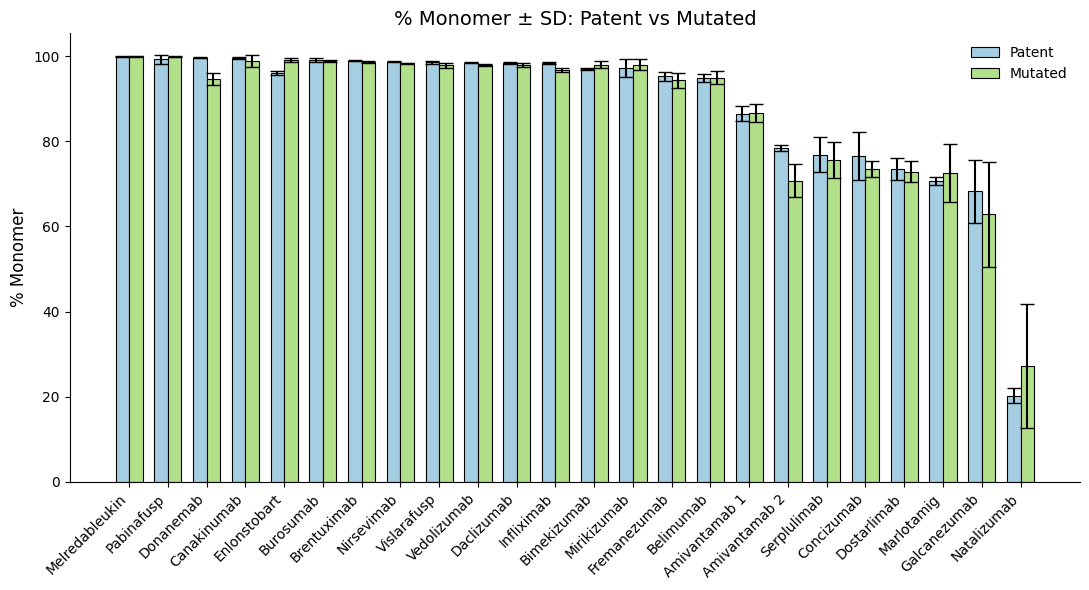

Monomer columns used:
['% Monomer Rep 1', '% Monomer Rep 2', '% Monomer Rep 3']

Summary preview:
     Base_Molecule  Patent_Mean  Patent_SD  Mutated_Mean  Mutated_SD
16  Melredableukin    99.820000   0.117898     99.903333    0.040415
20      Pabinafusp    99.283333   1.042417     99.806667    0.120968
9        Donanemab    99.653333   0.204042     94.680000    1.460103
6      Canakinumab    99.476667   0.206478     98.840000    1.378078
11    Enlonstobart    96.010000   0.380395     99.133333    0.470035


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# -----------------------------
# Load data
# -----------------------------
df = pd.read_excel("master-data.xlsx", engine="openpyxl")

# -----------------------------
# Require Molecule column
# -----------------------------
id_col = "Molecule"

if id_col not in df.columns:
    raise ValueError(
        f"Expected a '{id_col}' column, but it was not found. "
        f"Columns available: {list(df.columns)}"
    )

df = df.dropna(subset=[id_col]).copy()
df[id_col] = df[id_col].astype(str).str.strip()

# -----------------------------
# Parse Molecule into Base_Molecule and Variant
# Example:
# "Amivantamab 1 Patent"  -> Base_Molecule="Amivantamab 1", Variant="Patent"
# "Amivantamab 1 Mutated" -> Base_Molecule="Amivantamab 1", Variant="Mutated"
# -----------------------------
parsed = df[id_col].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()

df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

if df.empty:
    raise ValueError(
        "No rows matched the expected Molecule naming pattern ending in 'Mutated' or 'Patent'."
    )

# -----------------------------
# Find Monomer replicate columns
# New format:
# "% Monomer Rep 1", "% Monomer Rep 2", "% Monomer Rep 3", etc.
# -----------------------------
monomer_cols = [
    c for c in df.columns
    if re.match(r"^%\s*Monomer\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

if len(monomer_cols) == 0:
    raise ValueError(
        f"Could not find % Monomer replicate columns.\n"
        f"Found monomer_cols={monomer_cols}\n"
        f"Expected headers like '% Monomer Rep 1'."
    )

# Sort by replicate number
def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

monomer_cols = sorted(monomer_cols, key=rep_num)

# -----------------------------
# Clean numeric columns
# Handles: "95%" -> 95, blanks -> NaN
# -----------------------------
def clean_numeric(series):
    s = series.replace({
        "Too Low": 0,
        "too low": 0,
        "TOO LOW": 0,
        "": np.nan,
        " ": np.nan,
        "NA": np.nan,
        "na": np.nan
    })

    # Strip percent signs if present
    s = s.astype(str).str.replace("%", "", regex=False)

    return pd.to_numeric(s, errors="coerce")

for c in monomer_cols:
    df[c] = clean_numeric(df[c])

# -----------------------------
# Compute row-level mean and SD for % Monomer
# -----------------------------
df["Monomer_Mean"] = df[monomer_cols].mean(axis=1, skipna=True)
df["Monomer_SD"] = df[monomer_cols].std(axis=1, skipna=True)

# -----------------------------
# Aggregate to one row per Base_Molecule + Variant
# This handles duplicate rows safely if they exist.
# -----------------------------
summary_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(
          Monomer_Mean=("Monomer_Mean", "mean"),
          Monomer_SD=("Monomer_SD", "mean"),
          N_rows=("Monomer_Mean", "size")
      )
      .reset_index()
)

# -----------------------------
# Pivot Patent and Mutated side-by-side
# -----------------------------
mean_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Monomer_Mean"
)

sd_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Monomer_SD"
)

# Make sure expected columns exist
for variant in ["Patent", "Mutated"]:
    if variant not in mean_wide.columns:
        mean_wide[variant] = np.nan
    if variant not in sd_wide.columns:
        sd_wide[variant] = np.nan

summary = pd.DataFrame({
    "Base_Molecule": mean_wide.index,
    "Patent_Mean": mean_wide["Patent"].values,
    "Patent_SD": sd_wide["Patent"].values,
    "Mutated_Mean": mean_wide["Mutated"].values,
    "Mutated_SD": sd_wide["Mutated"].values
}).reset_index(drop=True)

# -----------------------------
# Order molecules by MAX mean % Monomer across Patent/Mutated
# -----------------------------
summary["MaxMean"] = summary[["Patent_Mean", "Mutated_Mean"]].max(axis=1)
summary = summary.sort_values("MaxMean", ascending=False).drop(columns=["MaxMean"])

names = summary["Base_Molecule"].astype(str).tolist()
x = np.arange(len(names))
width = 0.35

# -----------------------------
# Plot
# -----------------------------
colors = {
    "Patent": "#A6CEE3",
    "Mutated": "#B2DF8A"
}

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    x - width / 2,
    summary["Patent_Mean"],
    width,
    yerr=summary["Patent_SD"],
    capsize=5,
    label="Patent",
    color=colors["Patent"],
    edgecolor="black",
    linewidth=0.8
)

ax.bar(
    x + width / 2,
    summary["Mutated_Mean"],
    width,
    yerr=summary["Mutated_SD"],
    capsize=5,
    label="Mutated",
    color=colors["Mutated"],
    edgecolor="black",
    linewidth=0.8
)

ax.set_ylabel("% Monomer", fontsize=12)
ax.set_title("% Monomer ± SD: Patent vs Mutated", fontsize=14)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right")

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("Monomer columns used:")
print(monomer_cols)

print("\nSummary preview:")
print(summary.head())


Overall averages across molecules for Monomer:
 Metric  N_molecules  Avg_Patent_Mean  Avg_Mutated_Mean  Avg_Delta  Avg_%Change
Monomer           24        88.325069         87.737639  -0.587431     0.324823


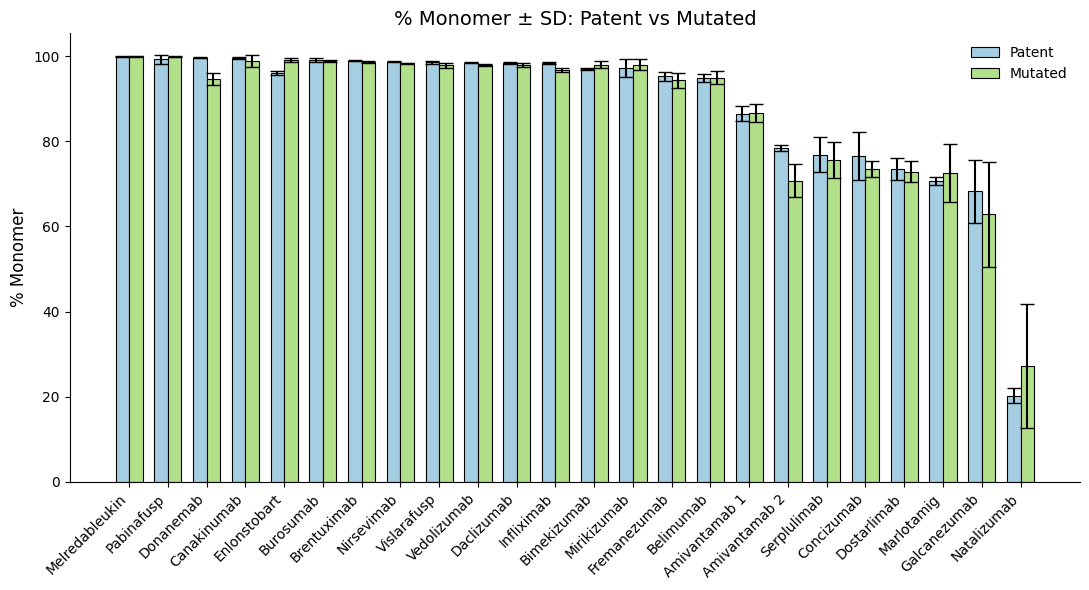


Overall averages across molecules for RT:
Metric  N_molecules  Avg_Patent_Mean  Avg_Mutated_Mean  Avg_Delta  Avg_%Change
    RT           24         2.472319          2.477347   0.005028     0.199722


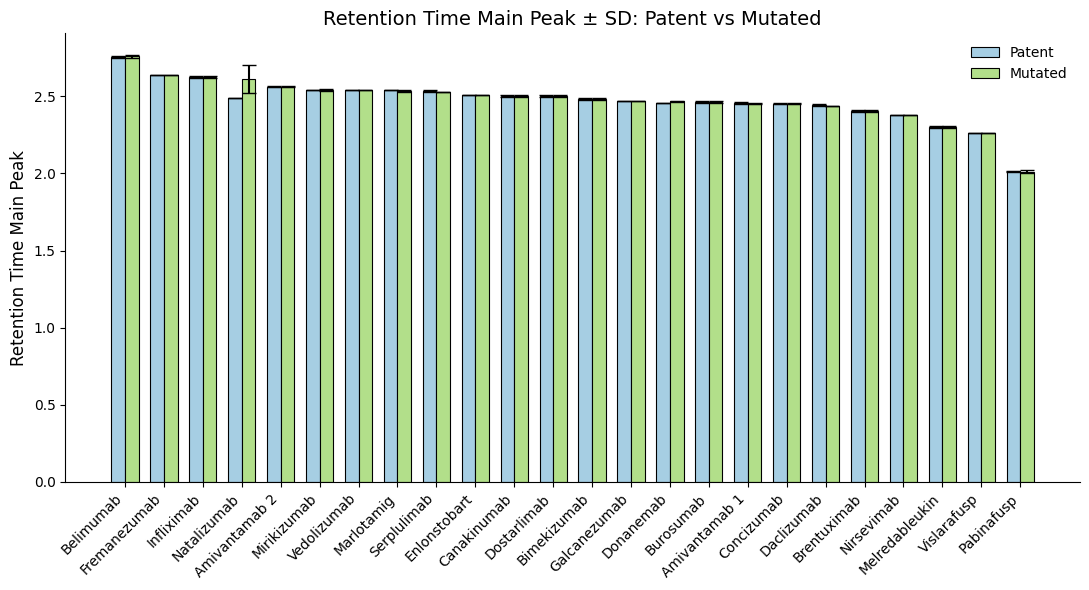


Overall averages across molecules for HMW:
Metric  N_molecules  Avg_Patent_Mean  Avg_Mutated_Mean  Avg_Delta  Avg_%Change
   HMW           24        11.646736          11.84625   0.199514     14.91222


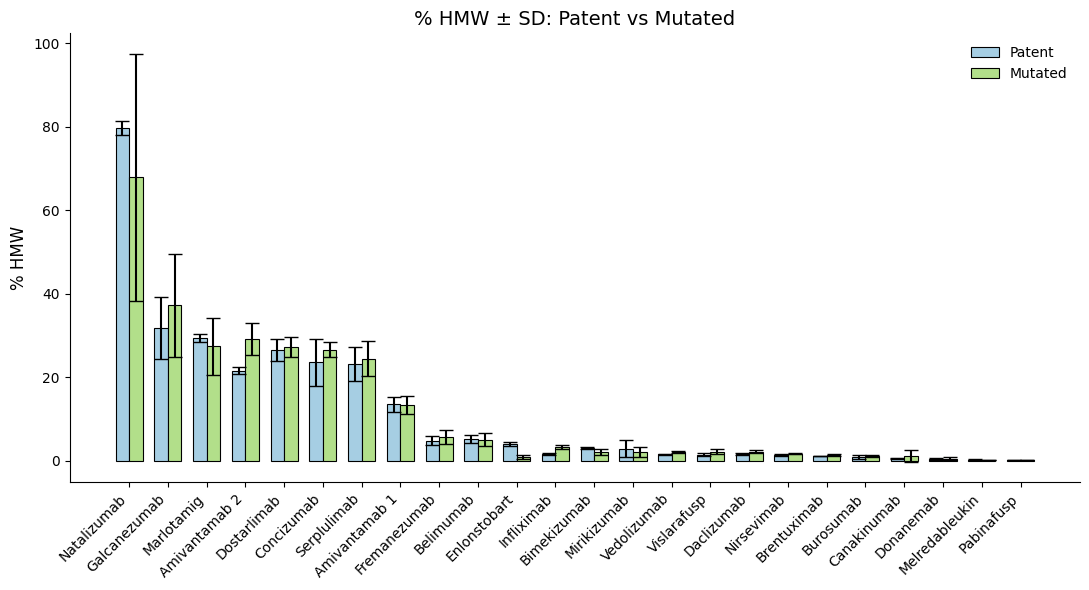


Overall averages across molecules for LMW:
Metric  N_molecules  Avg_Patent_Mean  Avg_Mutated_Mean  Avg_Delta  Avg_%Change
   LMW           24         0.028056          0.554306    0.52625   -26.646928


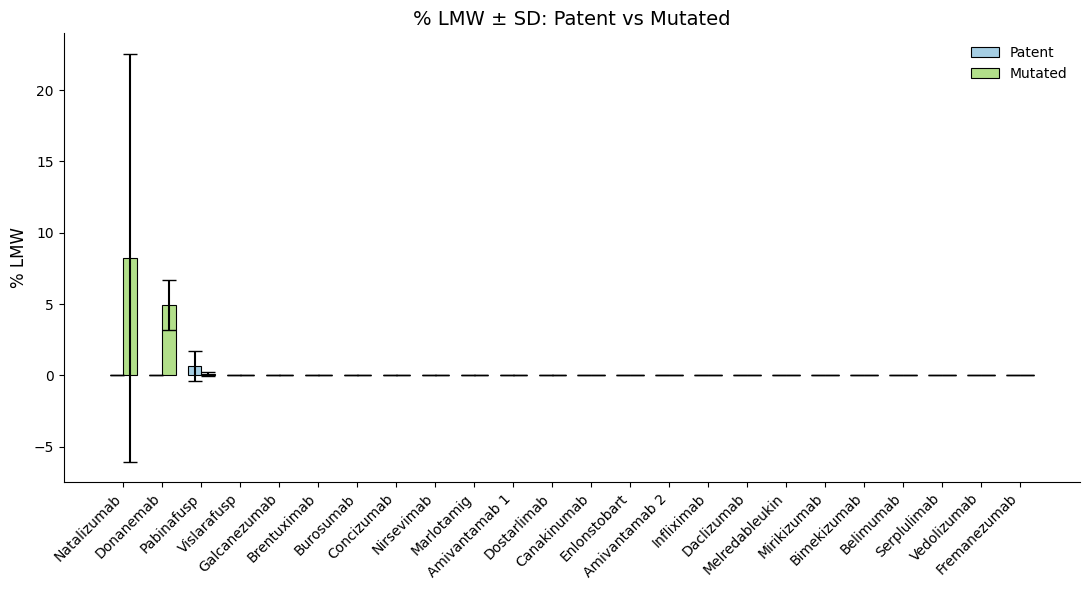


=== Combined overall averages, all metrics ===
 Metric  N_molecules  Avg_Patent_Mean  Avg_Mutated_Mean  Avg_Delta  Avg_%Change
Monomer           24        88.325069         87.737639  -0.587431     0.324823
     RT           24         2.472319          2.477347   0.005028     0.199722
    HMW           24        11.646736         11.846250   0.199514    14.912220
    LMW           24         0.028056          0.554306   0.526250   -26.646928


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# -----------------------------
# Load data
# -----------------------------
df = pd.read_excel("master-data.xlsx", engine="openpyxl")

ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

if ID_COL not in df.columns:
    raise ValueError(f"Expected '{ID_COL}' column not found. Available columns: {list(df.columns)}")

df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

# -----------------------------
# Parse Molecule into Base_Molecule and Variant
# Example:
# "Amivantamab 1 Patent"  -> Base_Molecule="Amivantamab 1", Variant="Patent"
# "Amivantamab 1 Mutated" -> Base_Molecule="Amivantamab 1", Variant="Mutated"
# -----------------------------
parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()

df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

if df.empty:
    raise ValueError(
        "No rows matched the expected Molecule naming pattern ending in 'Mutated' or 'Patent'."
    )

# -----------------------------
# Helpers
# -----------------------------
def clean_numeric(series):
    """Convert values to numeric; handles Too Low and percent signs."""
    s = series.replace({
        "Too Low": 0,
        "too low": 0,
        "TOO LOW": 0,
        "": np.nan,
        " ": np.nan,
        "NA": np.nan,
        "na": np.nan
    })

    s = s.astype(str).str.replace("%", "", regex=False)

    return pd.to_numeric(s, errors="coerce")


def rep_num(colname):
    m = re.search(r"Rep\s*(\d+)", str(colname), re.IGNORECASE)
    return int(m.group(1)) if m else 999


# Maps simple metric names to the actual new-file column patterns
METRIC_CONFIG = {
    "Monomer": {
        "pattern": r"^%\s*Monomer\s*Rep\s*\d+$",
        "ylabel": "% Monomer",
        "title_metric": "% Monomer",
        "scale_0_to_1": False
    },
    "HMW": {
        "pattern": r"^%\s*HMW\s*Rep\s*\d+$",
        "ylabel": "% HMW",
        "title_metric": "% HMW",
        "scale_0_to_1": False
    },
    "LMW": {
        "pattern": r"^%\s*LMW\s*Rep\s*\d+$",
        "ylabel": "% LMW",
        "title_metric": "% LMW",
        "scale_0_to_1": False
    },
    "RT": {
        "pattern": r"^Retention\s*Time\s*Main\s*Peak\s*Rep\s*\d+$",
        "ylabel": "Retention Time Main Peak",
        "title_metric": "Retention Time Main Peak",
        "scale_0_to_1": False
    }
}


def plot_metric(metric="Monomer", ylabel=None, title=None, scale_0_to_1=None):
    """
    metric: one of 'Monomer', 'RT', 'HMW', 'LMW'
    ylabel/title: optional custom labels
    scale_0_to_1: set True if data are fractions 0-1 instead of percentages 0-100

    Returns:
        summary: per-molecule summary dataframe
        overall: overall summary dataframe
    """

    if metric not in METRIC_CONFIG:
        raise ValueError(
            f"Unknown metric='{metric}'. Available metrics: {list(METRIC_CONFIG.keys())}"
        )

    config = METRIC_CONFIG[metric]

    if ylabel is None:
        ylabel = config["ylabel"]

    if title is None:
        title = f"{config['title_metric']} ± SD: {PARENT_LABEL} vs {MUT_LABEL}"

    if scale_0_to_1 is None:
        scale_0_to_1 = config["scale_0_to_1"]

    # -----------------------------
    # Find replicate columns in new format
    # Examples:
    # "% Monomer Rep 1"
    # "% HMW Rep 1"
    # "% LMW Rep 1"
    # "Retention Time Main Peak Rep 1"
    # -----------------------------
    metric_cols = [
        c for c in df.columns
        if re.match(config["pattern"], str(c).strip(), re.IGNORECASE)
    ]

    metric_cols = sorted(metric_cols, key=rep_num)

    if len(metric_cols) == 0:
        raise ValueError(
            f"Missing columns for metric='{metric}'.\n"
            f"Expected pattern: {config['pattern']}\n"
            f"Available columns: {list(df.columns)}"
        )

    # -----------------------------
    # Work on temp copy and clean numbers
    # -----------------------------
    temp = df[["Base_Molecule", "Variant"] + metric_cols].copy()

    for c in metric_cols:
        temp[c] = clean_numeric(temp[c])

    # Optional convert fraction 0-1 to percent 0-100
    if scale_0_to_1:
        for c in metric_cols:
            temp[c] = temp[c] * 100.0

    # -----------------------------
    # Row-level stats
    # -----------------------------
    temp["Mean_row"] = temp[metric_cols].mean(axis=1, skipna=True)
    temp["SD_row"] = temp[metric_cols].std(axis=1, skipna=True)

    # -----------------------------
    # Aggregate to one row per Base_Molecule + Variant
    # Handles accidental duplicate rows safely
    # -----------------------------
    summary_long = (
        temp.groupby(["Base_Molecule", "Variant"], dropna=False)
            .agg(
                Mean=("Mean_row", "mean"),
                SD=("SD_row", "mean"),
                N_rows=("Mean_row", "size")
            )
            .reset_index()
    )

    # -----------------------------
    # Pivot Patent and Mutated side-by-side
    # -----------------------------
    mean_wide = summary_long.pivot(
        index="Base_Molecule",
        columns="Variant",
        values="Mean"
    )

    sd_wide = summary_long.pivot(
        index="Base_Molecule",
        columns="Variant",
        values="SD"
    )

    for variant in [PARENT_LABEL, MUT_LABEL]:
        if variant not in mean_wide.columns:
            mean_wide[variant] = np.nan
        if variant not in sd_wide.columns:
            sd_wide[variant] = np.nan

    summary = pd.DataFrame({
        "Base_Molecule": mean_wide.index,
        "Patent_Mean": mean_wide[PARENT_LABEL].values,
        "Patent_SD": sd_wide[PARENT_LABEL].values,
        "Mutated_Mean": mean_wide[MUT_LABEL].values,
        "Mutated_SD": sd_wide[MUT_LABEL].values
    }).reset_index(drop=True)

    # Drop molecules where both means are missing
    summary = summary.dropna(subset=["Patent_Mean", "Mutated_Mean"], how="all").copy()

    # -----------------------------
    # Order by max mean
    # -----------------------------
    summary["MaxMean"] = summary[["Patent_Mean", "Mutated_Mean"]].max(axis=1)
    summary = summary.sort_values("MaxMean", ascending=False).drop(columns=["MaxMean"])

    # -----------------------------
    # Overall averages across molecules
    # -----------------------------
    pct_change = (
        100.0 *
        ((summary["Mutated_Mean"] - summary["Patent_Mean"]) / summary["Patent_Mean"])
    ).replace([np.inf, -np.inf], np.nan)

    overall = pd.DataFrame([{
        "Metric": metric,
        "N_molecules": int(len(summary)),
        "Avg_Patent_Mean": float(summary["Patent_Mean"].mean()),
        "Avg_Mutated_Mean": float(summary["Mutated_Mean"].mean()),
        "Avg_Delta": float((summary["Mutated_Mean"] - summary["Patent_Mean"]).mean()),
        "Avg_%Change": float(pct_change.mean())
    }])

    print(f"\nOverall averages across molecules for {metric}:")
    print(overall.to_string(index=False))

    # -----------------------------
    # Plot
    # -----------------------------
    names = summary["Base_Molecule"].astype(str).tolist()
    x = np.arange(len(names))
    width = 0.35

    colors = {
        PARENT_LABEL: "#A6CEE3",
        MUT_LABEL: "#B2DF8A"
    }

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.bar(
        x - width / 2,
        summary["Patent_Mean"],
        width,
        yerr=summary["Patent_SD"],
        capsize=5,
        label=PARENT_LABEL,
        color=colors[PARENT_LABEL],
        edgecolor="black",
        linewidth=0.8
    )

    ax.bar(
        x + width / 2,
        summary["Mutated_Mean"],
        width,
        yerr=summary["Mutated_SD"],
        capsize=5,
        label=MUT_LABEL,
        color=colors[MUT_LABEL],
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right")

    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return summary, overall


# -----------------------------
# Run all metrics
# -----------------------------
metrics = ["Monomer", "RT", "HMW", "LMW"]

overall_list = []
per_name_summaries = {}

for m in metrics:
    per_molecule_df, overall_df = plot_metric(m)
    per_name_summaries[m] = per_molecule_df
    overall_list.append(overall_df)

overall_all = pd.concat(overall_list, ignore_index=True)

print("\n=== Combined overall averages, all metrics ===")
print(overall_all.to_string(index=False))

Experimental molecules: 24
Scored therapeutics: 26
Merged molecules: 24

Chain groups:
Chain_Group
Heavy    26
Light    26
Name: Therapeutic, dtype: int64

Available plot-value columns:
['Titer_PlotValue', '% Monomer_PlotValue', 'Cumulant Radius_PlotValue', 'Cumulant PDI_PlotValue']


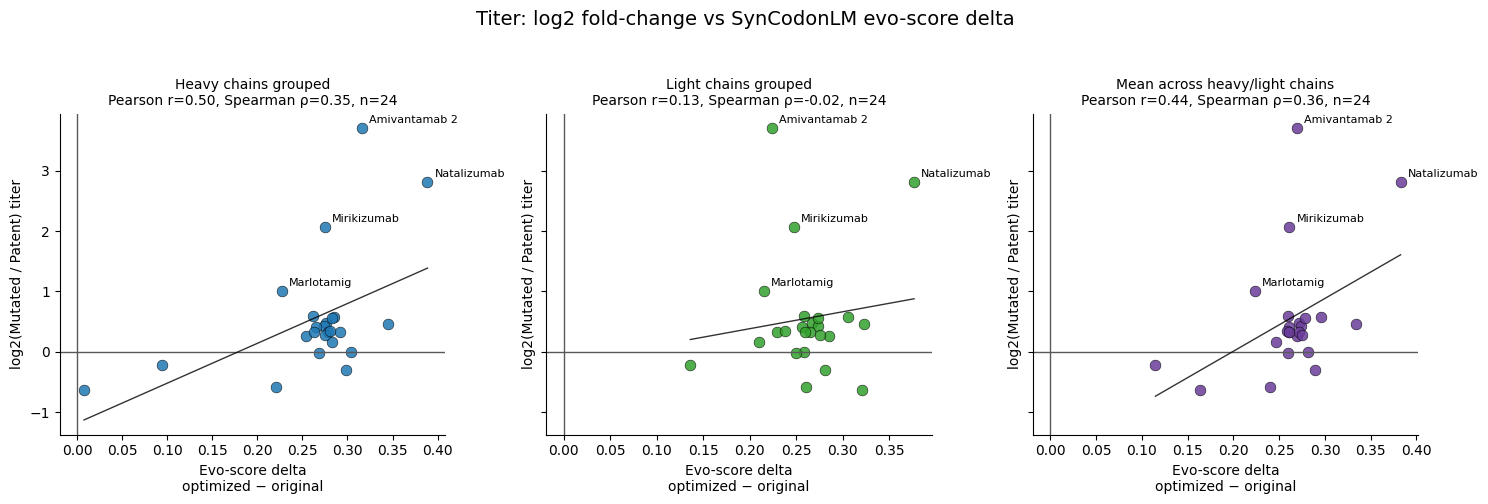

Saved:
 - Figure_Titer_log2FC_vs_EvoScoreDelta_HeavyLightMean.pdf


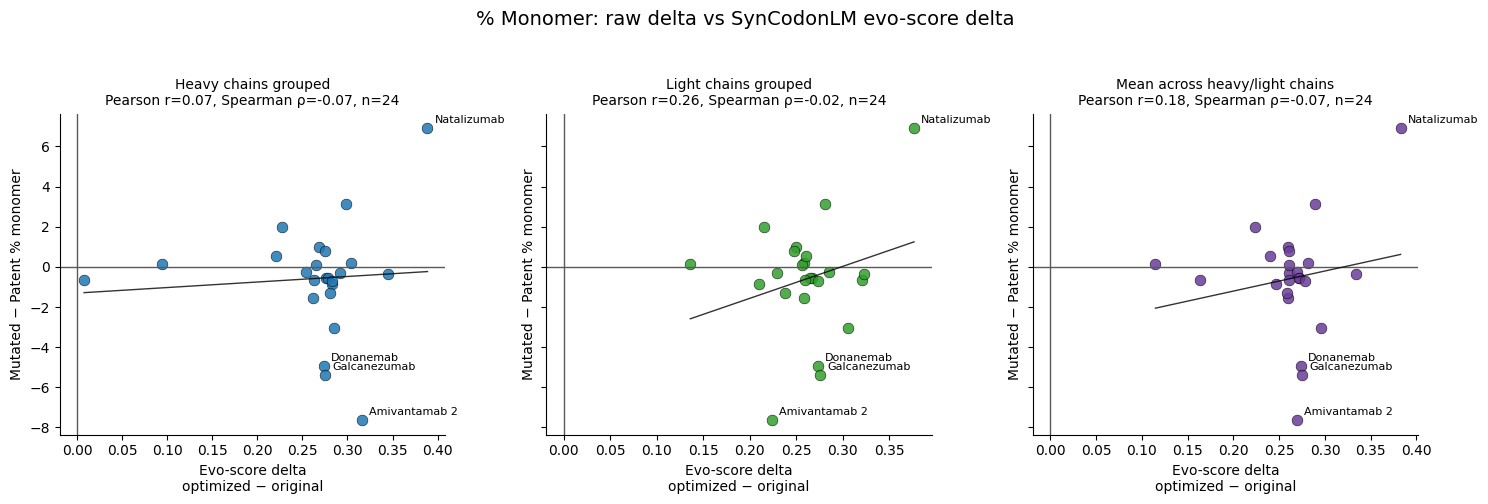

Saved:
 - Figure_MonomerDelta_vs_EvoScoreDelta_HeavyLightMean.pdf


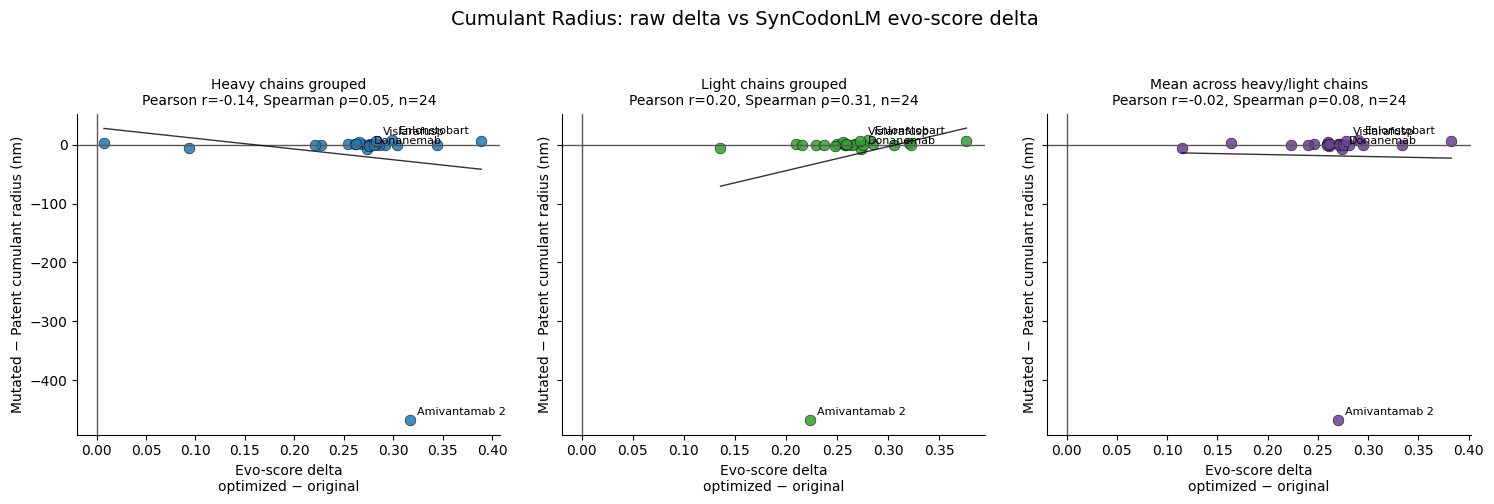

Saved:
 - Figure_CumulantRadiusDelta_vs_EvoScoreDelta_HeavyLightMean.pdf


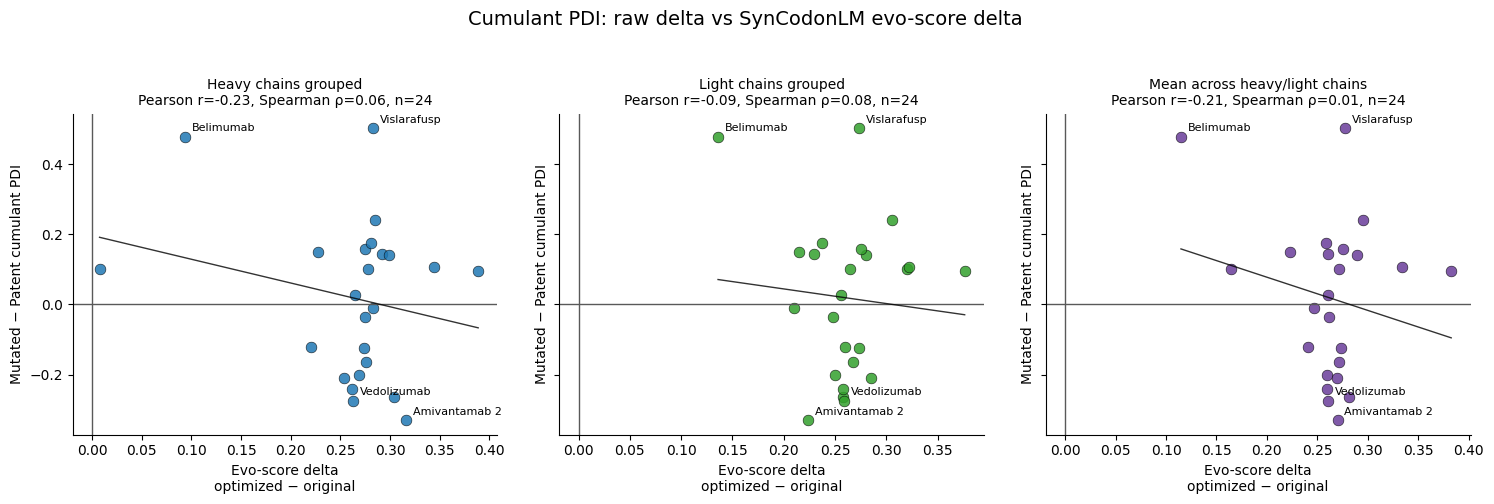

Saved:
 - Figure_CumulantPDIDelta_vs_EvoScoreDelta_HeavyLightMean.pdf

Mean-level preview:


,Therapeutic,Mean_Evo_Score_Delta,N_Chains_Total,Titer_PlotValue,% Monomer_PlotValue,Cumulant Radius_PlotValue,Cumulant PDI_PlotValue
1,Amivantamab 2,0.269999,2,3.703162,-7.640000,-467.414044,-0.329300
18,Natalizumab,0.382645,2,2.802830,6.913333,6.314640,0.095201
17,Mirikizumab,0.261254,2,2.057382,0.793333,-2.900620,-0.036021
15,Marlotamig,0.223122,3,0.998638,1.980000,-0.675154,0.149473
14,Infliximab,0.259612,2,0.584083,-1.543333,0.854498,-0.242348
7,Concizumab,0.295331,2,0.575122,-3.050000,-0.683002,0.241954
23,Vislarafusp,0.277733,2,0.558430,-0.690000,6.991168,0.502901
8,Daclizumab,0.271648,2,0.469876,-0.551667,1.746804,-0.164516
19,Nirsevimab,0.333489,2,0.457818,-0.356667,-0.636737,0.107676
9,Donanemab,0.273584,2,0.431194,-4.973333,-7.441293,-0.125272


In [11]:
# ============================================================# ================================================= delta
# Heavy chains grouped together, Light chains grouped together
#
# Titer is plotted as log2 fold-change:
#   log2(Mutated / Patent)
#
# Other metrics are plotted as raw deltas:
#   Mutated - Patent
#
# Makes one figure per metric:
#   - Titer log2FC
#   - % Monomer delta
#   - Cumulant Radius delta
#   - Cumulant PDI delta
#
# Each figure has panels for:
#   - Heavy chains grouped
#   - Light chains grouped
#   - Mean across heavy/light chains
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# -----------------------------
# Input files
# -----------------------------
DATA_FILE = "master-data.xlsx"
SCORE_FILE = "patented+mutated-sequences-with-evo-scores.xlsx"

# -----------------------------
# User settings
# -----------------------------
ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

TOO_LOW_AS = np.nan

# Evo score choice
# Positive values mean optimized sequence scored better than original.
ORIG_SCORE_COL = "Original_DNA_synonym_constrained_mean_logprob"
OPT_SCORE_COL  = "Optimized_DNA_synonym_constrained_mean_logprob"

# If you want full construct including signal peptide instead, use:
# ORIG_SCORE_COL = "Original_DNA_w_Signal_synonym_constrained_mean_logprob"
# OPT_SCORE_COL  = "Optimized_DNA_w_Signal_synonym_constrained_mean_logprob"

# Metric definitions
# transform:
#   "log2fc" = log2(Mutated / Patent)
#   "delta"  = Mutated - Patent
METRICS_TO_PLOT = {
    "Titer": {
        "mode": "pattern",
        "pattern": r"^Titer\s*mg/L\s*Rep\s*\d+$",
        "transform": "log2fc",
        "ylabel": f"log2({MUT_LABEL} / {PARENT_LABEL}) titer",
        "neutral": 0,
        "outfile": "Figure_Titer_log2FC_vs_EvoScoreDelta_HeavyLightMean.pdf"
    },
    "% Monomer": {
        "mode": "pattern",
        "pattern": r"^%\s*Monomer\s*Rep\s*\d+$",
        "transform": "delta",
        "ylabel": f"{MUT_LABEL} − {PARENT_LABEL} % monomer",
        "neutral": 0,
        "outfile": "Figure_MonomerDelta_vs_EvoScoreDelta_HeavyLightMean.pdf"
    },
    "Cumulant Radius": {
        "mode": "direct",
        "column": "Cumulant Radius (nm) mean",
        "transform": "delta",
        "ylabel": f"{MUT_LABEL} − {PARENT_LABEL} cumulant radius (nm)",
        "neutral": 0,
        "outfile": "Figure_CumulantRadiusDelta_vs_EvoScoreDelta_HeavyLightMean.pdf"
    },
    "Cumulant PDI": {
        "mode": "direct",
        "column": "Cumulant PDI mean",
        "transform": "delta",
        "ylabel": f"{MUT_LABEL} − {PARENT_LABEL} cumulant PDI",
        "neutral": 0,
        "outfile": "Figure_CumulantPDIDelta_vs_EvoScoreDelta_HeavyLightMean.pdf"
    }
}

COLOR_HEAVY = "#1f78b4"
COLOR_LIGHT = "#33a02c"
COLOR_MEAN = "#6a3d9a"

# -----------------------------
# Helper functions
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS,
            "too low": TOO_LOW_AS,
            "TOO LOW": TOO_LOW_AS,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

def get_chain_group(chain_name):
    chain_name = str(chain_name).strip().lower()
    if chain_name.startswith("heavy"):
        return "Heavy"
    elif chain_name.startswith("light"):
        return "Light"
    else:
        return "Other"

def plot_panel(ax, data, x_col, y_col, title, color, y_label, neutral=0):
    d = data[[x_col, y_col, "Therapeutic"]].replace([np.inf, -np.inf], np.nan).dropna()

    ax.scatter(
        d[x_col],
        d[y_col],
        s=60,
        color=color,
        edgecolor="black",
        linewidth=0.4,
        alpha=0.85
    )

    ax.axvline(0, color="0.35", lw=1)
    ax.axhline(neutral, color="0.35", lw=1)

    # Trend line
    if len(d) >= 3 and d[x_col].nunique() > 1:
        slope, intercept = np.polyfit(d[x_col], d[y_col], 1)
        xs = np.linspace(d[x_col].min(), d[x_col].max(), 100)
        ax.plot(xs, slope * xs + intercept, color="black", lw=1, alpha=0.8)

    pearson_r = d[x_col].corr(d[y_col], method="pearson") if len(d) >= 3 else np.nan
    spearman_r = d[x_col].corr(d[y_col], method="spearman") if len(d) >= 3 else np.nan

    ax.set_title(
        f"{title}\nPearson r={pearson_r:.2f}, Spearman ρ={spearman_r:.2f}, n={len(d)}",
        fontsize=10
    )

    ax.set_xlabel("Evo-score delta\noptimized − original")
    ax.set_ylabel(y_label)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Label strongest deviations from neutral
    label_df = d.reindex((d[y_col] - neutral).abs().sort_values(ascending=False).head(4).index)

    for _, r in label_df.iterrows():
        ax.annotate(
            r["Therapeutic"],
            (r[x_col], r[y_col]),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=8
        )

# -----------------------------
# Load and parse experimental data
# -----------------------------
df = pd.read_excel(DATA_FILE, engine="openpyxl")

df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

# -----------------------------
# Build metric summary table
# -----------------------------
all_metric_wides = []

for metric_name, cfg in METRICS_TO_PLOT.items():

    if cfg["mode"] == "pattern":
        metric_cols = [
            c for c in df.columns
            if re.match(cfg["pattern"], str(c).strip(), re.IGNORECASE)
        ]
        metric_cols = sorted(metric_cols, key=rep_num)

        if len(metric_cols) == 0:
            print(f"Skipping {metric_name}: no columns matched pattern {cfg['pattern']}")
            continue

        for c in metric_cols:
            df[c] = clean_numeric(df[c])

        df[f"{metric_name}_Mean_row"] = df[metric_cols].mean(axis=1, skipna=True)

    elif cfg["mode"] == "direct":
        metric_col = cfg["column"]

        if metric_col not in df.columns:
            print(f"Skipping {metric_name}: column not found: {metric_col}")
            continue

        df[metric_col] = clean_numeric(df[metric_col])
        df[f"{metric_name}_Mean_row"] = df[metric_col]

    else:
        raise ValueError(f"Unknown metric mode for {metric_name}: {cfg['mode']}")

    long = (
        df.groupby(["Base_Molecule", "Variant"], dropna=False)
          .agg(Metric_Mean=(f"{metric_name}_Mean_row", "mean"))
          .reset_index()
    )

    wide = long.pivot(
        index="Base_Molecule",
        columns="Variant",
        values="Metric_Mean"
    ).reset_index()

    for v in [PARENT_LABEL, MUT_LABEL]:
        if v not in wide.columns:
            wide[v] = np.nan

    wide[f"{metric_name}_Patent_Mean"] = wide[PARENT_LABEL]
    wide[f"{metric_name}_Mutated_Mean"] = wide[MUT_LABEL]

    if cfg["transform"] == "log2fc":
        all_positive = wide[[PARENT_LABEL, MUT_LABEL]].values.flatten()
        all_positive = all_positive[np.isfinite(all_positive) & (all_positive > 0)]
        eps = 0.01 * np.min(all_positive) if len(all_positive) else 1e-6

        wide[f"{metric_name}_PlotValue"] = np.log2(
            (wide[MUT_LABEL] + eps) /
            (wide[PARENT_LABEL] + eps)
        )

    elif cfg["transform"] == "delta":
        wide[f"{metric_name}_PlotValue"] = wide[MUT_LABEL] - wide[PARENT_LABEL]

    else:
        raise ValueError(f"Unknown transform for {metric_name}: {cfg['transform']}")

    keep = wide[[
        "Base_Molecule",
        f"{metric_name}_Patent_Mean",
        f"{metric_name}_Mutated_Mean",
        f"{metric_name}_PlotValue"
    ]].copy()

    all_metric_wides.append(keep)

# Merge all metric summaries
summary = None
for mdf in all_metric_wides:
    if summary is None:
        summary = mdf.copy()
    else:
        summary = summary.merge(mdf, on="Base_Molecule", how="outer")

summary = summary.rename(columns={"Base_Molecule": "Therapeutic"})

# -----------------------------
# Load SynCodonLM score data
# -----------------------------
score_df = pd.read_excel(
    SCORE_FILE,
    sheet_name="Scored_Sequences",
    engine="openpyxl"
)

score_df["Therapeutic"] = score_df["Therapeutic"].astype(str).str.strip()
score_df["Chain"] = score_df["Chain"].astype(str).str.strip()
score_df["Chain_Group"] = score_df["Chain"].apply(get_chain_group)

for c in [ORIG_SCORE_COL, OPT_SCORE_COL]:
    score_df[c] = pd.to_numeric(score_df[c], errors="coerce")

score_df["Evo_Score_Delta"] = score_df[OPT_SCORE_COL] - score_df[ORIG_SCORE_COL]

# Keep Heavy and Light only
score_df = score_df[score_df["Chain_Group"].isin(["Heavy", "Light"])].copy()

# Average Heavy 1/Heavy 2 together and Light 1/Light 2 together
score_grouped = (
    score_df.groupby(["Therapeutic", "Chain_Group"], dropna=False)
            .agg(
                Evo_Score_Delta=("Evo_Score_Delta", "mean"),
                N_Chains=("Evo_Score_Delta", "count")
            )
            .reset_index()
)

# Mean across all available heavy/light chains per molecule
score_mean = (
    score_df.groupby("Therapeutic", dropna=False)
            .agg(
                Mean_Evo_Score_Delta=("Evo_Score_Delta", "mean"),
                N_Chains_Total=("Evo_Score_Delta", "count")
            )
            .reset_index()
)

# Merge experimental metrics with evo scores
merged_grouped = score_grouped.merge(summary, on="Therapeutic", how="inner")
merged_mean = score_mean.merge(summary, on="Therapeutic", how="inner")

# -----------------------------
# QC
# -----------------------------
print("Experimental molecules:", summary["Therapeutic"].nunique())
print("Scored therapeutics:", score_df["Therapeutic"].nunique())
print("Merged molecules:", merged_mean["Therapeutic"].nunique())

print("\nChain groups:")
print(score_grouped.groupby("Chain_Group")["Therapeutic"].nunique())

print("\nAvailable plot-value columns:")
print([c for c in summary.columns if c.endswith("_PlotValue")])

# -----------------------------
# Make one figure per metric
# -----------------------------
for metric_name, cfg in METRICS_TO_PLOT.items():

    y_col = f"{metric_name}_PlotValue"

    if y_col not in summary.columns:
        print(f"Skipping figure for {metric_name}: {y_col} not found.")
        continue

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(15, 4.8),
        sharey=True
    )

    # Heavy panel
    heavy_df = merged_grouped[merged_grouped["Chain_Group"] == "Heavy"].copy()
    plot_panel(
        ax=axes[0],
        data=heavy_df,
        x_col="Evo_Score_Delta",
        y_col=y_col,
        title="Heavy chains grouped",
        color=COLOR_HEAVY,
        y_label=cfg["ylabel"],
        neutral=cfg["neutral"]
    )

    # Light panel
    light_df = merged_grouped[merged_grouped["Chain_Group"] == "Light"].copy()
    plot_panel(
        ax=axes[1],
        data=light_df,
        x_col="Evo_Score_Delta",
        y_col=y_col,
        title="Light chains grouped",
        color=COLOR_LIGHT,
        y_label=cfg["ylabel"],
        neutral=cfg["neutral"]
    )

    # Mean all chains panel
    mean_plot_df = merged_mean.rename(
        columns={"Mean_Evo_Score_Delta": "Evo_Score_Delta"}
    )

    plot_panel(
        ax=axes[2],
        data=mean_plot_df,
        x_col="Evo_Score_Delta",
        y_col=y_col,
        title="Mean across heavy/light chains",
        color=COLOR_MEAN,
        y_label=cfg["ylabel"],
        neutral=cfg["neutral"]
    )

    if cfg["transform"] == "log2fc":
        title_transform = "log2 fold-change"
    else:
        title_transform = "raw delta"

    fig.suptitle(
        f"{metric_name}: {title_transform} vs SynCodonLM evo-score delta",
        fontsize=14,
        y=1.04
    )

    plt.tight_layout()
    fig.savefig(cfg["outfile"], bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(" -", cfg["outfile"])

# -----------------------------
# Preview table
# -----------------------------
preview_cols = [
    "Therapeutic",
    "Mean_Evo_Score_Delta",
    "N_Chains_Total"
] + [c for c in summary.columns if c.endswith("_PlotValue")]

print("\nMean-level preview:")
display(
    merged_mean[preview_cols]
    .sort_values("Titer_PlotValue", ascending=False)
    .head(10)
)


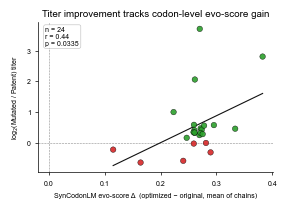

Saved: Figure_Titer_log2FC_vs_EvoDelta_MeanChains.svg
Molecules plotted: 24


In [12]:
# ============================================================
# Nature-style single-panel figure:
#   Titer log2FC  vs  mean-across-chains SynCodonLM evo-score delta
# Saves as editable SVG for Illustrator.
# Requires `merged_mean` and `summary` to already exist from the
# previous cell.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import stats

# ---------- Style ----------
MM_TO_INCH = 1 / 25.4
FIG_W_MM, FIG_H_MM = 70, 50              # smaller supporting panel
FIGSIZE = (FIG_W_MM * MM_TO_INCH, FIG_H_MM * MM_TO_INCH)

FONT = "Arial"
TITLE_FS   = 7
AXIS_FS    = 5
TICK_FS    = 5
STAT_FS    = 5

# Green / red by titer direction (log2FC > 0 vs <= 0)
COLOR_UP    = "#2ca02c"
COLOR_DOWN  = "#d62728"
FIT_COLOR   = "#111111"
GUIDE_COLOR = "0.55"

OUT_SVG = "Figure_Titer_log2FC_vs_EvoDelta_MeanChains.svg"

plt.rcParams.update({
    "svg.fonttype": "none",          # keep text editable in Illustrator
    "pdf.fonttype": 42,
    "font.family":  FONT,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
})

# ---------- Data ----------
y_col = "Titer_PlotValue"

plot_df = (
    merged_mean
    .rename(columns={"Mean_Evo_Score_Delta": "Evo_Score_Delta"})
    [["Therapeutic", "Evo_Score_Delta", y_col]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

x = plot_df["Evo_Score_Delta"].to_numpy()
y = plot_df[y_col].to_numpy()
n = len(plot_df)

# Regression + Pearson only
slope, intercept, r_p, p_p, se = stats.linregress(x, y)

# Fit line (no CI band)
x_grid = np.linspace(x.min(), x.max(), 200)
y_hat  = slope * x_grid + intercept

# Point colors by direction
point_colors = np.where(y > 0, COLOR_UP, COLOR_DOWN)

# ---------- Figure ----------
fig, ax = plt.subplots(figsize=FIGSIZE)

# Zero guides
ax.axvline(0, color=GUIDE_COLOR, lw=0.4, ls="--", zorder=0)
ax.axhline(0, color=GUIDE_COLOR, lw=0.4, ls="--", zorder=0)

# Fit line only (no shaded CI band)
ax.plot(x_grid, y_hat, color=FIT_COLOR, lw=0.8, zorder=2)

# Points — green if titer improved, red if not; no labels
ax.scatter(x, y,
           s=16,
           c=point_colors,
           edgecolor="black",
           linewidth=0.3,
           alpha=0.9,
           zorder=3)

# Axes
ax.set_xlabel("SynCodonLM evo-score Δ  (optimized − original, mean of chains)",
              fontsize=AXIS_FS, fontname=FONT)
ax.set_ylabel(f"log$_2$({MUT_LABEL} / {PARENT_LABEL}) titer",
              fontsize=AXIS_FS, fontname=FONT)
ax.set_title("Titer improvement tracks codon-level evo-score gain",
             fontsize=TITLE_FS, fontname=FONT, pad=4)

ax.tick_params(axis="both", which="major", labelsize=TICK_FS)
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

for lab in ax.get_xticklabels() + ax.get_yticklabels():
    lab.set_fontname(FONT)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Stats box (top-left) — Pearson + p only
def fmt_p(p):
    return "p < 0.001" if p < 1e-3 else f"p = {p:.3g}"

stats_txt = (
    f"n = {n}\n"
    f"r = {r_p:.2f}\n"
    f"{fmt_p(p_p)}"
)
ax.text(0.03, 0.97, stats_txt,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=STAT_FS, fontname=FONT,
        bbox=dict(boxstyle="round,pad=0.25",
                  fc="white", ec="0.7", lw=0.4, alpha=0.9))

plt.tight_layout(pad=0.3)
fig.savefig(OUT_SVG, format="svg", bbox_inches="tight")
plt.show()

print("Saved:", OUT_SVG)
print(f"Molecules plotted: {n}")

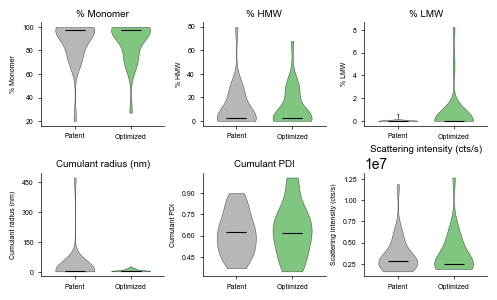

Saved: Figure_QualityAttributes_Violins.svg


In [13]:
# ============================================================
# Multipanel figure: Patent vs Optimized violin plots
# One SVG, 6 panels (ungroup in Illustrator)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

XLSX = "master-data.xlsx"
OUT_SVG = "Figure_QualityAttributes_Violins.svg"

# ---------- Style ----------
MM_TO_INCH = 1 / 25.4
PANEL_W_MM, PANEL_H_MM = 38, 32
NCOLS, NROWS = 3, 2
FIG_W_MM = PANEL_W_MM * NCOLS + 10
FIG_H_MM = PANEL_H_MM * NROWS + 10
FIGSIZE = (FIG_W_MM * MM_TO_INCH, FIG_H_MM * MM_TO_INCH)

FONT = "Arial"
TITLE_FS = 7
AXIS_FS  = 5
TICK_FS  = 5

COLOR_PAT = "#888888"
COLOR_OPT = "#2ca02c"

plt.rcParams.update({
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "font.family":  FONT,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
})

# ---------- Metrics ----------
metrics = [
    ("% Monomer",                    ["% Monomer Rep 1", "% Monomer Rep 2", "% Monomer Rep 3"], +1),
    ("% HMW",                        ["% HMW Rep 1", "% HMW Rep 2", "% HMW Rep 3"],             -1),
    ("% LMW",                        ["% LMW Rep 1", "% LMW Rep 2", "% LMW Rep 3"],             -1),
    ("Cumulant radius (nm)",         ["Cumulant Radius (nm) mean"],                             -1),
    ("Cumulant PDI",                 ["Cumulant PDI mean"],                                     -1),
    ("Scattering intensity (cts/s)", ["Scattering Intensity (cts/s) mean"],                     -1),
]

# ---------- Load & split ----------
df = pd.read_excel(XLSX, engine="openpyxl")

def split_name(m):
    m = str(m).strip()
    if m.endswith(" Mutated"):
        return m[:-8], "Mutated"
    if m.endswith(" Patent"):
        return m[:-7], "Patent"
    return m, np.nan

df[["Base", "Condition"]] = df["Molecule"].apply(lambda x: pd.Series(split_name(x)))

def per_mol(df, cols):
    d = df.copy()
    for c in cols:
        d[c] = pd.to_numeric(d[c], errors="coerce")
    d["_v"] = d[cols].mean(axis=1, skipna=True)
    out = {}
    for base, sub in d.groupby("Base"):
        v = {}
        for cond in ["Patent", "Mutated"]:
            r = sub[sub["Condition"] == cond]
            if len(r) == 1:
                v[cond] = r["_v"].iloc[0]
        if len(v) == 2 and np.isfinite(v["Patent"]) and np.isfinite(v["Mutated"]):
            out[base] = v
    return out

# ---------- Figure ----------
fig, axes = plt.subplots(NROWS, NCOLS, figsize=FIGSIZE)
axes = axes.flatten()

for ax, (name, cols, better_dir) in zip(axes, metrics):
    v = per_mol(df, cols)
    bases = sorted(v.keys())
    p_arr = np.array([v[b]["Patent"]  for b in bases], dtype=float)
    m_arr = np.array([v[b]["Mutated"] for b in bases], dtype=float)

    data = [p_arr, m_arr]
    positions = [0, 1]
    colors = [COLOR_PAT, COLOR_OPT]

    parts = ax.violinplot(data, positions=positions, widths=0.7,
                          showmeans=False, showmedians=False, showextrema=False)

    for body, c in zip(parts["bodies"], colors):
        body.set_facecolor(c)
        body.set_edgecolor("black")
        body.set_linewidth(0.4)
        body.set_alpha(0.6)

    # Median line inside each violin
    for pos, arr in zip(positions, data):
        med = np.nanmedian(arr)
        ax.hlines(med, pos - 0.18, pos + 0.18,
                  color="black", linewidth=0.8, zorder=4)

    # Axes cosmetics
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Patent", "Optimized"], fontsize=TICK_FS)
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel(name, fontsize=AXIS_FS)
    ax.set_title(name, fontsize=TITLE_FS, pad=4)
    ax.tick_params(axis="y", labelsize=TICK_FS)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for extra_ax in axes[len(metrics):]:
    extra_ax.axis("off")

plt.tight_layout(pad=0.4)
fig.savefig(OUT_SVG, format="svg", bbox_inches="tight")
plt.show()
print("Saved:", OUT_SVG)

In [14]:
from scipy.stats import ttest_rel, wilcoxon
import pandas as pd
import numpy as np

results = []

for name, cols, better_dir in metrics:

    v = per_mol(df, cols)
    bases = sorted(v.keys())

    patent = np.array([v[b]["Patent"] for b in bases], dtype=float)
    optimized = np.array([v[b]["Mutated"] for b in bases], dtype=float)

    delta = optimized - patent

    # Paired t-test
    t_stat, t_p = ttest_rel(optimized, patent)

    # Wilcoxon signed-rank
    nz = delta != 0
    if nz.sum() > 0:
        w_stat, w_p = wilcoxon(
            optimized[nz],
            patent[nz],
            zero_method="wilcox"
        )
    else:
        w_stat, w_p = np.nan, np.nan

    # Directionality
    if better_dir == 1:
        improvement_pct = 100 * np.mean(delta > 0)
    else:
        improvement_pct = 100 * np.mean(delta < 0)

    results.append({
        "Metric": name,
        "N molecules": len(patent),
        "Mean Patent": np.mean(patent),
        "Mean Optimized": np.mean(optimized),
        "Mean Δ": np.mean(delta),
        "Median Δ": np.median(delta),
        "Paired t-test p": t_p,
        "Wilcoxon p": w_p,
        "% Improved": improvement_pct
    })

results_df = pd.DataFrame(results)

# Optional multiple-testing correction
from statsmodels.stats.multitest import multipletests

results_df["BH-adjusted p"] = multipletests(
    results_df["Wilcoxon p"],
    method="fdr_bh"
)[1]

display(results_df)

print(
    results_df[
        ["Metric",
         "N molecules",
         "Mean Δ",
         "Paired t-test p",
         "Wilcoxon p",
         "BH-adjusted p"]
    ]
)

,Metric,N molecules,Mean Patent,Mean Optimized,Mean Δ,Median Δ,Paired t-test p,Wilcoxon p,% Improved,BH-adjusted p
0,% Monomer,24,8.832507e+01,8.773764e+01,-0.587431,-0.454167,0.319284,0.177980,37.500000,0.640625
1,% HMW,24,1.164674e+01,1.184625e+01,0.199514,0.331667,0.773216,0.218219,33.333333,0.640625
2,% LMW,24,2.805556e-02,5.543056e-01,0.526250,0.000000,0.195447,0.320312,16.666667,0.640625
3,Cumulant radius (nm),24,2.720197e+01,8.262786e+00,-18.939181,-0.195523,0.341831,0.725741,54.166667,1.000000
4,Cumulant PDI,24,6.178651e-01,6.363943e-01,0.018529,0.060619,0.688312,1.000000,45.833333,1.000000
5,Scattering intensity (cts/s),24,3.591949e+06,3.746471e+06,154522.138193,-53905.500954,0.748883,0.855336,50.000000,1.000000


                         Metric  N molecules         Mean Δ  Paired t-test p  \
0                     % Monomer           24      -0.587431         0.319284   
1                         % HMW           24       0.199514         0.773216   
2                         % LMW           24       0.526250         0.195447   
3          Cumulant radius (nm)           24     -18.939181         0.341831   
4                  Cumulant PDI           24       0.018529         0.688312   
5  Scattering intensity (cts/s)           24  154522.138193         0.748883   

   Wilcoxon p  BH-adjusted p  
0    0.177980       0.640625  
1    0.218219       0.640625  
2    0.320312       0.640625  
3    0.725741       1.000000  
4    1.000000       1.000000  
5    0.855336       1.000000  


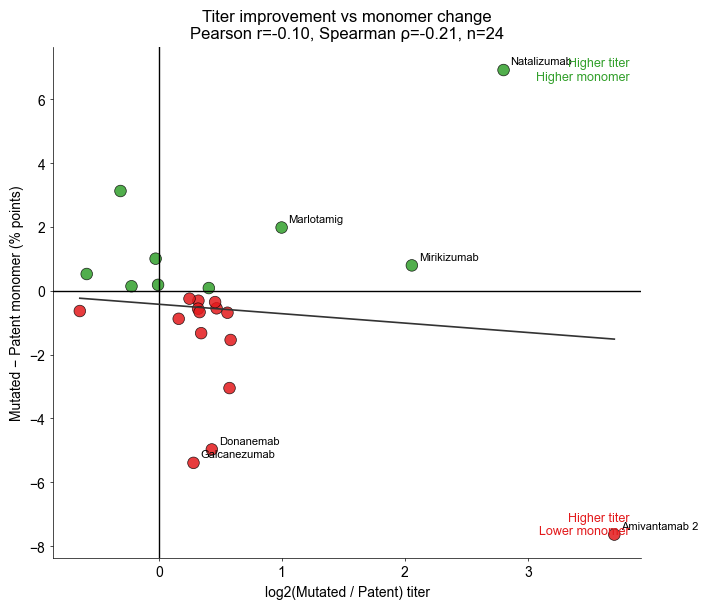

Saved:
 - Figure_TiterLog2FC_vs_MonomerDelta.pdf

Summary preview:


,Base_Molecule,Patent_Titer,Mutated_Titer,Titer_log2FC,Titer_Delta_mgL,Patent_Monomer,Mutated_Monomer,Monomer_Delta_pct_points
1,Amivantamab 2,15.799506,206.309949,3.703162,190.510443,78.420000,70.780000,-7.640000
18,Natalizumab,4.394343,30.926761,2.802830,26.532418,20.303333,27.216667,6.913333
17,Mirikizumab,20.660510,86.134258,2.057382,65.473748,97.190000,97.983333,0.793333
15,Marlotamig,68.946487,137.806694,0.998638,68.860207,70.663333,72.643333,1.980000
14,Infliximab,101.899989,152.778763,0.584083,50.878773,98.320000,96.776667,-1.543333
7,Concizumab,90.379066,134.668572,0.575122,44.289507,76.476667,73.426667,-3.050000
23,Vislarafusp,218.870337,322.343509,0.558430,103.473172,98.546667,97.856667,-0.690000
8,Daclizumab,216.671302,300.104532,0.469876,83.433230,98.425000,97.873333,-0.551667
19,Nirsevimab,231.070697,317.383378,0.457818,86.312681,98.693333,98.336667,-0.356667
9,Donanemab,219.272000,295.670523,0.431194,76.398522,99.653333,94.680000,-4.973333


In [15]:
# ============================================================
# Titer change vs monomer change
#
# x-axis:
#   log2(Mutated / Patent) titer
#
# y-axis:
#   Mutated - Patent % monomer
#
# Interpretation:
#   x > 0 = mutated has higher titer
#   y > 0 = mutated has higher % monomer
#   upper-right = improved titer and improved monomer
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# -----------------------------
# Input / output
# -----------------------------
INPUT_FILE = "master-data.xlsx"
OUT_FILE = "Figure_TiterLog2FC_vs_MonomerDelta.pdf"

ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"

TOO_LOW_AS = np.nan

COLOR_POS_MONOMER = "#33a02c"
COLOR_NEG_MONOMER = "#e31a1c"

# -----------------------------
# Load data
# -----------------------------
df = pd.read_excel(INPUT_FILE, engine="openpyxl")

df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

# Parse molecule names
parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)

df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

# -----------------------------
# Helpers
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS,
            "too low": TOO_LOW_AS,
            "TOO LOW": TOO_LOW_AS,
            "": np.nan,
            " ": np.nan,
            "NA": np.nan,
            "na": np.nan
        }),
        errors="coerce"
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

# -----------------------------
# Identify titer and monomer replicate columns
# -----------------------------
titer_cols = [
    c for c in df.columns
    if re.match(r"^Titer\s*mg/L\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

monomer_cols = [
    c for c in df.columns
    if re.match(r"^%\s*Monomer\s*Rep\s*\d+$", str(c).strip(), re.IGNORECASE)
]

titer_cols = sorted(titer_cols, key=rep_num)
monomer_cols = sorted(monomer_cols, key=rep_num)

if len(titer_cols) == 0:
    raise ValueError("No titer replicate columns found.")

if len(monomer_cols) == 0:
    raise ValueError("No % Monomer replicate columns found.")

# Clean numeric values
for c in titer_cols + monomer_cols:
    df[c] = clean_numeric(df[c])

# -----------------------------
# Compute per-row means
# -----------------------------
df["Titer_Mean_row"] = df[titer_cols].mean(axis=1, skipna=True)
df["Monomer_Mean_row"] = df[monomer_cols].mean(axis=1, skipna=True)

# -----------------------------
# Aggregate to one row per molecule / variant
# -----------------------------
summary_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(
          Titer_Mean=("Titer_Mean_row", "mean"),
          Monomer_Mean=("Monomer_Mean_row", "mean")
      )
      .reset_index()
)

# Pivot titer
titer_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Titer_Mean"
).reset_index()

# Pivot monomer
monomer_wide = summary_long.pivot(
    index="Base_Molecule",
    columns="Variant",
    values="Monomer_Mean"
).reset_index()

for v in [PARENT_LABEL, MUT_LABEL]:
    if v not in titer_wide.columns:
        titer_wide[v] = np.nan
    if v not in monomer_wide.columns:
        monomer_wide[v] = np.nan

summary = pd.DataFrame({
    "Base_Molecule": titer_wide["Base_Molecule"],
    "Patent_Titer": titer_wide[PARENT_LABEL],
    "Mutated_Titer": titer_wide[MUT_LABEL],
    "Patent_Monomer": monomer_wide[PARENT_LABEL],
    "Mutated_Monomer": monomer_wide[MUT_LABEL]
})

# -----------------------------
# Calculate plot variables
# -----------------------------
# Small pseudocount for titer stability
all_positive_titers = summary[["Patent_Titer", "Mutated_Titer"]].values.flatten()
all_positive_titers = all_positive_titers[
    np.isfinite(all_positive_titers) & (all_positive_titers > 0)
]

eps = 0.01 * np.min(all_positive_titers) if len(all_positive_titers) else 1e-6

summary["Titer_log2FC"] = np.log2(
    (summary["Mutated_Titer"] + eps) /
    (summary["Patent_Titer"] + eps)
)

summary["Titer_Delta_mgL"] = summary["Mutated_Titer"] - summary["Patent_Titer"]

summary["Monomer_Delta_pct_points"] = (
    summary["Mutated_Monomer"] - summary["Patent_Monomer"]
)

plot_df = summary.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["Titer_log2FC", "Monomer_Delta_pct_points"]
).copy()

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(7.2, 6.2))

colors = np.where(
    plot_df["Monomer_Delta_pct_points"] >= 0,
    COLOR_POS_MONOMER,
    COLOR_NEG_MONOMER
)

ax.scatter(
    plot_df["Titer_log2FC"],
    plot_df["Monomer_Delta_pct_points"],
    s=70,
    color=colors,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.85
)

# Reference lines
ax.axvline(0, color="black", lw=1)
ax.axhline(0, color="black", lw=1)

# Optional trend line
if len(plot_df) >= 3 and plot_df["Titer_log2FC"].nunique() > 1:
    slope, intercept = np.polyfit(
        plot_df["Titer_log2FC"],
        plot_df["Monomer_Delta_pct_points"],
        1
    )
    xs = np.linspace(
        plot_df["Titer_log2FC"].min(),
        plot_df["Titer_log2FC"].max(),
        100
    )
    ax.plot(xs, slope * xs + intercept, color="0.2", lw=1.2)

# Correlations
pearson_r = plot_df["Titer_log2FC"].corr(
    plot_df["Monomer_Delta_pct_points"],
    method="pearson"
)

spearman_r = plot_df["Titer_log2FC"].corr(
    plot_df["Monomer_Delta_pct_points"],
    method="spearman"
)

# Label strongest effects:
# top absolute titer changes and top absolute monomer changes
label_idx = set(
    plot_df["Titer_log2FC"].abs().sort_values(ascending=False).head(4).index
).union(
    set(plot_df["Monomer_Delta_pct_points"].abs().sort_values(ascending=False).head(4).index)
)

for idx in label_idx:
    r = plot_df.loc[idx]
    ax.annotate(
        str(r["Base_Molecule"]),
        (r["Titer_log2FC"], r["Monomer_Delta_pct_points"]),
        textcoords="offset points",
        xytext=(5, 4),
        fontsize=8
    )

# Quadrant labels
ax.text(
    0.98, 0.98,
    "Higher titer\nHigher monomer",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color=COLOR_POS_MONOMER
)

ax.text(
    0.98, 0.04,
    "Higher titer\nLower monomer",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color=COLOR_NEG_MONOMER
)

ax.set_xlabel(f"log2({MUT_LABEL} / {PARENT_LABEL}) titer")
ax.set_ylabel(f"{MUT_LABEL} − {PARENT_LABEL} monomer (% points)")

ax.set_title(
    f"Titer improvement vs monomer change\n"
    f"Pearson r={pearson_r:.2f}, Spearman ρ={spearman_r:.2f}, n={len(plot_df)}"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_FILE, bbox_inches="tight")
plt.show()

print("Saved:")
print(" -", OUT_FILE)

print("\nSummary preview:")
display(
    plot_df[
        [
            "Base_Molecule",
            "Patent_Titer",
            "Mutated_Titer",
            "Titer_log2FC",
            "Titer_Delta_mgL",
            "Patent_Monomer",
            "Mutated_Monomer",
            "Monomer_Delta_pct_points"
        ]
    ].sort_values("Titer_log2FC", ascending=False)
)

In [16]:
# ============================================================
# Filter rare_codon_extract.xlsx by molecule (from codons-data-new)
# AND add CpG/UpA dinucleotide columns from sequence file.
#
# Step 1: Build allowed therapeutic set from codons-data-new.xlsx
# Step 2: Safety-check the filter — abort if it would delete everything
# Step 3: Delete non-matching rows from rare_codon_extract.xlsx
# Step 4: Compute CpG_OE / UpA_OE / CpG_freq / UpA_freq from sequences
# Step 5: Append those 4 columns and fill values into kept rows
#
# Everything else in the workbook is preserved.
# ============================================================

import re
import shutil
import numpy as np
import pandas as pd
from openpyxl import load_workbook

# -----------------------------
# Files
# -----------------------------
STATS_FILE  = "heuristic-statistical-descriptors.xlsx"
STATS_SHEET = "All_Data"
TITER_FILE  = "master-data.xlsx"
TITER_SHEET = 0
ID_COL      = "Molecule"

SEQ_FILE    = "patented+mutated-sequences-with-evo-scores.xlsx"
SEQ_SHEET   = "Scored_Sequences"
PAT_SEQ_COL = "Original_DNA"
OPT_SEQ_COL = "Optimized_DNA"

NEW_COLUMNS = ["CpG_OE", "UpA_OE", "CpG_freq", "UpA_freq"]

MAKE_BACKUP = True
BACKUP_FILE = "rare_codon_extract_BACKUP.xlsx"

# -----------------------------
# Helpers
# -----------------------------
def normalize_therapeutic(s):
    return re.sub(r"\s+", " ", str(s).strip())

def normalize_chain_id(s):
    return re.sub(r"\s+", " ", str(s).strip()).title()

def clean_dna(seq):
    if not isinstance(seq, str):
        return ""
    s = "".join(seq.split()).upper().replace("U", "T")
    return "".join(c if c in "ACGT" else "" for c in s)

def base_freqs(seq):
    n = len(seq)
    if n == 0:
        return {b: 0.0 for b in "ACGT"}
    return {b: seq.count(b) / n for b in "ACGT"}

def dinuc_count(seq, di):
    if len(seq) < 2:
        return 0
    return sum(1 for i in range(len(seq) - 1) if seq[i:i+2] == di)

def dinuc_oe(seq, di):
    if len(seq) < 2:
        return None
    n_dinuc = len(seq) - 1
    obs = dinuc_count(seq, di) / n_dinuc
    f = base_freqs(seq)
    expected = f.get(di[0], 0.0) * f.get(di[1], 0.0)
    return obs / expected if expected > 1e-12 else None

def dinuc_freq_per_nt(seq, di):
    if len(seq) < 2:
        return None
    return dinuc_count(seq, di) / len(seq)

# -----------------------------
# 1) Build allowed therapeutic set from codons-data-new
# -----------------------------
print(f"Reading molecules from {TITER_FILE}")
titer = pd.read_excel(TITER_FILE, sheet_name=TITER_SHEET, engine="openpyxl")
titer = titer.dropna(subset=[ID_COL]).copy()
titer[ID_COL] = titer[ID_COL].astype(str).str.strip()

parsed = titer[ID_COL].str.extract(
    r"^(?P<Base>.+?)\s+(?:Mutated|Patent)\s*$",
    flags=re.IGNORECASE,
)
allowed_therapeutics = set(
    parsed["Base"].dropna().apply(normalize_therapeutic).unique()
)
print(f"Allowed therapeutics: {len(allowed_therapeutics)}")

# -----------------------------
# 2) Build CpG/UpA metric lookup from sequence file
# -----------------------------
print(f"\nReading sequences from {SEQ_FILE}")
seq_df = pd.read_excel(SEQ_FILE, sheet_name=SEQ_SHEET, engine="openpyxl")
seq_df = seq_df.dropna(subset=["Therapeutic", "Chain",
                               PAT_SEQ_COL, OPT_SEQ_COL]).copy()

seq_df["Therapeutic_norm"] = seq_df["Therapeutic"].apply(normalize_therapeutic)
seq_df["ChainID_norm"]     = seq_df["Chain"].apply(normalize_chain_id)
seq_df[PAT_SEQ_COL]        = seq_df[PAT_SEQ_COL].apply(clean_dna)
seq_df[OPT_SEQ_COL]        = seq_df[OPT_SEQ_COL].apply(clean_dna)

metrics_lookup = {}
for _, row in seq_df.iterrows():
    ther = row["Therapeutic_norm"]
    cid  = row["ChainID_norm"]
    pat  = row[PAT_SEQ_COL]
    opt  = row[OPT_SEQ_COL]
    metrics_lookup[(ther, cid, "Patent")] = {
        "CpG_OE":   dinuc_oe(pat, "CG"),
        "UpA_OE":   dinuc_oe(pat, "TA"),
        "CpG_freq": dinuc_freq_per_nt(pat, "CG"),
        "UpA_freq": dinuc_freq_per_nt(pat, "TA"),
    }
    metrics_lookup[(ther, cid, "Mutated")] = {
        "CpG_OE":   dinuc_oe(opt, "CG"),
        "UpA_OE":   dinuc_oe(opt, "TA"),
        "CpG_freq": dinuc_freq_per_nt(opt, "CG"),
        "UpA_freq": dinuc_freq_per_nt(opt, "TA"),
    }
print(f"CpG/UpA metrics computed for {len(metrics_lookup)} sequence variants")

# -----------------------------
# 3) Backup
# -----------------------------
if MAKE_BACKUP:
    shutil.copy(STATS_FILE, BACKUP_FILE)
    print(f"\nBackup written: {BACKUP_FILE}")

# -----------------------------
# 4) Open rare_codon_extract.xlsx
# -----------------------------
print(f"\nOpening {STATS_FILE}")
wb = load_workbook(STATS_FILE)
if STATS_SHEET not in wb.sheetnames:
    raise ValueError(f"Sheet '{STATS_SHEET}' not found")
ws = wb[STATS_SHEET]

header = [cell.value for cell in ws[1]]
if "Chain" not in header:
    raise ValueError("Could not find 'Chain' column")
chain_col_idx = header.index("Chain") + 1

# -----------------------------
# 5) Scan rows — decide which to keep
# -----------------------------
chain_pattern = re.compile(
    r"^(?P<Therapeutic>.+?)\s+(?P<ChainID>(?:Heavy|Light)\s*\d+)\s+(?P<Variant>Patent|Mutated)\s*$",
    re.IGNORECASE,
)

rows_to_delete = []
kept_count = 0
unmatched_examples = []
unmatched_therapeutics = set()

for row_idx in range(2, ws.max_row + 1):
    chain_val = ws.cell(row=row_idx, column=chain_col_idx).value
    if not isinstance(chain_val, str):
        rows_to_delete.append(row_idx)
        continue

    m = chain_pattern.match(chain_val.strip())
    if not m:
        rows_to_delete.append(row_idx)
        if len(unmatched_examples) < 5:
            unmatched_examples.append(chain_val)
        continue

    ther = normalize_therapeutic(m.group("Therapeutic"))
    if ther in allowed_therapeutics:
        kept_count += 1
    else:
        rows_to_delete.append(row_idx)
        unmatched_therapeutics.add(ther)

print(f"\nRows to keep:   {kept_count}")
print(f"Rows to delete: {len(rows_to_delete)}")

# -----------------------------
# 6) Safety check — abort if everything would be deleted
# -----------------------------
if kept_count == 0:
    print("\nABORTING: filter would delete every row.")
    print("Likely a therapeutic-name mismatch between files.")
    print("\nAllowed (from codons-data-new):")
    for t in sorted(allowed_therapeutics)[:8]:
        print(f"   '{t}'")
    print("\nFound in rare_codon_extract (rejected):")
    for t in sorted(unmatched_therapeutics)[:10]:
        print(f"   '{t}'")
    print("\nNo changes saved.")
    raise SystemExit

print("\nTherapeutics dropped entirely:")
for t in sorted(unmatched_therapeutics):
    print(f"   {t}")
if unmatched_examples:
    print("\nUnparseable Chain values (deleted):")
    for ex in unmatched_examples:
        print(f"   {ex}")

# -----------------------------
# 7) Delete unwanted rows (bottom-up)
# -----------------------------
for row_idx in sorted(rows_to_delete, reverse=True):
    ws.delete_rows(row_idx, 1)
print(f"\nAfter deletion: {ws.max_row - 1} data rows")

# -----------------------------
# 8) Re-map current row positions → (Therapeutic, ChainID, Variant)
# (row numbers shifted from deletions)
# -----------------------------
current_rows = {}
for row_idx in range(2, ws.max_row + 1):
    chain_val = ws.cell(row=row_idx, column=chain_col_idx).value
    if not isinstance(chain_val, str):
        continue
    m = chain_pattern.match(chain_val.strip())
    if not m:
        continue
    ther = normalize_therapeutic(m.group("Therapeutic"))
    cid  = normalize_chain_id(m.group("ChainID"))
    var  = m.group("Variant").capitalize()
    current_rows[(ther, cid, var)] = row_idx

# -----------------------------
# 9) Append CpG/UpA column headers (or reuse existing)
# -----------------------------
header = [cell.value for cell in ws[1]]
existing_cols = set(header)
col_indices = {}

start_col_idx = ws.max_column + 1
next_idx = start_col_idx
for col_name in NEW_COLUMNS:
    if col_name in existing_cols:
        col_indices[col_name] = header.index(col_name) + 1
    else:
        ws.cell(row=1, column=next_idx, value=col_name)
        col_indices[col_name] = next_idx
        next_idx += 1

print(f"\nCpG/UpA columns at: {col_indices}")

# -----------------------------
# 10) Write CpG/UpA values into each kept row
# -----------------------------
n_written = 0
n_missing = 0
missing_examples = []

for key, row_idx in current_rows.items():
    metrics = metrics_lookup.get(key)
    if metrics is None:
        n_missing += 1
        if len(missing_examples) < 5:
            missing_examples.append(key)
        continue
    for col_name in NEW_COLUMNS:
        val = metrics.get(col_name)
        if val is not None and np.isfinite(val):
            ws.cell(row=row_idx, column=col_indices[col_name], value=float(val))
    n_written += 1

print(f"\nCpG/UpA rows filled:  {n_written}")
print(f"CpG/UpA rows missing: {n_missing}")
if missing_examples:
    print("Examples of kept rows missing CpG/UpA data:")
    for ex in missing_examples:
        print(f"   {ex}")

# -----------------------------
# 11) Save
# -----------------------------
wb.save(STATS_FILE)
print(f"\nSaved: {STATS_FILE}")
print(f"Final state: {ws.max_row - 1} rows × {ws.max_column} columns")

Reading molecules from master-data.xlsx
Allowed therapeutics: 24

Reading sequences from patented+mutated-sequences-with-evo-scores.xlsx
CpG/UpA metrics computed for 108 sequence variants

Backup written: rare_codon_extract_BACKUP.xlsx

Opening heuristic-statistical-descriptors.xlsx

Rows to keep:   98
Rows to delete: 0

Therapeutics dropped entirely:

After deletion: 98 data rows

CpG/UpA columns at: {'CpG_OE': 40, 'UpA_OE': 41, 'CpG_freq': 42, 'UpA_freq': 43}

CpG/UpA rows filled:  0
CpG/UpA rows missing: 98
Examples of kept rows missing CpG/UpA data:
   ('Amivantamab 1', 'Heavy 1', 'Patent')
   ('Amivantamab 1', 'Light 1', 'Patent')
   ('Amivantamab 2', 'Heavy 1', 'Patent')
   ('Amivantamab 2', 'Light 1', 'Patent')
   ('Belimumab', 'Heavy 1', 'Patent')

Saved: heuristic-statistical-descriptors.xlsx
Final state: 98 rows × 43 columns


Heavy n: 24
Light n: 24
Mean n: 24

Saved: StatMetrics_plus_Evo_vs_Titer_correlations_PearsonR.csv


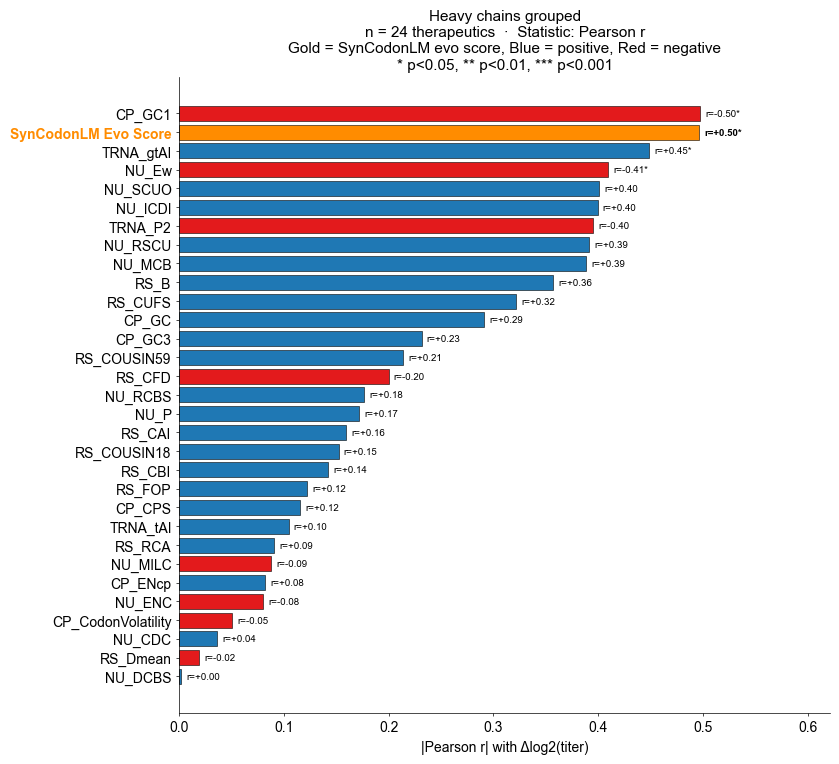

Saved: Figure_StatMetrics_plus_Evo_PearsonR_Heavy.pdf


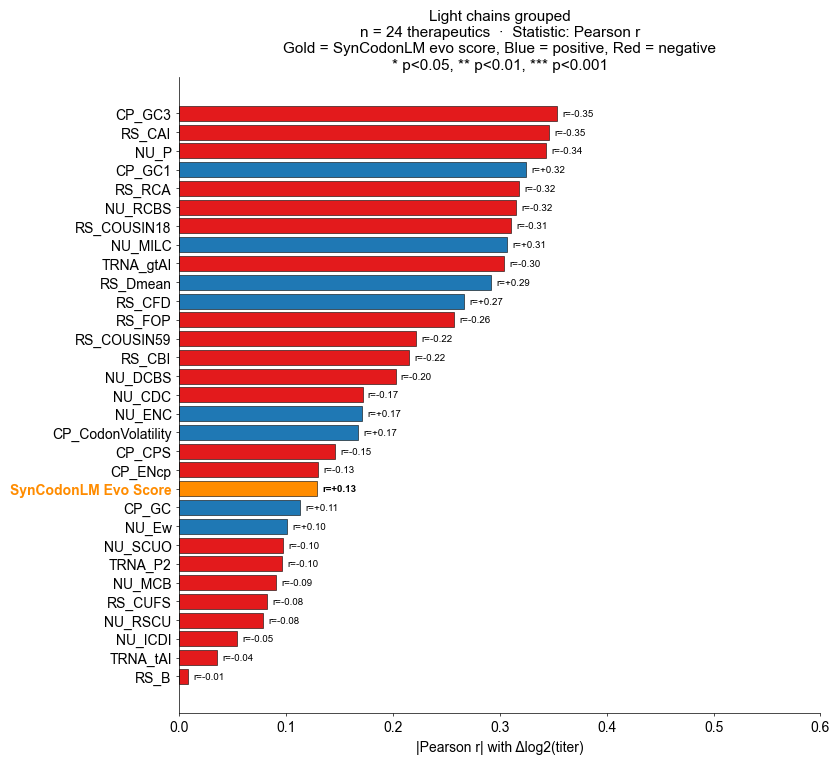

Saved: Figure_StatMetrics_plus_Evo_PearsonR_Light.pdf


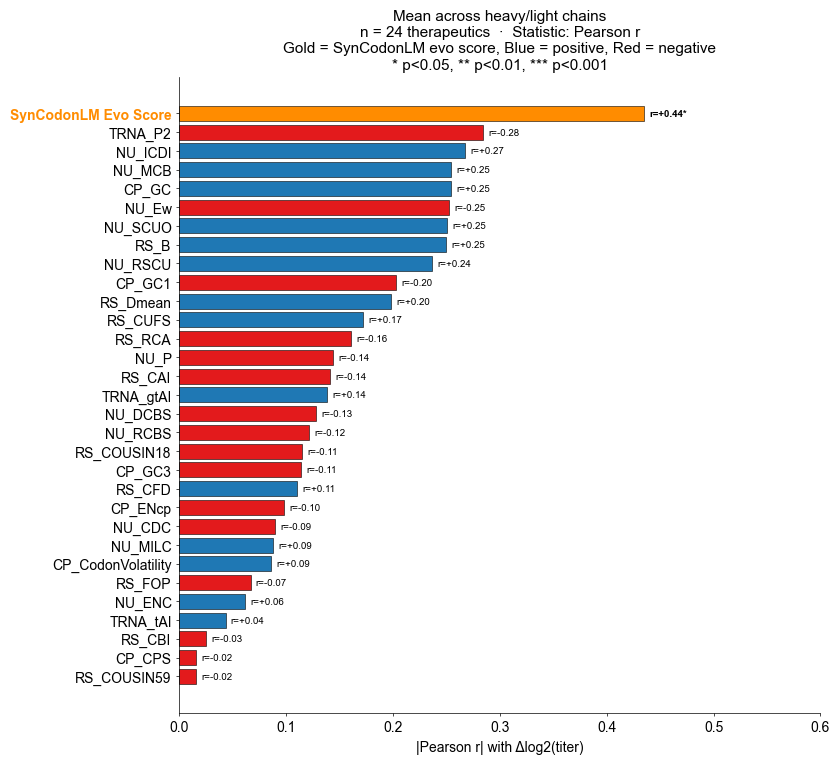

Saved: Figure_StatMetrics_plus_Evo_PearsonR_Mean.pdf

=== Heavy grouping (Pearson r) ===
Evo score rank: 2 of 31
Evo score r = +0.496, p = 1.36e-02

Top 5 metrics (incl. evo):
 Rank               Metric  Pearson r  p_value  n
    1               CP_GC1  -0.497044 0.013474 24
    2 SynCodonLM Evo Score   0.496318 0.013632 24
    3            TRNA_gtAI   0.448810 0.027815 24
    4                NU_Ew  -0.409660 0.046810 24
    5              NU_SCUO   0.400877 0.052215 24

=== Light grouping (Pearson r) ===
Evo score rank: 21 of 31
Evo score r = +0.129, p = 5.49e-01

Top 5 metrics (incl. evo):
 Rank Metric  Pearson r  p_value  n
    1 CP_GC3  -0.353876 0.097602 23
    2 RS_CAI  -0.346093 0.097592 24
    3   NU_P  -0.342937 0.100892 24
    4 CP_GC1   0.324683 0.121626 24
    5 RS_RCA  -0.317727 0.130289 24

=== Mean grouping (Pearson r) ===
Evo score rank: 1 of 31
Evo score r = +0.435, p = 3.35e-02

Top 5 metrics (incl. evo):
 Rank               Metric  Pearson r  p_value  n
    1 SynCod

In [17]:
# ============================================================
# Δlog2(titer) vs Δ(statistical metric) + SynCodonLM evo score
# Three separate bar chart figures (one per chain grouping)
#
# SELECT YOUR CORRELATION METRIC HERE:
#   "pearson"  -> Pearson r
#   "spearman" -> Spearman ρ
#   "r2"       -> R² (square of Pearson r; always positive)
# ============================================================

CORRELATION_METRIC = "pearson"   # "pearson" | "spearman" | "r2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import re

# -----------------------------
# Input files
# -----------------------------
TITER_FILE = "master-data.xlsx"
STATS_FILE = "heuristic-statistical-descriptors.xlsx"
SCORE_FILE = "patented+mutated-sequences-with-evo-scores.xlsx"
STATS_SHEET = "All_Data"

# -----------------------------
# Settings
# -----------------------------
ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"
TOO_LOW_AS = np.nan

TITER_PATTERN = r"^Titer\s*mg/L\s*Rep\s*\d+$"

ORIG_SCORE_COL = "Original_DNA_synonym_constrained_mean_logprob"
OPT_SCORE_COL  = "Optimized_DNA_synonym_constrained_mean_logprob"
EVO_METRIC_NAME = "SynCodonLM Evo Score"

NON_METRIC_COLS = {
    "Chain", "File", "Gene", "Reference Source",
    "Expression Host Organism", "DNA Sequence Length (reported)"
}

# Color scheme
COLOR_POS = "#1f78b4"  # blue, positive correlation
COLOR_NEG = "#e31a1c"  # red, negative correlation
COLOR_EVO = "#ff8c00"  # gold, evo score

# -----------------------------
# Correlation metric config
# -----------------------------
CORRELATION_METRIC = CORRELATION_METRIC.lower()
assert CORRELATION_METRIC in {"pearson", "spearman", "r2"}, \
    "CORRELATION_METRIC must be 'pearson', 'spearman', or 'r2'"

METRIC_INFO = {
    "pearson": {
        "stat_label":   "Pearson r",
        "abs_label":    "|Pearson r|",
        "value_prefix": "r",
        "signed":       True,
        "func":         lambda x, y: pearsonr(x, y),
        "file_suffix":  "PearsonR",
    },
    "spearman": {
        "stat_label":   "Spearman ρ",
        "abs_label":    "|Spearman ρ|",
        "value_prefix": "ρ",
        "signed":       True,
        "func":         lambda x, y: spearmanr(x, y),
        "file_suffix":  "SpearmanRho",
    },
    "r2": {
        "stat_label":   "R²",
        "abs_label":    "R²",
        "value_prefix": "R²",
        "signed":       False,  # R² is always non-negative; we track sign of underlying r for color
        "func":         lambda x, y: pearsonr(x, y),  # we compute r then square
        "file_suffix":  "R2",
    },
}
CFG = METRIC_INFO[CORRELATION_METRIC]

GROUPING_CONFIG = {
    "Heavy": {
        "title": "Heavy chains grouped",
        "outfile": f"Figure_StatMetrics_plus_Evo_{CFG['file_suffix']}_Heavy.pdf",
    },
    "Light": {
        "title": "Light chains grouped",
        "outfile": f"Figure_StatMetrics_plus_Evo_{CFG['file_suffix']}_Light.pdf",
    },
    "Mean": {
        "title": "Mean across heavy/light chains",
        "outfile": f"Figure_StatMetrics_plus_Evo_{CFG['file_suffix']}_Mean.pdf",
    },
}

OUT_TABLE = f"StatMetrics_plus_Evo_vs_Titer_correlations_{CFG['file_suffix']}.csv"

# -----------------------------
# Helpers
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS, "too low": TOO_LOW_AS, "TOO LOW": TOO_LOW_AS,
            "": np.nan, " ": np.nan, "NA": np.nan, "na": np.nan
        }),
        errors="coerce"
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"):
        return "Heavy"
    if s.startswith("light"):
        return "Light"
    return "Other"

def compute_stat(x, y):
    """
    Returns (signed_stat, plot_value, sign, p_value).
      signed_stat: signed correlation (for tables/printing)
      plot_value : value plotted on the bar (|r|, |ρ|, or R²)
      sign       : +1 or -1 (used for bar color)
      p_value    : underlying p
    """
    r, p = CFG["func"](x, y)
    sign = 1 if r >= 0 else -1
    if CORRELATION_METRIC == "r2":
        plot_value = r ** 2
        signed_stat = r ** 2  # always positive
    else:
        plot_value = abs(r)
        signed_stat = r
    return signed_stat, plot_value, sign, p

# -----------------------------
# 1) Titer log2FC per therapeutic
# -----------------------------
df = pd.read_excel(TITER_FILE, engine="openpyxl")
df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)
df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

titer_cols = sorted(
    [c for c in df.columns if re.match(TITER_PATTERN, str(c).strip(), re.IGNORECASE)],
    key=rep_num
)
for c in titer_cols:
    df[c] = clean_numeric(df[c])

df["Titer_row_mean"] = df[titer_cols].mean(axis=1, skipna=True)

titer_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(Titer_Mean=("Titer_row_mean", "mean"))
      .reset_index()
)
titer_wide = titer_long.pivot(
    index="Base_Molecule", columns="Variant", values="Titer_Mean"
).reset_index()

for v in [PARENT_LABEL, MUT_LABEL]:
    if v not in titer_wide.columns:
        titer_wide[v] = np.nan

pos_vals = titer_wide[[PARENT_LABEL, MUT_LABEL]].values.flatten()
pos_vals = pos_vals[np.isfinite(pos_vals) & (pos_vals > 0)]
eps = 0.01 * np.min(pos_vals) if len(pos_vals) else 1e-6

titer_wide["Titer_log2FC"] = np.log2(
    (titer_wide[MUT_LABEL] + eps) / (titer_wide[PARENT_LABEL] + eps)
)
titer_wide = titer_wide.rename(columns={"Base_Molecule": "Therapeutic"})
titer_wide = titer_wide[["Therapeutic", "Titer_log2FC"]]

# -----------------------------
# 2) Stats file
# -----------------------------
stats = pd.read_excel(STATS_FILE, sheet_name=STATS_SHEET, engine="openpyxl")
stats["Chain"] = stats["Chain"].astype(str).str.strip()

chain_parsed = stats["Chain"].str.extract(
    r"^(?P<Therapeutic>.+?)\s+(?P<ChainID>(?:Heavy|Light)\s*\d+)\s+(?P<Variant>Patent|Mutated)\s*$",
    flags=re.IGNORECASE
)
stats["Therapeutic"] = chain_parsed["Therapeutic"].str.strip()
stats["ChainID"] = (
    chain_parsed["ChainID"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.title()
)
stats["Variant"] = chain_parsed["Variant"].str.capitalize()
stats["Chain_Group"] = stats["ChainID"].apply(get_chain_group)
stats = stats.dropna(subset=["Therapeutic", "ChainID", "Variant"]).copy()
stats = stats[stats["Chain_Group"].isin(["Heavy", "Light"])].copy()

metric_cols = [
    c for c in stats.columns
    if c not in NON_METRIC_COLS
    and c not in {"Therapeutic", "ChainID", "Variant", "Chain_Group"}
]
for c in metric_cols:
    stats[c] = clean_numeric(stats[c])
metric_cols = [c for c in metric_cols if stats[c].notna().sum() > 0]

# -----------------------------
# 3) Evo score file
# -----------------------------
score_df = pd.read_excel(SCORE_FILE, sheet_name="Scored_Sequences", engine="openpyxl")
score_df["Therapeutic"] = score_df["Therapeutic"].astype(str).str.strip()
score_df["Chain"] = score_df["Chain"].astype(str).str.strip()
score_df["Chain_Group"] = score_df["Chain"].apply(get_chain_group)
for c in [ORIG_SCORE_COL, OPT_SCORE_COL]:
    score_df[c] = pd.to_numeric(score_df[c], errors="coerce")
score_df[EVO_METRIC_NAME] = score_df[OPT_SCORE_COL] - score_df[ORIG_SCORE_COL]
score_df = score_df[score_df["Chain_Group"].isin(["Heavy", "Light"])].copy()

# -----------------------------
# 4) Per-chain Δ for classical metrics
# -----------------------------
per_chain_rows = []
for (ther, cid, cg, var), sub in stats.groupby(
    ["Therapeutic", "ChainID", "Chain_Group", "Variant"]
):
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg, "Variant": var}
    for c in metric_cols:
        rec[c] = sub[c].mean()
    per_chain_rows.append(rec)
per_chain = pd.DataFrame(per_chain_rows)

delta_rows = []
for (ther, cid, cg), sub in per_chain.groupby(["Therapeutic", "ChainID", "Chain_Group"]):
    pat = sub[sub["Variant"] == PARENT_LABEL]
    mut = sub[sub["Variant"] == MUT_LABEL]
    if len(pat) == 0 or len(mut) == 0:
        continue
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg}
    for c in metric_cols:
        rec[c] = mut[c].values[0] - pat[c].values[0]
    delta_rows.append(rec)
chain_delta_df = pd.DataFrame(delta_rows)

def agg_group(group_key):
    if group_key == "Mean":
        sub = chain_delta_df
    else:
        sub = chain_delta_df[chain_delta_df["Chain_Group"] == group_key]
    return sub.groupby("Therapeutic", as_index=False)[metric_cols].mean()

classical_by_group = {g: agg_group(g) for g in ["Heavy", "Light", "Mean"]}

def agg_evo(group_key):
    if group_key == "Mean":
        sub = score_df
    else:
        sub = score_df[score_df["Chain_Group"] == group_key]
    return sub.groupby("Therapeutic", as_index=False)[EVO_METRIC_NAME].mean()

evo_by_group = {g: agg_evo(g) for g in ["Heavy", "Light", "Mean"]}

merged_by_group = {}
for g in ["Heavy", "Light", "Mean"]:
    m = (
        titer_wide
        .merge(classical_by_group[g], on="Therapeutic", how="inner")
        .merge(evo_by_group[g], on="Therapeutic", how="inner")
    )
    merged_by_group[g] = m
    print(f"{g} n: {len(m)}")

all_metric_names = metric_cols + [EVO_METRIC_NAME]

# -----------------------------
# 5) Correlation tables
# -----------------------------
def corr_table(merged, label):
    rows = []
    for c in all_metric_names:
        if c not in merged.columns:
            continue
        d = merged[["Titer_log2FC", c]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(d) < 3 or d[c].nunique() < 2:
            continue
        signed_stat, plot_value, sign, p = compute_stat(d[c].values, d["Titer_log2FC"].values)
        rows.append({
            "Grouping": label,
            "Metric": c,
            "Stat_signed": signed_stat,
            "Plot_value": plot_value,
            "Sign": sign,
            "p_value": p,
            "n": len(d),
        })
    return pd.DataFrame(rows)

results_by_group = {g: corr_table(merged_by_group[g], g) for g in ["Heavy", "Light", "Mean"]}

all_res = pd.concat(results_by_group.values(), ignore_index=True)
all_res = all_res.rename(columns={
    "Stat_signed": f"{CFG['stat_label']} (signed)",
    "Plot_value":  CFG["abs_label"],
})
all_res.to_csv(OUT_TABLE, index=False)
print(f"\nSaved: {OUT_TABLE}")

# -----------------------------
# 6) One standalone bar chart per grouping
# -----------------------------
def fmt_value(signed_stat, sign):
    """Format the numerical annotation on each bar."""
    prefix = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        # R² is unsigned; show sign of underlying r in parens for color context
        return f"{prefix}={signed_stat:.2f}"
    else:
        return f"{prefix}={signed_stat:+.2f}"

def plot_grouping(res_df, merged_df, title, outfile):
    d = res_df.copy()
    d = d.sort_values("Plot_value", ascending=True)  # biggest at top

    n_used = len(merged_df)

    fig, ax = plt.subplots(figsize=(8.5, max(5, 0.25 * len(d))))

    colors = []
    for metric, sign in zip(d["Metric"], d["Sign"]):
        if metric == EVO_METRIC_NAME:
            colors.append(COLOR_EVO)
        elif sign < 0:
            colors.append(COLOR_NEG)
        else:
            colors.append(COLOR_POS)

    ax.barh(
        d["Metric"], d["Plot_value"],
        color=colors, edgecolor="black", linewidth=0.4
    )

    # Bold evo score label
    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() == EVO_METRIC_NAME:
            tick_label.set_fontweight("bold")
            tick_label.set_color(COLOR_EVO)

    # Bar annotations
    for y, (metric, signed_stat, sign, pv, p) in enumerate(zip(
        d["Metric"], d["Stat_signed"], d["Sign"], d["Plot_value"], d["p_value"]
    )):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        weight = "bold" if metric == EVO_METRIC_NAME else "normal"
        ax.text(
            pv + 0.005, y, f"{fmt_value(signed_stat, sign)}{sig}",
            va="center", fontsize=7, fontweight=weight
        )

    ax.set_xlabel(f"{CFG['abs_label']} with Δlog2(titer)")
    if CORRELATION_METRIC == "r2":
        legend_line = "Gold = SynCodonLM evo score, Blue = positive underlying r, Red = negative underlying r"
    else:
        legend_line = "Gold = SynCodonLM evo score, Blue = positive, Red = negative"

    ax.set_title(
        f"{title}\n"
        f"n = {n_used} therapeutics  ·  Statistic: {CFG['stat_label']}\n"
        f"{legend_line}\n"
        f"* p<0.05, ** p<0.01, *** p<0.001",
        fontsize=11
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, max(0.6, d["Plot_value"].max() * 1.25))

    plt.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outfile}")

for key, cfg in GROUPING_CONFIG.items():
    plot_grouping(
        res_df=results_by_group[key],
        merged_df=merged_by_group[key],
        title=cfg["title"],
        outfile=cfg["outfile"]
    )

# -----------------------------
# 7) Console preview: where does evo rank?
# -----------------------------
for label, res in results_by_group.items():
    ranked = (
        res.sort_values("Plot_value", ascending=False).reset_index(drop=True)
    )
    ranked["Rank"] = ranked.index + 1
    evo_row = ranked[ranked["Metric"] == EVO_METRIC_NAME]
    if len(evo_row):
        print(f"\n=== {label} grouping ({CFG['stat_label']}) ===")
        print(f"Evo score rank: {evo_row['Rank'].values[0]} of {len(ranked)}")
        print(f"Evo score {CFG['value_prefix']} = {evo_row['Stat_signed'].values[0]:+.3f}, "
              f"p = {evo_row['p_value'].values[0]:.2e}")
        top = ranked.head(5)[["Rank", "Metric", "Stat_signed", "p_value", "n"]].rename(
            columns={"Stat_signed": CFG["stat_label"]}
        )
        print("\nTop 5 metrics (incl. evo):")
        print(top.to_string(index=False))

Heavy n: 24
Light n: 24
Mean n: 24

Saved: FamousMetrics_plus_Evo_vs_Titer_correlations_PearsonR.csv


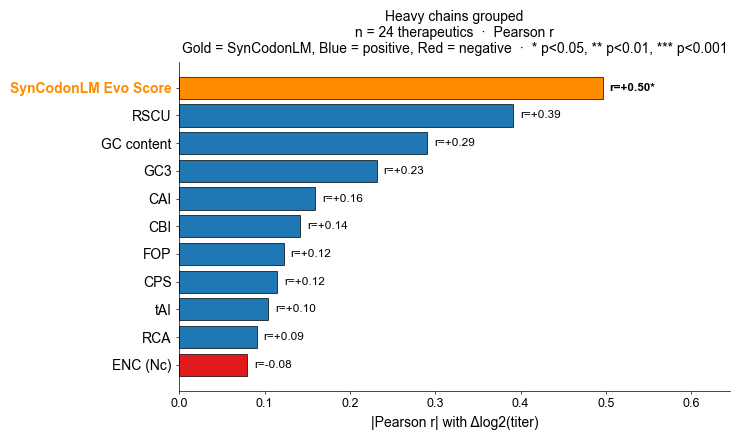

Saved: Figure_FamousMetrics_plus_Evo_PearsonR_Heavy.pdf


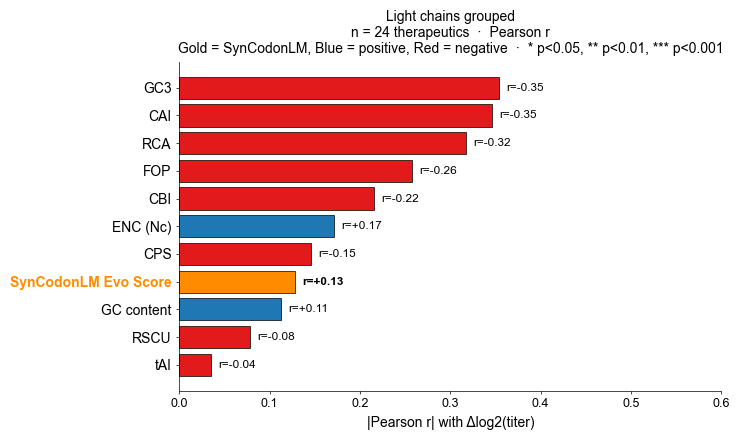

Saved: Figure_FamousMetrics_plus_Evo_PearsonR_Light.pdf


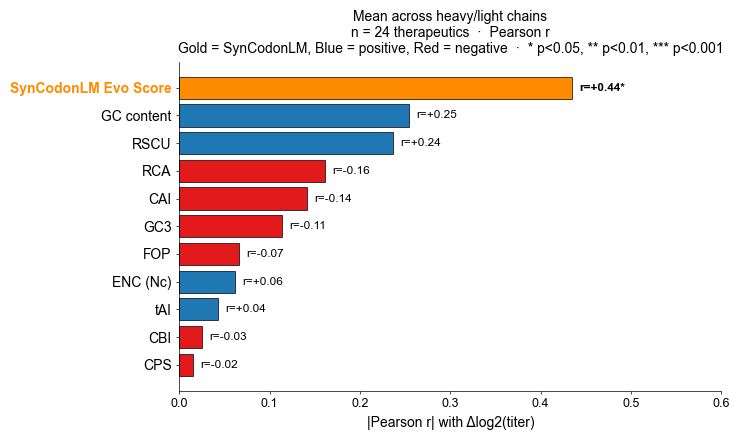

Saved: Figure_FamousMetrics_plus_Evo_PearsonR_Mean.pdf

=== Heavy grouping (Pearson r) ===
Evo score rank: 1 of 11
Evo score r = +0.496, p = 1.36e-02

Full ranking:
 Rank              Display  Pearson r  p_value  n
    1 SynCodonLM Evo Score   0.496318 0.013632 24
    2                 RSCU   0.391397 0.058580 24
    3           GC content   0.290750 0.168101 24
    4                  GC3   0.231359 0.276701 24
    5                  CAI   0.159284 0.457215 24
    6                  CBI   0.141776 0.508721 24
    7                  FOP   0.122192 0.569493 24
    8                  CPS   0.115016 0.592537 24
    9                  tAI   0.104316 0.627614 24
   10                  RCA   0.090892 0.672746 24
   11             ENC (Nc)  -0.079832 0.710780 24

=== Light grouping (Pearson r) ===
Evo score rank: 8 of 11
Evo score r = +0.129, p = 5.49e-01

Full ranking:
 Rank              Display  Pearson r  p_value  n
    1                  GC3  -0.353876 0.097602 23
    2                  CA

In [18]:
# ============================================================
# Δlog2(titer) vs Δ(famous classical metrics) + SynCodonLM evo score
# Curated to ~10 widely recognized codon usage statistics for the
# main figure. Supplemental version uses the full set of 31.
#
# Three separate bar chart figures (one per chain grouping).
# Select correlation statistic at the top.
# ============================================================

CORRELATION_METRIC = "pearson"   # "pearson" | "spearman" | "r2"

# -----------------------------
# Curated famous-metrics list
# -----------------------------
# Column names exactly as they appear in rare_codon_extract.xlsx
FAMOUS_METRICS = [
    "RS_CAI",       # Codon Adaptation Index (Sharp & Li 1987)
    "TRNA_tAI",     # tRNA Adaptation Index (dos Reis 2004)
    "NU_ENC",       # Effective Number of Codons (Wright 1990)
    "RS_FOP",       # Frequency of Optimal Codons (Ikemura 1981)
    "RS_CBI",       # Codon Bias Index (Bennetzen & Hall 1982)
    "NU_RSCU",      # Relative Synonymous Codon Usage (Sharp 1986)
    "CP_GC",        # GC content
    "CP_GC3",       # GC content at 3rd position
    "CP_CPS",       # Codon Pair Score (Coleman et al. 2008)
    "RS_RCA",       # Relative Codon Adaptation
]

# Friendly display names (optional rename for the y-axis)
DISPLAY_NAMES = {
    "RS_CAI":  "CAI",
    "TRNA_tAI": "tAI",
    "NU_ENC":  "ENC (Nc)",
    "RS_FOP":  "FOP",
    "RS_CBI":  "CBI",
    "NU_RSCU": "RSCU",
    "CP_GC":   "GC content",
    "CP_GC3":  "GC3",
    "CP_CPS":  "CPS",
    "RS_RCA":  "RCA",
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import re

# -----------------------------
# Input files
# -----------------------------
TITER_FILE = "master-data.xlsx"
STATS_FILE = "heuristic-statistical-descriptors.xlsx"
SCORE_FILE = "patented+mutated-sequences-with-evo-scores.xlsx"
STATS_SHEET = "All_Data"

# -----------------------------
# Settings
# -----------------------------
ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"
TOO_LOW_AS = np.nan

TITER_PATTERN = r"^Titer\s*mg/L\s*Rep\s*\d+$"

ORIG_SCORE_COL = "Original_DNA_synonym_constrained_mean_logprob"
OPT_SCORE_COL  = "Optimized_DNA_synonym_constrained_mean_logprob"
EVO_METRIC_NAME = "SynCodonLM Evo Score"

# Color scheme
COLOR_POS = "#1f78b4"  # blue, positive
COLOR_NEG = "#e31a1c"  # red, negative
COLOR_EVO = "#ff8c00"  # gold, evo score

# -----------------------------
# Correlation metric config
# -----------------------------
CORRELATION_METRIC = CORRELATION_METRIC.lower()
assert CORRELATION_METRIC in {"pearson", "spearman", "r2"}, \
    "CORRELATION_METRIC must be 'pearson', 'spearman', or 'r2'"

METRIC_INFO = {
    "pearson": {
        "stat_label":   "Pearson r",
        "abs_label":    "|Pearson r|",
        "value_prefix": "r",
        "func":         lambda x, y: pearsonr(x, y),
        "file_suffix":  "PearsonR",
    },
    "spearman": {
        "stat_label":   "Spearman ρ",
        "abs_label":    "|Spearman ρ|",
        "value_prefix": "ρ",
        "func":         lambda x, y: spearmanr(x, y),
        "file_suffix":  "SpearmanRho",
    },
    "r2": {
        "stat_label":   "R²",
        "abs_label":    "R²",
        "value_prefix": "R²",
        "func":         lambda x, y: pearsonr(x, y),
        "file_suffix":  "R2",
    },
}
CFG = METRIC_INFO[CORRELATION_METRIC]

GROUPING_CONFIG = {
    "Heavy": {
        "title": "Heavy chains grouped",
        "outfile": f"Figure_FamousMetrics_plus_Evo_{CFG['file_suffix']}_Heavy.pdf",
    },
    "Light": {
        "title": "Light chains grouped",
        "outfile": f"Figure_FamousMetrics_plus_Evo_{CFG['file_suffix']}_Light.pdf",
    },
    "Mean": {
        "title": "Mean across heavy/light chains",
        "outfile": f"Figure_FamousMetrics_plus_Evo_{CFG['file_suffix']}_Mean.pdf",
    },
}

OUT_TABLE = f"FamousMetrics_plus_Evo_vs_Titer_correlations_{CFG['file_suffix']}.csv"

# -----------------------------
# Helpers
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS, "too low": TOO_LOW_AS, "TOO LOW": TOO_LOW_AS,
            "": np.nan, " ": np.nan, "NA": np.nan, "na": np.nan
        }),
        errors="coerce"
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"):
        return "Heavy"
    if s.startswith("light"):
        return "Light"
    return "Other"

def compute_stat(x, y):
    r, p = CFG["func"](x, y)
    sign = 1 if r >= 0 else -1
    if CORRELATION_METRIC == "r2":
        plot_value = r ** 2
        signed_stat = r ** 2
    else:
        plot_value = abs(r)
        signed_stat = r
    return signed_stat, plot_value, sign, p

# -----------------------------
# 1) Titer log2FC per therapeutic
# -----------------------------
df = pd.read_excel(TITER_FILE, engine="openpyxl")
df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)
df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

titer_cols = sorted(
    [c for c in df.columns if re.match(TITER_PATTERN, str(c).strip(), re.IGNORECASE)],
    key=rep_num
)
for c in titer_cols:
    df[c] = clean_numeric(df[c])

df["Titer_row_mean"] = df[titer_cols].mean(axis=1, skipna=True)

titer_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(Titer_Mean=("Titer_row_mean", "mean"))
      .reset_index()
)
titer_wide = titer_long.pivot(
    index="Base_Molecule", columns="Variant", values="Titer_Mean"
).reset_index()

for v in [PARENT_LABEL, MUT_LABEL]:
    if v not in titer_wide.columns:
        titer_wide[v] = np.nan

pos_vals = titer_wide[[PARENT_LABEL, MUT_LABEL]].values.flatten()
pos_vals = pos_vals[np.isfinite(pos_vals) & (pos_vals > 0)]
eps = 0.01 * np.min(pos_vals) if len(pos_vals) else 1e-6

titer_wide["Titer_log2FC"] = np.log2(
    (titer_wide[MUT_LABEL] + eps) / (titer_wide[PARENT_LABEL] + eps)
)
titer_wide = titer_wide.rename(columns={"Base_Molecule": "Therapeutic"})
titer_wide = titer_wide[["Therapeutic", "Titer_log2FC"]]

# -----------------------------
# 2) Stats file - restrict to famous metrics
# -----------------------------
stats = pd.read_excel(STATS_FILE, sheet_name=STATS_SHEET, engine="openpyxl")
stats["Chain"] = stats["Chain"].astype(str).str.strip()

chain_parsed = stats["Chain"].str.extract(
    r"^(?P<Therapeutic>.+?)\s+(?P<ChainID>(?:Heavy|Light)\s*\d+)\s+(?P<Variant>Patent|Mutated)\s*$",
    flags=re.IGNORECASE
)
stats["Therapeutic"] = chain_parsed["Therapeutic"].str.strip()
stats["ChainID"] = (
    chain_parsed["ChainID"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.title()
)
stats["Variant"] = chain_parsed["Variant"].str.capitalize()
stats["Chain_Group"] = stats["ChainID"].apply(get_chain_group)
stats = stats.dropna(subset=["Therapeutic", "ChainID", "Variant"]).copy()
stats = stats[stats["Chain_Group"].isin(["Heavy", "Light"])].copy()

# Verify all famous metrics are present
missing = [m for m in FAMOUS_METRICS if m not in stats.columns]
if missing:
    print(f"WARNING: missing metrics from stats file: {missing}")
metric_cols = [m for m in FAMOUS_METRICS if m in stats.columns]

for c in metric_cols:
    stats[c] = clean_numeric(stats[c])

# -----------------------------
# 3) Evo score file
# -----------------------------
score_df = pd.read_excel(SCORE_FILE, sheet_name="Scored_Sequences", engine="openpyxl")
score_df["Therapeutic"] = score_df["Therapeutic"].astype(str).str.strip()
score_df["Chain"] = score_df["Chain"].astype(str).str.strip()
score_df["Chain_Group"] = score_df["Chain"].apply(get_chain_group)
for c in [ORIG_SCORE_COL, OPT_SCORE_COL]:
    score_df[c] = pd.to_numeric(score_df[c], errors="coerce")
score_df[EVO_METRIC_NAME] = score_df[OPT_SCORE_COL] - score_df[ORIG_SCORE_COL]
score_df = score_df[score_df["Chain_Group"].isin(["Heavy", "Light"])].copy()

# -----------------------------
# 4) Per-chain Δ for classical metrics
# -----------------------------
per_chain_rows = []
for (ther, cid, cg, var), sub in stats.groupby(
    ["Therapeutic", "ChainID", "Chain_Group", "Variant"]
):
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg, "Variant": var}
    for c in metric_cols:
        rec[c] = sub[c].mean()
    per_chain_rows.append(rec)
per_chain = pd.DataFrame(per_chain_rows)

delta_rows = []
for (ther, cid, cg), sub in per_chain.groupby(["Therapeutic", "ChainID", "Chain_Group"]):
    pat = sub[sub["Variant"] == PARENT_LABEL]
    mut = sub[sub["Variant"] == MUT_LABEL]
    if len(pat) == 0 or len(mut) == 0:
        continue
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg}
    for c in metric_cols:
        rec[c] = mut[c].values[0] - pat[c].values[0]
    delta_rows.append(rec)
chain_delta_df = pd.DataFrame(delta_rows)

def agg_group(group_key):
    if group_key == "Mean":
        sub = chain_delta_df
    else:
        sub = chain_delta_df[chain_delta_df["Chain_Group"] == group_key]
    return sub.groupby("Therapeutic", as_index=False)[metric_cols].mean()

classical_by_group = {g: agg_group(g) for g in ["Heavy", "Light", "Mean"]}

def agg_evo(group_key):
    if group_key == "Mean":
        sub = score_df
    else:
        sub = score_df[score_df["Chain_Group"] == group_key]
    return sub.groupby("Therapeutic", as_index=False)[EVO_METRIC_NAME].mean()

evo_by_group = {g: agg_evo(g) for g in ["Heavy", "Light", "Mean"]}

merged_by_group = {}
for g in ["Heavy", "Light", "Mean"]:
    m = (
        titer_wide
        .merge(classical_by_group[g], on="Therapeutic", how="inner")
        .merge(evo_by_group[g], on="Therapeutic", how="inner")
    )
    merged_by_group[g] = m
    print(f"{g} n: {len(m)}")

all_metric_names = metric_cols + [EVO_METRIC_NAME]

# -----------------------------
# 5) Correlation tables
# -----------------------------
def corr_table(merged, label):
    rows = []
    for c in all_metric_names:
        if c not in merged.columns:
            continue
        d = merged[["Titer_log2FC", c]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(d) < 3 or d[c].nunique() < 2:
            continue
        signed_stat, plot_value, sign, p = compute_stat(d[c].values, d["Titer_log2FC"].values)
        # Use display name if available
        display = DISPLAY_NAMES.get(c, c)
        rows.append({
            "Grouping":     label,
            "Metric":       c,
            "Display":      display,
            "Stat_signed":  signed_stat,
            "Plot_value":   plot_value,
            "Sign":         sign,
            "p_value":      p,
            "n":            len(d),
        })
    return pd.DataFrame(rows)

results_by_group = {g: corr_table(merged_by_group[g], g) for g in ["Heavy", "Light", "Mean"]}

all_res = pd.concat(results_by_group.values(), ignore_index=True)
all_res = all_res.rename(columns={
    "Stat_signed": f"{CFG['stat_label']} (signed)",
    "Plot_value":  CFG["abs_label"],
})
all_res.to_csv(OUT_TABLE, index=False)
print(f"\nSaved: {OUT_TABLE}")

# -----------------------------
# 6) One standalone bar chart per grouping
# -----------------------------
def fmt_value(signed_stat):
    prefix = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        return f"{prefix}={signed_stat:.2f}"
    else:
        return f"{prefix}={signed_stat:+.2f}"

def plot_grouping(res_df, merged_df, title, outfile):
    d = res_df.copy()
    d = d.sort_values("Plot_value", ascending=True)  # biggest at top

    n_used = len(merged_df)
    evo_display = DISPLAY_NAMES.get(EVO_METRIC_NAME, EVO_METRIC_NAME)

    fig, ax = plt.subplots(figsize=(7.5, 4.5))

    colors = []
    for metric, sign in zip(d["Metric"], d["Sign"]):
        if metric == EVO_METRIC_NAME:
            colors.append(COLOR_EVO)
        elif sign < 0:
            colors.append(COLOR_NEG)
        else:
            colors.append(COLOR_POS)

    ax.barh(
        d["Display"], d["Plot_value"],
        color=colors, edgecolor="black", linewidth=0.5
    )

    # Bold evo score label
    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() == evo_display:
            tick_label.set_fontweight("bold")
            tick_label.set_color(COLOR_EVO)

    # Bar annotations
    for y, (metric, signed_stat, pv, p) in enumerate(zip(
        d["Metric"], d["Stat_signed"], d["Plot_value"], d["p_value"]
    )):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        weight = "bold" if metric == EVO_METRIC_NAME else "normal"
        ax.text(
            pv + 0.008, y, f"{fmt_value(signed_stat)}{sig}",
            va="center", fontsize=8.5, fontweight=weight
        )

    ax.set_xlabel(f"{CFG['abs_label']} with Δlog2(titer)", fontsize=10)
    if CORRELATION_METRIC == "r2":
        legend_line = "Gold = SynCodonLM, Blue = positive r, Red = negative r"
    else:
        legend_line = "Gold = SynCodonLM, Blue = positive, Red = negative"

    ax.set_title(
        f"{title}\n"
        f"n = {n_used} therapeutics  ·  {CFG['stat_label']}\n"
        f"{legend_line}  ·  * p<0.05, ** p<0.01, *** p<0.001",
        fontsize=10
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, max(0.6, d["Plot_value"].max() * 1.30))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=9)

    plt.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outfile}")

for key, cfg in GROUPING_CONFIG.items():
    plot_grouping(
        res_df=results_by_group[key],
        merged_df=merged_by_group[key],
        title=cfg["title"],
        outfile=cfg["outfile"]
    )

# -----------------------------
# 7) Console preview: ranking + evo position
# -----------------------------
for label, res in results_by_group.items():
    ranked = (
        res.sort_values("Plot_value", ascending=False).reset_index(drop=True)
    )
    ranked["Rank"] = ranked.index + 1

    evo_row = ranked[ranked["Metric"] == EVO_METRIC_NAME]
    if len(evo_row) == 0:
        print(f"\n=== {label} grouping ({CFG['stat_label']}) ===  (no evo score row)")
        continue

    evo_rank   = int(evo_row["Rank"].values[0])
    evo_stat   = float(evo_row["Stat_signed"].values[0])
    evo_p      = float(evo_row["p_value"].values[0])
    total      = len(ranked)

    print(f"\n=== {label} grouping ({CFG['stat_label']}) ===")
    print(f"Evo score rank: {evo_rank} of {total}")
    print(
        f"Evo score {CFG['value_prefix']} = {evo_stat:+.3f}, "
        f"p = {evo_p:.2e}"
    )

    print("\nFull ranking:")
    preview = ranked[["Rank", "Display", "Stat_signed", "p_value", "n"]].rename(
        columns={"Stat_signed": CFG["stat_label"]}
    )
    print(preview.to_string(index=False))

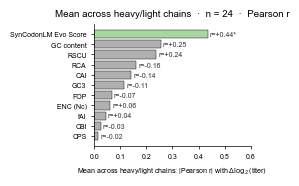

Saved: Figure_FamousMetrics_plus_Evo_PearsonR_Mean.svg


In [19]:
# ============================================================
# Mean across heavy/light chains — famous codon metrics + Evo
# Nature-submission SVG styling to match the waterfall figure.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# SVG / figure styling (matches waterfall)
# -----------------------------
MM_TO_INCH = 1 / 25.4

FIG_WIDTH_MM  = 70
FIG_HEIGHT_MM = 50

FONT_NAME       = "Arial"
TITLE_FONTSIZE  = 7
AXIS_FONTSIZE   = 5
TICK_FONTSIZE   = 5
TEXT_FONTSIZE   = 5

# Colors — classical metrics neutral gray, SynCodonLM pastel green
COLOR_CLASSICAL = "#b0b0b0"   # neutral gray
COLOR_EVO       = "#a8d5a2"   # pastel green

# Keep SVG text editable
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"]  = FONT_NAME
plt.rcParams["pdf.fonttype"] = 42

OUT_FIG = f"Figure_FamousMetrics_plus_Evo_{CFG['file_suffix']}_Mean.svg"

# -----------------------------
# Data
# -----------------------------
res_df    = results_by_group["Mean"].copy()
merged_df = merged_by_group["Mean"]
n_used    = len(merged_df)
evo_display = DISPLAY_NAMES.get(EVO_METRIC_NAME, EVO_METRIC_NAME)

d = res_df.sort_values("Plot_value", ascending=True).reset_index(drop=True)

# -----------------------------
# Formatting helpers
# -----------------------------
def fmt_value(signed_stat):
    prefix = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        return f"{prefix}={signed_stat:.2f}"
    return f"{prefix}={signed_stat:+.2f}"

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# -----------------------------
# Figure
# -----------------------------
FIGSIZE = (FIG_WIDTH_MM * MM_TO_INCH, FIG_HEIGHT_MM * MM_TO_INCH)
fig, ax = plt.subplots(figsize=FIGSIZE)

colors = [
    COLOR_EVO if metric == EVO_METRIC_NAME else COLOR_CLASSICAL
    for metric in d["Metric"]
]

ax.barh(
    d["Display"], d["Plot_value"],
    color=colors, edgecolor="black", linewidth=0.3,
)

# Bar annotations — uniform styling for all bars
for y, (signed_stat, pv, p) in enumerate(zip(
    d["Stat_signed"], d["Plot_value"], d["p_value"]
)):
    ax.text(
        pv + 0.008, y,
        f"{fmt_value(signed_stat)}{sig_stars(p)}",
        va="center",
        fontsize=TEXT_FONTSIZE,
        fontname=FONT_NAME,
        color="#333333",
    )

# Labels / title
ax.set_xlabel(
    f"Mean across heavy/light chains: {CFG['abs_label']} with $\\Delta\\log_{{2}}$(titer)",
    fontsize=AXIS_FONTSIZE,
    fontname=FONT_NAME,
)
ax.set_title(
    f"Mean across heavy/light chains  ·  n = {n_used}  ·  {CFG['stat_label']}",
    fontsize=TITLE_FONTSIZE,
    fontname=FONT_NAME,
)

# Spines & ticks (waterfall style)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.tick_params(
    axis="both", which="major",
    labelsize=TICK_FONTSIZE, width=0.5, length=2,
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname(FONT_NAME)
    label.set_fontsize(TICK_FONTSIZE)

ax.set_xlim(0, max(0.6, d["Plot_value"].max() * 1.35))

plt.tight_layout()
fig.savefig(OUT_FIG, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_FIG}")

Heavy n: 24
Light n: 24
Mean n: 24

Running bootstrap with 5000 resamples per metric...
  Heavy...
  Light...
  Mean...

Saved: FamousMetrics_plus_Evo_vs_Titer_correlations_PearsonR_withCI.csv


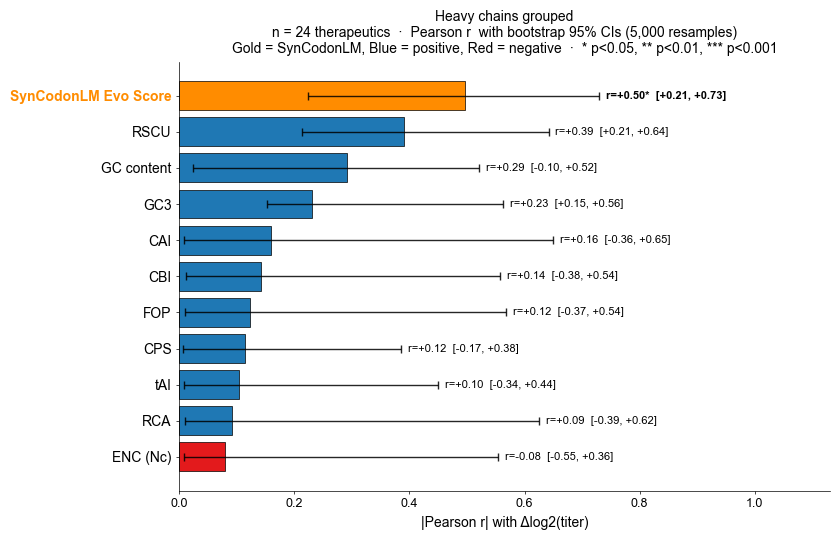

Saved: Figure_FamousMetrics_plus_Evo_PearsonR_withCI_Heavy.pdf


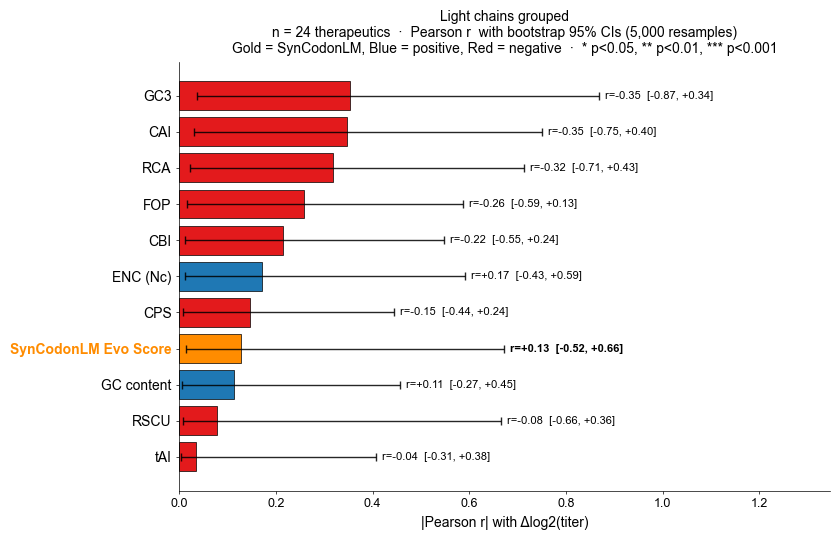

Saved: Figure_FamousMetrics_plus_Evo_PearsonR_withCI_Light.pdf


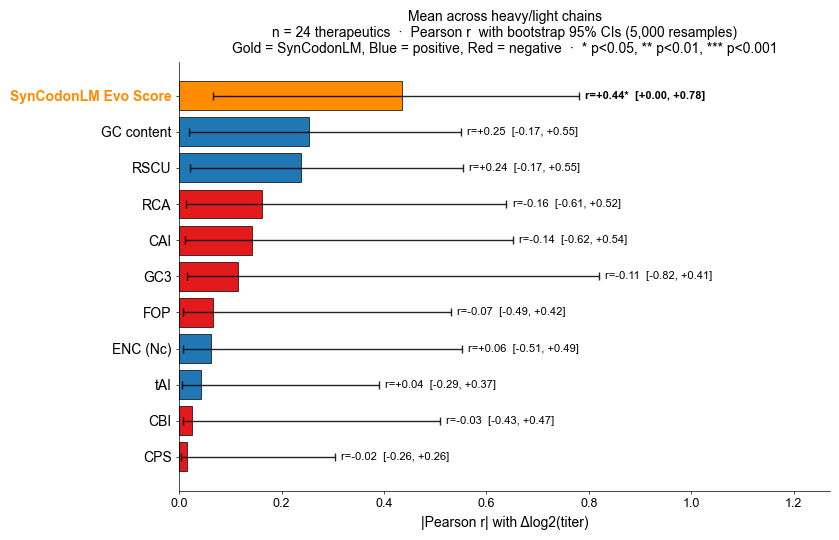

Saved: Figure_FamousMetrics_plus_Evo_PearsonR_withCI_Mean.pdf

=== Heavy grouping (Pearson r) ===
 Rank              Display  Pearson r    CI_low  CI_high  p_value  CI_excludes_zero  n
    1 SynCodonLM Evo Score   0.496318  0.211634 0.729007 0.013632              True 24
    2                 RSCU   0.391397  0.207073 0.641790 0.058580              True 24
    3           GC content   0.290750 -0.103817 0.520692 0.168101             False 24
    4                  GC3   0.231359  0.150999 0.562574 0.276701              True 24
    5                  CAI   0.159284 -0.359959 0.646615 0.457215             False 24
    6                  CBI   0.141776 -0.378967 0.542673 0.508721             False 24
    7                  FOP   0.122192 -0.373130 0.541181 0.569493             False 24
    8                  CPS   0.115016 -0.170337 0.382160 0.592537             False 24
    9                  tAI   0.104316 -0.340244 0.440939 0.627614             False 24
   10                  RCA   0.0

In [20]:
# ============================================================
# Δlog2(titer) vs Δ(famous classical metrics) + SynCodonLM evo score
# WITH BOOTSTRAP 95% CONFIDENCE INTERVALS as error bars
#
# Three separate figures (Heavy / Light / Mean).
# Select correlation statistic at the top.
# ============================================================

CORRELATION_METRIC = "pearson"   # "pearson" | "spearman" | "r2"
N_BOOTSTRAP = 5000                # bootstrap resamples
RNG_SEED = 9

# -----------------------------
# Curated famous-metrics list
# -----------------------------
FAMOUS_METRICS = [
    "RS_CAI",       # Codon Adaptation Index
    "TRNA_tAI",     # tRNA Adaptation Index
    "NU_ENC",       # Effective Number of Codons
    "RS_FOP",       # Frequency of Optimal Codons
    "RS_CBI",       # Codon Bias Index
    "NU_RSCU",      # Relative Synonymous Codon Usage
    "CP_GC",        # GC content
    "CP_GC3",       # GC content at 3rd position
    "CP_CPS",       # Codon Pair Score
    "RS_RCA",       # Relative Codon Adaptation
]

DISPLAY_NAMES = {
    "RS_CAI":  "CAI",
    "TRNA_tAI": "tAI",
    "NU_ENC":  "ENC (Nc)",
    "RS_FOP":  "FOP",
    "RS_CBI":  "CBI",
    "NU_RSCU": "RSCU",
    "CP_GC":   "GC content",
    "CP_GC3":  "GC3",
    "CP_CPS":  "CPS",
    "RS_RCA":  "RCA",
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import re

# -----------------------------
# Input files
# -----------------------------
TITER_FILE = "master-data.xlsx"
STATS_FILE = "heuristic-statistical-descriptors.xlsx"
SCORE_FILE = "patented+mutated-sequences-with-evo-scores.xlsx"
STATS_SHEET = "All_Data"

# -----------------------------
# Settings
# -----------------------------
ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"
TOO_LOW_AS = np.nan

TITER_PATTERN = r"^Titer\s*mg/L\s*Rep\s*\d+$"

ORIG_SCORE_COL = "Original_DNA_synonym_constrained_mean_logprob"
OPT_SCORE_COL  = "Optimized_DNA_synonym_constrained_mean_logprob"
EVO_METRIC_NAME = "SynCodonLM Evo Score"

COLOR_POS = "#1f78b4"
COLOR_NEG = "#e31a1c"
COLOR_EVO = "#ff8c00"

# -----------------------------
# Correlation metric config
# -----------------------------
CORRELATION_METRIC = CORRELATION_METRIC.lower()
assert CORRELATION_METRIC in {"pearson", "spearman", "r2"}

METRIC_INFO = {
    "pearson": {
        "stat_label":   "Pearson r",
        "abs_label":    "|Pearson r|",
        "value_prefix": "r",
        "func":         lambda x, y: pearsonr(x, y)[0],
        "p_func":       lambda x, y: pearsonr(x, y)[1],
        "file_suffix":  "PearsonR_withCI",
    },
    "spearman": {
        "stat_label":   "Spearman ρ",
        "abs_label":    "|Spearman ρ|",
        "value_prefix": "ρ",
        "func":         lambda x, y: spearmanr(x, y)[0],
        "p_func":       lambda x, y: spearmanr(x, y)[1],
        "file_suffix":  "SpearmanRho_withCI",
    },
    "r2": {
        "stat_label":   "R²",
        "abs_label":    "R²",
        "value_prefix": "R²",
        "func":         lambda x, y: pearsonr(x, y)[0],
        "p_func":       lambda x, y: pearsonr(x, y)[1],
        "file_suffix":  "R2_withCI",
    },
}
CFG = METRIC_INFO[CORRELATION_METRIC]

GROUPING_CONFIG = {
    "Heavy": {
        "title": "Heavy chains grouped",
        "outfile": f"Figure_FamousMetrics_plus_Evo_{CFG['file_suffix']}_Heavy.pdf",
    },
    "Light": {
        "title": "Light chains grouped",
        "outfile": f"Figure_FamousMetrics_plus_Evo_{CFG['file_suffix']}_Light.pdf",
    },
    "Mean": {
        "title": "Mean across heavy/light chains",
        "outfile": f"Figure_FamousMetrics_plus_Evo_{CFG['file_suffix']}_Mean.pdf",
    },
}

OUT_TABLE = f"FamousMetrics_plus_Evo_vs_Titer_correlations_{CFG['file_suffix']}.csv"

# -----------------------------
# Helpers
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS, "too low": TOO_LOW_AS, "TOO LOW": TOO_LOW_AS,
            "": np.nan, " ": np.nan, "NA": np.nan, "na": np.nan
        }),
        errors="coerce"
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"):
        return "Heavy"
    if s.startswith("light"):
        return "Light"
    return "Other"

def stat_from_r(r):
    """Transform raw Pearson/Spearman r into the chosen plotted statistic."""
    if CORRELATION_METRIC == "r2":
        return r ** 2
    return r  # signed for pearson/spearman


def compute_point_estimate(x, y):
    r = CFG["func"](x, y)
    p = CFG["p_func"](x, y)
    signed_stat = stat_from_r(r)
    plot_value = abs(signed_stat) if CORRELATION_METRIC != "r2" else signed_stat
    sign = 1 if r >= 0 else -1
    return signed_stat, plot_value, sign, p, r
    

def bootstrap_ci(x, y, n_boot=N_BOOTSTRAP, seed=RNG_SEED, alpha=0.05):
    rng = np.random.default_rng(seed)
    n = len(x)
    if n < 4:
        return (np.nan,) * 4

    x = np.asarray(x); y = np.asarray(y)
    boot_signed = np.empty(n_boot)
    boot_plot   = np.empty(n_boot)

    valid = 0
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb, yb = x[idx], y[idx]
        if np.unique(xb).size < 2 or np.unique(yb).size < 2:
            boot_signed[i] = np.nan
            boot_plot[i]   = np.nan
            continue
        try:
            rb = CFG["func"](xb, yb)
        except Exception:
            boot_signed[i] = np.nan
            boot_plot[i]   = np.nan
            continue
        sb = stat_from_r(rb)
        boot_signed[i] = sb
        boot_plot[i]   = abs(sb) if CORRELATION_METRIC != "r2" else sb
        valid += 1

    if valid < 100:
        return (np.nan,) * 4

    lo, hi = 100 * alpha / 2, 100 * (1 - alpha / 2)
    return (
        np.nanpercentile(boot_signed, lo),
        np.nanpercentile(boot_signed, hi),
        np.nanpercentile(boot_plot, lo),
        np.nanpercentile(boot_plot, hi),
    )

# -----------------------------
# 1) Titer log2FC per therapeutic
# -----------------------------
df = pd.read_excel(TITER_FILE, engine="openpyxl")
df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)
df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

titer_cols = sorted(
    [c for c in df.columns if re.match(TITER_PATTERN, str(c).strip(), re.IGNORECASE)],
    key=rep_num
)
for c in titer_cols:
    df[c] = clean_numeric(df[c])
df["Titer_row_mean"] = df[titer_cols].mean(axis=1, skipna=True)

titer_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(Titer_Mean=("Titer_row_mean", "mean"))
      .reset_index()
)
titer_wide = titer_long.pivot(
    index="Base_Molecule", columns="Variant", values="Titer_Mean"
).reset_index()
for v in [PARENT_LABEL, MUT_LABEL]:
    if v not in titer_wide.columns:
        titer_wide[v] = np.nan
pos_vals = titer_wide[[PARENT_LABEL, MUT_LABEL]].values.flatten()
pos_vals = pos_vals[np.isfinite(pos_vals) & (pos_vals > 0)]
eps = 0.01 * np.min(pos_vals) if len(pos_vals) else 1e-6
titer_wide["Titer_log2FC"] = np.log2(
    (titer_wide[MUT_LABEL] + eps) / (titer_wide[PARENT_LABEL] + eps)
)
titer_wide = titer_wide.rename(columns={"Base_Molecule": "Therapeutic"})
titer_wide = titer_wide[["Therapeutic", "Titer_log2FC"]]

# -----------------------------
# 2) Stats file - restrict to famous metrics
# -----------------------------
stats = pd.read_excel(STATS_FILE, sheet_name=STATS_SHEET, engine="openpyxl")
stats["Chain"] = stats["Chain"].astype(str).str.strip()

chain_parsed = stats["Chain"].str.extract(
    r"^(?P<Therapeutic>.+?)\s+(?P<ChainID>(?:Heavy|Light)\s*\d+)\s+(?P<Variant>Patent|Mutated)\s*$",
    flags=re.IGNORECASE
)
stats["Therapeutic"] = chain_parsed["Therapeutic"].str.strip()
stats["ChainID"] = (
    chain_parsed["ChainID"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.title()
)
stats["Variant"] = chain_parsed["Variant"].str.capitalize()
stats["Chain_Group"] = stats["ChainID"].apply(get_chain_group)
stats = stats.dropna(subset=["Therapeutic", "ChainID", "Variant"]).copy()
stats = stats[stats["Chain_Group"].isin(["Heavy", "Light"])].copy()

missing = [m for m in FAMOUS_METRICS if m not in stats.columns]
if missing:
    print(f"WARNING: missing metrics from stats file: {missing}")
metric_cols = [m for m in FAMOUS_METRICS if m in stats.columns]
for c in metric_cols:
    stats[c] = clean_numeric(stats[c])

# -----------------------------
# 3) Evo score file
# -----------------------------
score_df = pd.read_excel(SCORE_FILE, sheet_name="Scored_Sequences", engine="openpyxl")
score_df["Therapeutic"] = score_df["Therapeutic"].astype(str).str.strip()
score_df["Chain"] = score_df["Chain"].astype(str).str.strip()
score_df["Chain_Group"] = score_df["Chain"].apply(get_chain_group)
for c in [ORIG_SCORE_COL, OPT_SCORE_COL]:
    score_df[c] = pd.to_numeric(score_df[c], errors="coerce")
score_df[EVO_METRIC_NAME] = score_df[OPT_SCORE_COL] - score_df[ORIG_SCORE_COL]
score_df = score_df[score_df["Chain_Group"].isin(["Heavy", "Light"])].copy()

# -----------------------------
# 4) Per-chain Δ for classical metrics
# -----------------------------
per_chain_rows = []
for (ther, cid, cg, var), sub in stats.groupby(
    ["Therapeutic", "ChainID", "Chain_Group", "Variant"]
):
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg, "Variant": var}
    for c in metric_cols:
        rec[c] = sub[c].mean()
    per_chain_rows.append(rec)
per_chain = pd.DataFrame(per_chain_rows)

delta_rows = []
for (ther, cid, cg), sub in per_chain.groupby(["Therapeutic", "ChainID", "Chain_Group"]):
    pat = sub[sub["Variant"] == PARENT_LABEL]
    mut = sub[sub["Variant"] == MUT_LABEL]
    if len(pat) == 0 or len(mut) == 0:
        continue
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg}
    for c in metric_cols:
        rec[c] = mut[c].values[0] - pat[c].values[0]
    delta_rows.append(rec)
chain_delta_df = pd.DataFrame(delta_rows)

def agg_group(group_key):
    if group_key == "Mean":
        sub = chain_delta_df
    else:
        sub = chain_delta_df[chain_delta_df["Chain_Group"] == group_key]
    return sub.groupby("Therapeutic", as_index=False)[metric_cols].mean()

classical_by_group = {g: agg_group(g) for g in ["Heavy", "Light", "Mean"]}

def agg_evo(group_key):
    if group_key == "Mean":
        sub = score_df
    else:
        sub = score_df[score_df["Chain_Group"] == group_key]
    return sub.groupby("Therapeutic", as_index=False)[EVO_METRIC_NAME].mean()

evo_by_group = {g: agg_evo(g) for g in ["Heavy", "Light", "Mean"]}

merged_by_group = {}
for g in ["Heavy", "Light", "Mean"]:
    m = (
        titer_wide
        .merge(classical_by_group[g], on="Therapeutic", how="inner")
        .merge(evo_by_group[g], on="Therapeutic", how="inner")
    )
    merged_by_group[g] = m
    print(f"{g} n: {len(m)}")

all_metric_names = metric_cols + [EVO_METRIC_NAME]

# -----------------------------
# 5) Correlation tables WITH bootstrap CIs
# -----------------------------
print(f"\nRunning bootstrap with {N_BOOTSTRAP} resamples per metric...")

def corr_table_with_ci(merged, label):
    rows = []
    for c in all_metric_names:
        if c not in merged.columns:
            continue
        d = merged[["Titer_log2FC", c]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(d) < 4 or d[c].nunique() < 2:
            continue
        x = d[c].values
        y = d["Titer_log2FC"].values

        signed_stat, plot_value, sign, p, r_raw = compute_point_estimate(x, y)
        lo_s, hi_s, lo_p, hi_p = bootstrap_ci(x, y)

        display = DISPLAY_NAMES.get(c, c)
        rows.append({
            "Grouping":          label,
            "Metric":            c,
            "Display":           display,
            "Stat_signed":       signed_stat,
            "Plot_value":        plot_value,
            "CI_low_signed":     lo_s,
            "CI_high_signed":    hi_s,
            "CI_low_plot":       lo_p,
            "CI_high_plot":      hi_p,
            "Sign":              sign,
            "p_value":           p,
            "n":                 len(d),
            "CI_excludes_zero":  (lo_s > 0) or (hi_s < 0)
                                 if CORRELATION_METRIC != "r2"
                                 else lo_s > 0,
        })
    return pd.DataFrame(rows)

results_by_group = {}
for g in ["Heavy", "Light", "Mean"]:
    print(f"  {g}...")
    results_by_group[g] = corr_table_with_ci(merged_by_group[g], g)

all_res = pd.concat(results_by_group.values(), ignore_index=True)
all_res.to_csv(OUT_TABLE, index=False)
print(f"\nSaved: {OUT_TABLE}")

# -----------------------------
# 6) One standalone bar chart per grouping with error bars
# -----------------------------
def fmt_value(signed_stat):
    prefix = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        return f"{prefix}={signed_stat:.2f}"
    return f"{prefix}={signed_stat:+.2f}"

def fmt_ci(lo, hi):
    if CORRELATION_METRIC == "r2":
        return f"[{lo:.2f}, {hi:.2f}]"
    return f"[{lo:+.2f}, {hi:+.2f}]"

def plot_grouping(res_df, merged_df, title, outfile):
    d = res_df.copy()
    d = d.sort_values("Plot_value", ascending=True)
    n_used = len(merged_df)
    evo_display = DISPLAY_NAMES.get(EVO_METRIC_NAME, EVO_METRIC_NAME)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    colors = []
    for metric, sign in zip(d["Metric"], d["Sign"]):
        if metric == EVO_METRIC_NAME:
            colors.append(COLOR_EVO)
        elif sign < 0:
            colors.append(COLOR_NEG)
        else:
            colors.append(COLOR_POS)

    # Error bars: distance from bar end to CI bounds on the plotted scale
    plot_vals = d["Plot_value"].values
    lo_plot   = d["CI_low_plot"].values
    hi_plot   = d["CI_high_plot"].values

    # Asymmetric errors: clip so we never go below 0
    err_low  = np.clip(plot_vals - np.nan_to_num(lo_plot, nan=0), 0, None)
    err_high = np.clip(np.nan_to_num(hi_plot, nan=plot_vals) - plot_vals, 0, None)

    bars = ax.barh(
        d["Display"], plot_vals,
        color=colors, edgecolor="black", linewidth=0.5,
        xerr=[err_low, err_high],
        error_kw=dict(ecolor="black", lw=1.0, capsize=3, alpha=0.85)
    )

    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() == evo_display:
            tick_label.set_fontweight("bold")
            tick_label.set_color(COLOR_EVO)

    # Annotations: point estimate + significance + CI
    for y, (metric, signed_stat, pv, hi, lo_s, hi_s, p, excl) in enumerate(zip(
        d["Metric"], d["Stat_signed"], d["Plot_value"],
        d["CI_high_plot"], d["CI_low_signed"], d["CI_high_signed"],
        d["p_value"], d["CI_excludes_zero"]
    )):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        weight = "bold" if metric == EVO_METRIC_NAME else "normal"
        label = f"{fmt_value(signed_stat)}{sig}  {fmt_ci(lo_s, hi_s)}"
        ax.text(
            (hi if np.isfinite(hi) else pv) + 0.012, y, label,
            va="center", fontsize=8, fontweight=weight
        )

    ax.set_xlabel(f"{CFG['abs_label']} with Δlog2(titer)", fontsize=10)
    if CORRELATION_METRIC == "r2":
        legend_line = "Gold = SynCodonLM, Blue = positive r, Red = negative r"
    else:
        legend_line = "Gold = SynCodonLM, Blue = positive, Red = negative"

    ax.set_title(
        f"{title}\n"
        f"n = {n_used} therapeutics  ·  {CFG['stat_label']}  "
        f"with bootstrap 95% CIs ({N_BOOTSTRAP:,} resamples)\n"
        f"{legend_line}  ·  * p<0.05, ** p<0.01, *** p<0.001",
        fontsize=10
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Expand x-axis to accommodate CI text labels
    max_extent = np.nanmax(np.nan_to_num(hi_plot, nan=plot_vals))
    ax.set_xlim(0, max(0.85, max_extent * 1.55))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=9)

    plt.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outfile}")

for key, cfg in GROUPING_CONFIG.items():
    plot_grouping(
        res_df=results_by_group[key],
        merged_df=merged_by_group[key],
        title=cfg["title"],
        outfile=cfg["outfile"]
    )

# -----------------------------
# 7) Console preview: ranking + CIs
# -----------------------------
for label, res in results_by_group.items():
    ranked = res.sort_values("Plot_value", ascending=False).reset_index(drop=True)
    ranked["Rank"] = ranked.index + 1

    print(f"\n=== {label} grouping ({CFG['stat_label']}) ===")
    preview = ranked[[
        "Rank", "Display", "Stat_signed",
        "CI_low_signed", "CI_high_signed",
        "p_value", "CI_excludes_zero", "n"
    ]].rename(columns={
        "Stat_signed":     CFG["stat_label"],
        "CI_low_signed":   "CI_low",
        "CI_high_signed":  "CI_high",
    })
    print(preview.to_string(index=False))

    # Highlight evo result
    evo_row = ranked[ranked["Metric"] == EVO_METRIC_NAME]
    if len(evo_row):
        s    = float(evo_row["Stat_signed"].values[0])
        lo   = float(evo_row["CI_low_signed"].values[0])
        hi   = float(evo_row["CI_high_signed"].values[0])
        p    = float(evo_row["p_value"].values[0])
        rank = int(evo_row["Rank"].values[0])
        print(
            f"\nEvo score → rank {rank}/{len(ranked)}: "
            f"{CFG['value_prefix']} = {s:+.3f}  "
            f"95% CI {fmt_ci(lo, hi)}  p = {p:.2e}"
        )

Merged paired table: 103 rows
Plotting 36 metrics


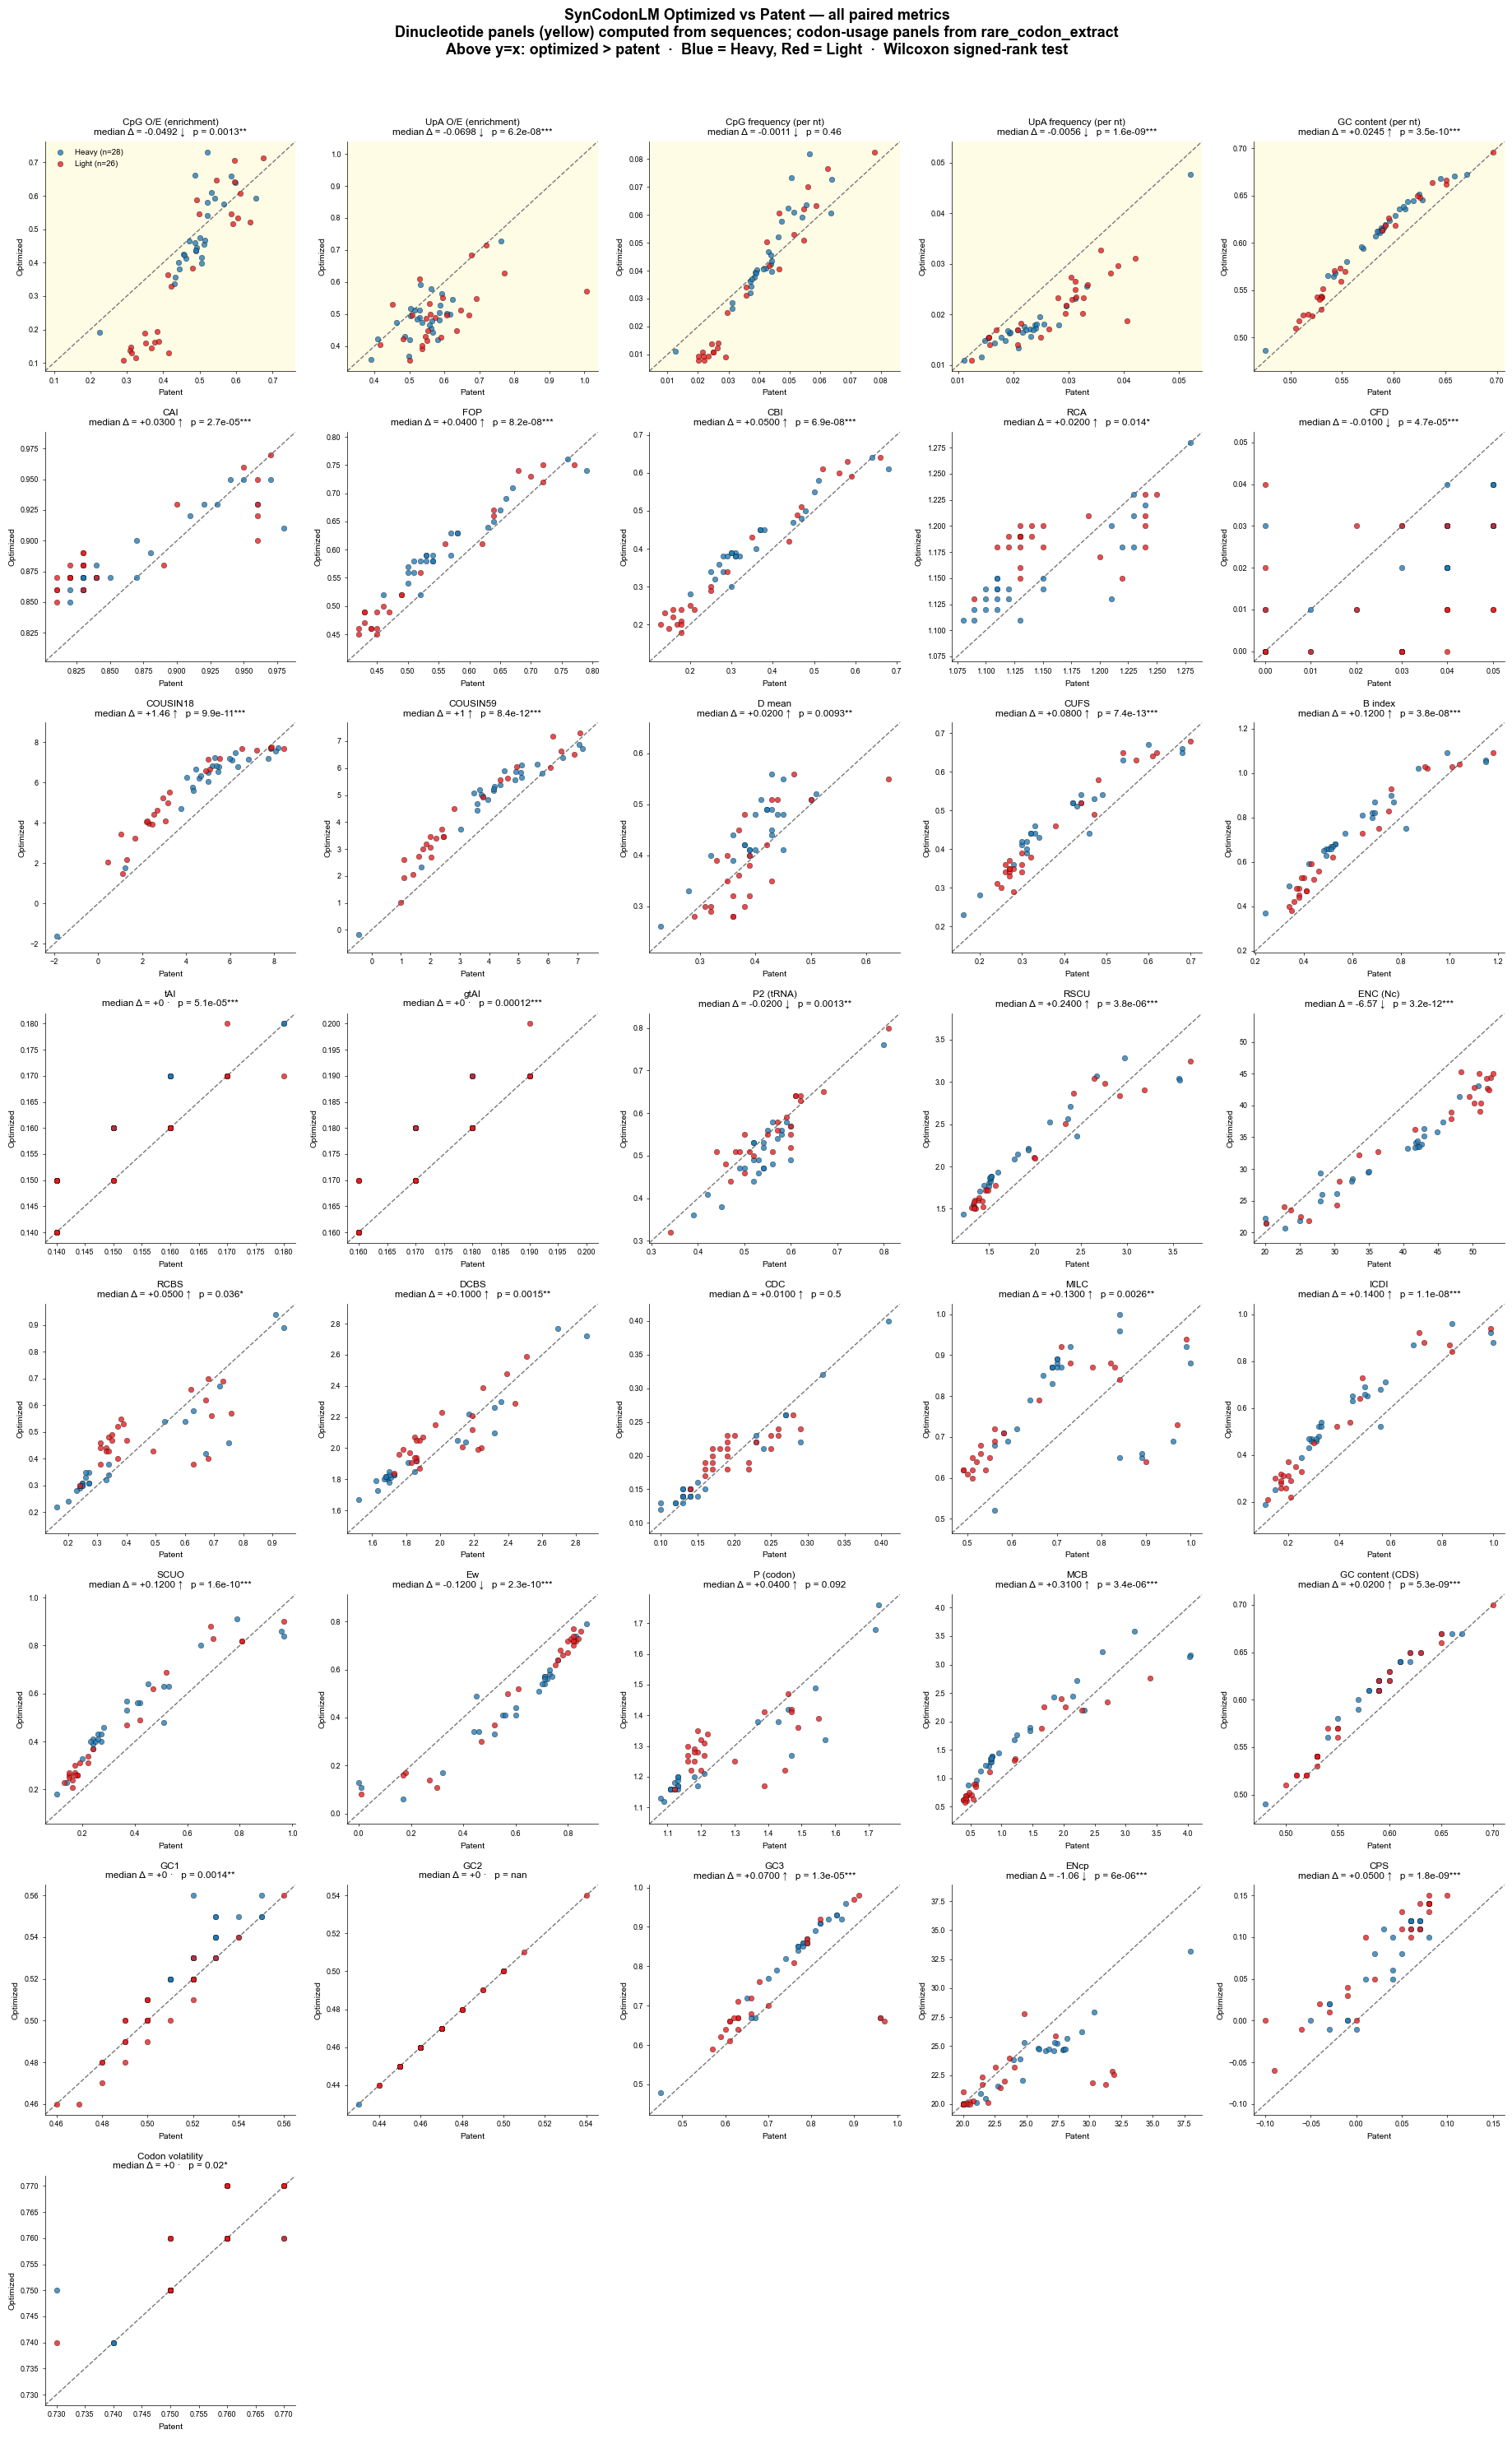

Saved: Figure_AllMetrics_Patent_vs_Optimized_paired.pdf
Saved: AllMetrics_Patent_vs_Optimized_summary.csv

=== All-chain paired test, ranked by significance ===

                Metric  n  median_Patent  median_Optimized  median_Delta      p_value sig
                  CUFS 49       0.320000          0.440000      0.080000 7.354117e-13 ***
              ENC (Nc) 49      41.710000         33.540000     -6.570000 3.211653e-12 ***
              COUSIN59 49       3.790000          5.070000      1.000000 8.437695e-12 ***
              COUSIN18 49       4.900000          6.520000      1.460000 9.920953e-11 ***
                  SCUO 49       0.260000          0.410000      0.120000 1.611902e-10 ***
                    Ew 49       0.710000          0.560000     -0.120000 2.293064e-10 ***
   GC content (per nt) 54       0.587217          0.613038      0.024508 3.501668e-10 ***
UpA frequency (per nt) 54       0.023970          0.017425     -0.005610 1.629810e-09 ***
                   CPS 49   

In [21]:
# ============================================================
# Patent vs Optimized — UNIFIED paired scatter figure
# Combines:
#   * CpG / UpA / GC metrics computed from sequences in
#     TrueOptimizedSequences_scored.xlsx
#   * All rare-codon / CAI / tAI / GC / CPS metrics from
#     rare_codon_extract.xlsx (All_Data sheet)
# Each panel: Optimized (y) vs Patent (x), y=x diagonal,
# Heavy = blue, Light = red, Wilcoxon signed-rank test.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import re

# -----------------------------
# Inputs
# -----------------------------
SEQ_FILE    = "patented+mutated-sequences-with-evo-scores.xlsx"
SEQ_SHEET   = "Scored_Sequences"
STATS_FILE  = "heuristic-statistical-descriptors.xlsx"
STATS_SHEET = "All_Data"

OUT_FIG = "Figure_AllMetrics_Patent_vs_Optimized_paired.pdf"
OUT_CSV = "AllMetrics_Patent_vs_Optimized_summary.csv"

# Sequence columns used for dinucleotide analysis
PAT_SEQ_COL = "Original_DNA"
OPT_SEQ_COL = "Optimized_DNA"

# Colors
COLOR_HEAVY = "#1f78b4"
COLOR_LIGHT = "#e31a1c"
COLOR_DIAG  = "#777777"

# -----------------------------
# Display names + plot order
# -----------------------------
DISPLAY_NAMES = {
    # Dinucleotide / composition (from sequence)
    "Seq_CpG_OE":   "CpG O/E (enrichment)",
    "Seq_UpA_OE":   "UpA O/E (enrichment)",
    "Seq_CpG_freq": "CpG frequency (per nt)",
    "Seq_UpA_freq": "UpA frequency (per nt)",
    "Seq_GC":       "GC content (per nt)",

    # Reference-set indices (rare_codon_extract)
    "RS_CAI":      "CAI",
    "RS_FOP":      "FOP",
    "RS_CBI":      "CBI",
    "RS_RCA":      "RCA",
    "RS_CFD":      "CFD",
    "RS_COUSIN18": "COUSIN18",
    "RS_COUSIN59": "COUSIN59",
    "RS_Dmean":    "D mean",
    "RS_CUFS":     "CUFS",
    "RS_B":        "B index",

    # tRNA-based
    "TRNA_tAI":  "tAI",
    "TRNA_gtAI": "gtAI",
    "TRNA_P2":   "P2 (tRNA)",

    # Codon usage / bias / diversity
    "NU_RSCU": "RSCU",
    "NU_ENC":  "ENC (Nc)",
    "NU_RCBS": "RCBS",
    "NU_DCBS": "DCBS",
    "NU_CDC":  "CDC",
    "NU_MILC": "MILC",
    "NU_ICDI": "ICDI",
    "NU_SCUO": "SCUO",
    "NU_Ew":   "Ew",
    "NU_P":    "P (codon)",
    "NU_MCB":  "MCB",

    # Composition / codon-pair
    "CP_GC":              "GC content (CDS)",
    "CP_GC1":             "GC1",
    "CP_GC2":             "GC2",
    "CP_GC3":             "GC3",
    "CP_ENcp":            "ENcp",
    "CP_CPS":             "CPS",
    "CP_CodonVolatility": "Codon volatility",
}

# Section ordering: dinucleotides first (highlighted), then the rest
SECTION_ORDER = [
    # Dinucleotide block
    ["Seq_CpG_OE", "Seq_UpA_OE", "Seq_CpG_freq", "Seq_UpA_freq", "Seq_GC"],
    # Reference indices
    ["RS_CAI", "RS_FOP", "RS_CBI", "RS_RCA", "RS_CFD",
     "RS_COUSIN18", "RS_COUSIN59", "RS_Dmean", "RS_CUFS", "RS_B"],
    # tRNA-based
    ["TRNA_tAI", "TRNA_gtAI", "TRNA_P2"],
    # Codon usage
    ["NU_RSCU", "NU_ENC", "NU_RCBS", "NU_DCBS",
     "NU_CDC", "NU_MILC", "NU_ICDI", "NU_SCUO",
     "NU_Ew", "NU_P", "NU_MCB"],
    # Composition / CP
    ["CP_GC", "CP_GC1", "CP_GC2", "CP_GC3",
     "CP_ENcp", "CP_CPS", "CP_CodonVolatility"],
]

# Highlight dinucleotide panels with a light background for visual grouping
HIGHLIGHT_METRICS = {"Seq_CpG_OE", "Seq_UpA_OE",
                     "Seq_CpG_freq", "Seq_UpA_freq", "Seq_GC"}
HIGHLIGHT_BG = "#fffce6"   # very pale yellow

# -----------------------------
# Helpers
# -----------------------------
def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"): return "Heavy"
    if s.startswith("light"): return "Light"
    return "Other"

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def clean_numeric(s):
    return pd.to_numeric(
        s.replace({"Too Low": np.nan, "too low": np.nan, "TOO LOW": np.nan,
                   "": np.nan, " ": np.nan, "NA": np.nan, "na": np.nan}),
        errors="coerce",
    )

def clean_dna(seq):
    if not isinstance(seq, str):
        return ""
    s = "".join(seq.split()).upper().replace("U", "T")
    return "".join(c if c in "ACGT" else "" for c in s)

def base_freqs(seq):
    n = len(seq)
    if n == 0:
        return {b: np.nan for b in "ACGT"}
    return {b: seq.count(b) / n for b in "ACGT"}

def dinuc_count(seq, di):
    if len(seq) < 2:
        return 0
    return sum(1 for i in range(len(seq) - 1) if seq[i:i+2] == di)

def dinuc_oe(seq, di):
    if len(seq) < 2:
        return np.nan
    n_dinuc = len(seq) - 1
    obs = dinuc_count(seq, di) / n_dinuc
    freqs = base_freqs(seq)
    fx, fy = freqs.get(di[0], 0.0), freqs.get(di[1], 0.0)
    expected = fx * fy
    return obs / expected if expected > 1e-12 else np.nan

def dinuc_freq_per_nt(seq, di):
    if len(seq) < 2:
        return np.nan
    return dinuc_count(seq, di) / len(seq)

def gc_content(seq):
    if not seq:
        return np.nan
    return (seq.count("G") + seq.count("C")) / len(seq)

# ============================================================
# 1) Load sequence file -> compute CpG/UpA/GC paired metrics
# ============================================================
seq_df = pd.read_excel(SEQ_FILE, sheet_name=SEQ_SHEET, engine="openpyxl")
seq_df = seq_df.dropna(subset=["Therapeutic", "Chain",
                               PAT_SEQ_COL, OPT_SEQ_COL]).copy()
seq_df["Chain_Group"] = seq_df["Chain"].apply(get_chain_group)
seq_df = seq_df[seq_df["Chain_Group"].isin(["Heavy", "Light"])].copy()

seq_df[PAT_SEQ_COL] = seq_df[PAT_SEQ_COL].apply(clean_dna)
seq_df[OPT_SEQ_COL] = seq_df[OPT_SEQ_COL].apply(clean_dna)

seq_rows = []
for _, row in seq_df.iterrows():
    pat = row[PAT_SEQ_COL]
    opt = row[OPT_SEQ_COL]
    seq_rows.append({
        "Therapeutic": str(row["Therapeutic"]).strip(),
        "ChainID":     str(row["Chain"]).strip().title(),
        "Chain_Group": row["Chain_Group"],

        "Seq_CpG_OE__Patent":   dinuc_oe(pat, "CG"),
        "Seq_CpG_OE__Mutated":  dinuc_oe(opt, "CG"),
        "Seq_UpA_OE__Patent":   dinuc_oe(pat, "TA"),
        "Seq_UpA_OE__Mutated":  dinuc_oe(opt, "TA"),
        "Seq_CpG_freq__Patent":   dinuc_freq_per_nt(pat, "CG"),
        "Seq_CpG_freq__Mutated":  dinuc_freq_per_nt(opt, "CG"),
        "Seq_UpA_freq__Patent":   dinuc_freq_per_nt(pat, "TA"),
        "Seq_UpA_freq__Mutated":  dinuc_freq_per_nt(opt, "TA"),
        "Seq_GC__Patent":   gc_content(pat),
        "Seq_GC__Mutated":  gc_content(opt),
    })
seq_paired = pd.DataFrame(seq_rows)

# ============================================================
# 2) Load rare_codon_extract -> pivot Patent/Mutated
# ============================================================
stats = pd.read_excel(STATS_FILE, sheet_name=STATS_SHEET, engine="openpyxl")
stats["Chain"] = stats["Chain"].astype(str).str.strip()
chain_parsed = stats["Chain"].str.extract(
    r"^(?P<Therapeutic>.+?)\s+(?P<ChainID>(?:Heavy|Light)\s*\d+)\s+(?P<Variant>Patent|Mutated)\s*$",
    flags=re.IGNORECASE,
)
stats["Therapeutic"] = chain_parsed["Therapeutic"].str.strip()
stats["ChainID"] = (
    chain_parsed["ChainID"]
    .str.replace(r"\s+", " ", regex=True).str.strip().str.title()
)
stats["Variant"] = chain_parsed["Variant"].str.capitalize()
stats["Chain_Group"] = stats["ChainID"].apply(get_chain_group)
stats = stats.dropna(subset=["Therapeutic", "ChainID", "Variant"]).copy()
stats = stats[stats["Chain_Group"].isin(["Heavy", "Light"])].copy()

# Numeric coercion for all metric columns we know about
stats_metric_cols = [c for c in DISPLAY_NAMES
                     if c in stats.columns and not c.startswith("Seq_")]
for c in stats_metric_cols:
    stats[c] = clean_numeric(stats[c])

stats_paired = stats.pivot_table(
    index=["Therapeutic", "ChainID", "Chain_Group"],
    columns="Variant",
    values=stats_metric_cols,
    aggfunc="mean",
)
stats_paired.columns = [f"{m}__{v}" for m, v in stats_paired.columns]
stats_paired = stats_paired.reset_index()

# ============================================================
# 3) Merge the two paired tables on (Therapeutic, ChainID)
# ============================================================
# Note: sequence file may use slightly different chain labels.
# We'll match on Therapeutic + Chain_Group + ChainID where possible,
# falling back to Therapeutic + Chain_Group if ChainID doesn't match.

merged = seq_paired.merge(
    stats_paired,
    on=["Therapeutic", "ChainID", "Chain_Group"],
    how="outer",
)
print(f"Merged paired table: {len(merged)} rows")

# ============================================================
# 4) Build the flat list of metrics to plot, in section order
# ============================================================
all_metrics = []
for section in SECTION_ORDER:
    for m in section:
        pat_c = f"{m}__Patent"
        opt_c = f"{m}__Mutated"
        if pat_c in merged.columns and opt_c in merged.columns:
            all_metrics.append(m)

print(f"Plotting {len(all_metrics)} metrics")

# ============================================================
# 5) Plot grid
# ============================================================
ncols = 5
nrows = int(np.ceil(len(all_metrics) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.7 * ncols, 3.7 * nrows))
axes = axes.flatten()

summary_rows = []
legend_drawn = False

for ax_idx, metric in enumerate(all_metrics):
    ax = axes[ax_idx]
    pat_col = f"{metric}__Patent"
    opt_col = f"{metric}__Mutated"

    d = merged[[pat_col, opt_col, "Chain_Group"]].replace(
        [np.inf, -np.inf], np.nan).dropna()

    if len(d) < 3:
        ax.text(0.5, 0.5, "n<3", ha="center", va="center")
        ax.set_title(DISPLAY_NAMES.get(metric, metric), fontsize=9)
        ax.axis("off")
        continue

    # Highlight background for dinucleotide panels
    if metric in HIGHLIGHT_METRICS:
        ax.set_facecolor(HIGHLIGHT_BG)

    for chain_grp, color in [("Heavy", COLOR_HEAVY), ("Light", COLOR_LIGHT)]:
        sub = d[d["Chain_Group"] == chain_grp]
        if len(sub) == 0:
            continue
        ax.scatter(sub[pat_col], sub[opt_col],
                   c=color, s=22, alpha=0.78,
                   edgecolor="black", linewidth=0.3,
                   label=f"{chain_grp} (n={len(sub)})")

    lo = min(d[pat_col].min(), d[opt_col].min())
    hi = max(d[pat_col].max(), d[opt_col].max())
    pad = 0.05 * (hi - lo) if hi > lo else 0.01
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            "--", color=COLOR_DIAG, linewidth=1.0, zorder=0)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)

    deltas = d[opt_col].values - d[pat_col].values
    try:
        _, p = wilcoxon(deltas)
    except ValueError:
        p = np.nan

    median_delta = float(np.median(deltas))
    direction = "↑" if median_delta > 0 else ("↓" if median_delta < 0 else "·")

    # Decide a clean number format based on magnitude
    if abs(median_delta) >= 1 or abs(median_delta) < 1e-3:
        delta_str = f"{median_delta:+.3g}"
    else:
        delta_str = f"{median_delta:+.4f}"

    ax.set_title(
        f"{DISPLAY_NAMES.get(metric, metric)}\n"
        f"median Δ = {delta_str} {direction}   "
        f"p = {p:.2g}{sig_stars(p) if not np.isnan(p) else ''}",
        fontsize=8.5,
    )
    ax.set_xlabel("Patent", fontsize=7.5)
    ax.set_ylabel("Optimized", fontsize=7.5)
    ax.tick_params(labelsize=6.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if not legend_drawn:
        ax.legend(fontsize=7, loc="best", frameon=False)
        legend_drawn = True

    # Per chain-class summary rows for the CSV
    for chain_grp in ["Heavy", "Light", "All"]:
        sub = d if chain_grp == "All" else d[d["Chain_Group"] == chain_grp]
        if len(sub) < 3:
            continue
        sub_deltas = sub[opt_col].values - sub[pat_col].values
        try:
            _, p_sub = wilcoxon(sub_deltas)
        except ValueError:
            p_sub = np.nan
        summary_rows.append({
            "Metric":           DISPLAY_NAMES.get(metric, metric),
            "Column":           metric,
            "Chain":            chain_grp,
            "n":                len(sub),
            "median_Patent":    float(np.median(sub[pat_col])),
            "median_Optimized": float(np.median(sub[opt_col])),
            "median_Delta":     float(np.median(sub_deltas)),
            "p_value":          p_sub,
            "sig":              sig_stars(p_sub) if not np.isnan(p_sub) else "",
        })

# Hide unused axes
for k in range(len(all_metrics), len(axes)):
    axes[k].axis("off")

fig.suptitle(
    "SynCodonLM Optimized vs Patent — all paired metrics\n"
    "Dinucleotide panels (yellow) computed from sequences; codon-usage panels from rare_codon_extract\n"
    "Above y=x: optimized > patent  ·  Blue = Heavy, Red = Light  ·  Wilcoxon signed-rank test",
    fontsize=13, fontweight="bold", y=1.00,
)
plt.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(OUT_FIG, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_FIG}")

# ============================================================
# 6) Summary CSV + console preview
# ============================================================
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}")

all_rows = (
    summary_df[summary_df["Chain"] == "All"]
    .sort_values("p_value")
    .reset_index(drop=True)
)
print("\n=== All-chain paired test, ranked by significance ===\n")
print(all_rows[
    ["Metric", "n", "median_Patent", "median_Optimized",
     "median_Delta", "p_value", "sig"]
].to_string(index=False))
# ============================================================
# Add CpG / UpA metrics to rare_codon_extract.xlsx (in place)
#
# Computes from sequences in TrueOptimizedSequences_scored.xlsx:
#   * CpG_OE      — CpG observed/expected ratio
#   * UpA_OE      — UpA observed/expected ratio
#   * CpG_freq    — CpG dinucleotide frequency per nt
#   * UpA_freq    — UpA dinucleotide frequency per nt
#
# Appends these as new columns at the end of the All_Data sheet
# in rare_codon_extract.xlsx. No other changes are made.
# ============================================================


# -----------------------------
# Sequence helpers
# -----------------------------
def clean_dna(seq):
    if not isinstance(seq, str):
        return ""
    s = "".join(seq.split()).upper().replace("U", "T")
    return "".join(c if c in "ACGT" else "" for c in s)

def base_freqs(seq):
    n = len(seq)
    if n == 0:
        return {b: 0.0 for b in "ACGT"}
    return {b: seq.count(b) / n for b in "ACGT"}

def dinuc_count(seq, di):
    if len(seq) < 2:
        return 0
    return sum(1 for i in range(len(seq) - 1) if seq[i:i+2] == di)

def dinuc_oe(seq, di):
    if len(seq) < 2:
        return None
    n_dinuc = len(seq) - 1
    obs = dinuc_count(seq, di) / n_dinuc
    freqs = base_freqs(seq)
    fx, fy = freqs.get(di[0], 0.0), freqs.get(di[1], 0.0)
    expected = fx * fy
    return obs / expected if expected > 1e-12 else None

def dinuc_freq_per_nt(seq, di):
    if len(seq) < 2:
        return None
    return dinuc_count(seq, di) / len(seq)

# -----------------------------
# 1) Load sequences and compute metrics keyed by (Therapeutic, ChainID, Variant)
# -----------------------------
print(f"Loading sequences from {SEQ_FILE}")
seq_df = pd.read_excel(SEQ_FILE, sheet_name=SEQ_SHEET, engine="openpyxl")
seq_df = seq_df.dropna(subset=["Therapeutic", "Chain",
                               PAT_SEQ_COL, OPT_SEQ_COL]).copy()

def normalize_chain_id(s):
    """e.g. 'heavy  1' -> 'Heavy 1'"""
    s = re.sub(r"\s+", " ", str(s).strip()).title()
    return s

seq_df["Therapeutic"] = seq_df["Therapeutic"].astype(str).str.strip()
seq_df["ChainID"]     = seq_df["Chain"].apply(normalize_chain_id)
seq_df[PAT_SEQ_COL]   = seq_df[PAT_SEQ_COL].apply(clean_dna)
seq_df[OPT_SEQ_COL]   = seq_df[OPT_SEQ_COL].apply(clean_dna)

# Build a lookup keyed by (Therapeutic, ChainID, Variant) -> metric dict
metrics_lookup = {}
for _, row in seq_df.iterrows():
    ther = row["Therapeutic"]
    cid  = row["ChainID"]
    pat  = row[PAT_SEQ_COL]
    opt  = row[OPT_SEQ_COL]

    metrics_lookup[(ther, cid, "Patent")] = {
        "CpG_OE":   dinuc_oe(pat, "CG"),
        "UpA_OE":   dinuc_oe(pat, "TA"),
        "CpG_freq": dinuc_freq_per_nt(pat, "CG"),
        "UpA_freq": dinuc_freq_per_nt(pat, "TA"),
    }
    metrics_lookup[(ther, cid, "Mutated")] = {
        "CpG_OE":   dinuc_oe(opt, "CG"),
        "UpA_OE":   dinuc_oe(opt, "TA"),
        "CpG_freq": dinuc_freq_per_nt(opt, "CG"),
        "UpA_freq": dinuc_freq_per_nt(opt, "TA"),
    }

print(f"Computed metrics for {len(metrics_lookup)} sequence variants")

# -----------------------------
# 2) Open rare_codon_extract.xlsx with openpyxl and append columns
# -----------------------------
print(f"Opening {STATS_FILE} for in-place edit")
wb = load_workbook(STATS_FILE)
if STATS_SHEET not in wb.sheetnames:
    raise ValueError(f"Sheet '{STATS_SHEET}' not found in {STATS_FILE}")
ws = wb[STATS_SHEET]

# Header row is row 1. Find the Chain column index.
header = [cell.value for cell in ws[1]]
if "Chain" not in header:
    raise ValueError("Could not find 'Chain' column in All_Data header")
chain_col_idx = header.index("Chain") + 1   # openpyxl is 1-indexed

# Determine where to write new columns (after the last existing column)
existing_cols = set(header)
new_cols_to_add = [c for c in NEW_COLUMNS if c not in existing_cols]
if not new_cols_to_add:
    print("All target columns already exist. Nothing to do.")
else:
    start_col_idx = ws.max_column + 1
    col_indices = {}
    for i, col_name in enumerate(new_cols_to_add):
        idx = start_col_idx + i
        ws.cell(row=1, column=idx, value=col_name)
        col_indices[col_name] = idx
    print(f"Appending columns at positions: {col_indices}")

    # -----------------------------
    # 3) Parse each Chain cell and write the metrics
    # -----------------------------
    chain_pattern = re.compile(
        r"^(?P<Therapeutic>.+?)\s+(?P<ChainID>(?:Heavy|Light)\s*\d+)\s+(?P<Variant>Patent|Mutated)\s*$",
        re.IGNORECASE,
    )

    n_matched   = 0
    n_unmatched = 0
    unmatched_examples = []

    for row_idx in range(2, ws.max_row + 1):
        chain_val = ws.cell(row=row_idx, column=chain_col_idx).value
        if not isinstance(chain_val, str):
            n_unmatched += 1
            continue
        m = chain_pattern.match(chain_val.strip())
        if not m:
            n_unmatched += 1
            if len(unmatched_examples) < 5:
                unmatched_examples.append(chain_val)
            continue

        ther    = m.group("Therapeutic").strip()
        cid     = normalize_chain_id(m.group("ChainID"))
        variant = m.group("Variant").capitalize()

        key = (ther, cid, variant)
        metrics = metrics_lookup.get(key)
        if metrics is None:
            n_unmatched += 1
            if len(unmatched_examples) < 5:
                unmatched_examples.append(f"{chain_val}  (parsed: {key})")
            continue

        for col_name in new_cols_to_add:
            val = metrics.get(col_name)
            if val is not None and np.isfinite(val):
                ws.cell(row=row_idx, column=col_indices[col_name], value=float(val))
            # else: leave blank
        n_matched += 1

    print(f"Matched and filled: {n_matched} rows")
    print(f"Unmatched rows:     {n_unmatched}")
    if unmatched_examples:
        print("Examples of unmatched rows (first 5):")
        for ex in unmatched_examples:
            print(f"   {ex}")

    # -----------------------------
    # 4) Save
    # -----------------------------
    wb.save(STATS_FILE)
    print(f"\nSaved updated workbook: {STATS_FILE}")
    print(f"New columns appended: {', '.join(new_cols_to_add)}")


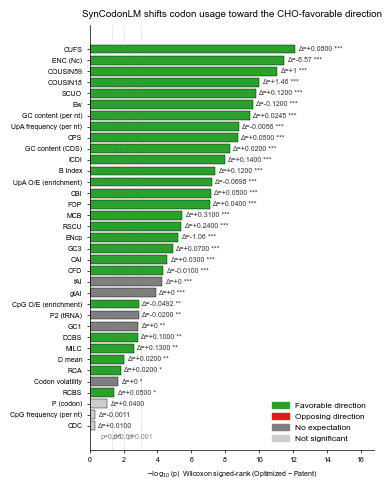

Saved: Figure_SynCodonLM_Direction_Summary.svg

=== Headline counts ===
Total metrics:          35
  Significant (p<0.05): 32  (91%)
  Favorable direction:  27
  Opposing direction:   0
  No expectation:       5
  Not significant:      3


In [22]:
# ============================================================
# Single-panel summary of SynCodonLM's directional impact
# Styled to match the waterfall SVG conventions.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# Input / output
# -----------------------------
SUMMARY_CSV = "AllMetrics_Patent_vs_Optimized_summary.csv"
OUT_FIG     = "Figure_SynCodonLM_Direction_Summary.svg"

CHAIN_FILTER = "All"

# -----------------------------
# SVG / figure styling (matches waterfall figure)
# -----------------------------
MM_TO_INCH = 1 / 25.4

FIG_WIDTH_MM   = 100          # match waterfall width
ROW_HEIGHT_MM  = 3.0         # vertical space per metric bar
MIN_HEIGHT_MM  = 80          # floor so tiny inputs still look ok
TOP_PAD_MM     = 12          # room for title
BOTTOM_PAD_MM  = 10          # room for x label

FONT_NAME          = "Arial"
TITLE_FONTSIZE     = 7
AXIS_FONTSIZE      = 5
TICK_FONTSIZE      = 5
TEXT_FONTSIZE      = 5
LEGEND_FONTSIZE    = 6

# Keep SVG text editable rather than converting fonts to paths
plt.rcParams["svg.fonttype"]  = "none"
plt.rcParams["font.family"]   = FONT_NAME
plt.rcParams["pdf.fonttype"]  = 42   # harmless, keeps text if you also save PDF

# -----------------------------
# Biological direction expectations
# -----------------------------
FAVORABLE_DIRECTION = {
    "CpG O/E (enrichment)":   -1,
    "UpA O/E (enrichment)":   -1,
    "CpG frequency (per nt)": -1,
    "UpA frequency (per nt)": -1,
    "GC content (per nt)":    +1,
    "GC content (CDS)":       +1,
    "GC1":                    +1,
    "GC2":                     0,
    "GC3":                    +1,
    "CAI":      +1,
    "FOP":      +1,
    "CBI":      +1,
    "RCA":      +1,
    "COUSIN18": +1,
    "COUSIN59": +1,
    "D mean":   +1,
    "CUFS":     +1,
    "B index":  +1,
    "CFD":      -1,
    "tAI":      +1,
    "gtAI":     +1,
    "P2 (tRNA)": 0,
    "RSCU":  +1,
    "ENC (Nc)": -1,
    "RCBS":  +1,
    "DCBS":  +1,
    "CDC":    0,
    "MILC":  +1,
    "ICDI":  +1,
    "SCUO":  +1,
    "Ew":    -1,
    "P (codon)": +1,
    "MCB":   +1,
    "ENcp":             -1,
    "CPS":              +1,
    "Codon volatility":  0,
}

# Colors
COLOR_MATCH    = "#2ca02c"
COLOR_OPPOSE   = "#e31a1c"
COLOR_NEUTRAL  = "#7f7f7f"
COLOR_NS       = "#cccccc"

# -----------------------------
# Load summary table
# -----------------------------
df = pd.read_csv(SUMMARY_CSV)
df = df[df["Chain"] == CHAIN_FILTER].copy()

if df.empty:
    raise ValueError(f"No rows with Chain == '{CHAIN_FILTER}' in {SUMMARY_CSV}")

df = df.dropna(subset=["p_value", "median_Delta"]).copy()

EPS = 1e-300
df["neg_log10_p"]  = -np.log10(df["p_value"].clip(lower=EPS))
df["observed_dir"] = np.sign(df["median_Delta"])
df["favorable_dir"] = df["Metric"].map(FAVORABLE_DIRECTION).fillna(0).astype(int)

def classify(row):
    if row["p_value"] >= 0.05:
        return "ns"
    if row["favorable_dir"] == 0:
        return "neutral"
    if row["observed_dir"] == row["favorable_dir"]:
        return "match"
    if row["observed_dir"] == -row["favorable_dir"]:
        return "oppose"
    return "neutral"

df["classification"] = df.apply(classify, axis=1)
df = df.sort_values("neg_log10_p", ascending=True).reset_index(drop=True)

# -----------------------------
# Figure sizing (mm-based, matching waterfall style)
# -----------------------------
n = len(df)
fig_height_mm = max(MIN_HEIGHT_MM, TOP_PAD_MM + BOTTOM_PAD_MM + ROW_HEIGHT_MM * n)
FIGSIZE = (FIG_WIDTH_MM * MM_TO_INCH, fig_height_mm * MM_TO_INCH)

fig, ax = plt.subplots(figsize=FIGSIZE)

color_map = {
    "match":   COLOR_MATCH,
    "oppose":  COLOR_OPPOSE,
    "neutral": COLOR_NEUTRAL,
    "ns":      COLOR_NS,
}
colors = [color_map[c] for c in df["classification"]]

ax.barh(
    df["Metric"],
    df["neg_log10_p"],
    color=colors,
    edgecolor="black",
    linewidth=0.3,
)

# Annotations: signed median Δ + significance stars
for y, (med, p) in enumerate(zip(df["median_Delta"], df["p_value"])):
    if   p < 0.001: stars = "***"
    elif p < 0.01:  stars = "**"
    elif p < 0.05:  stars = "*"
    else:           stars = ""
    if abs(med) >= 1 or abs(med) < 1e-3:
        label = f"Δ={med:+.3g} {stars}"
    else:
        label = f"Δ={med:+.4f} {stars}"
    ax.text(
        df["neg_log10_p"].iloc[y] + 0.15,
        y,
        label,
        va="center",
        fontsize=TEXT_FONTSIZE,
        fontname=FONT_NAME,
        color="#333333",
    )

# Significance threshold guides
for thresh, lbl in [(-np.log10(0.05),  "p=0.05"),
                    (-np.log10(0.01),  "p=0.01"),
                    (-np.log10(0.001), "p=0.001")]:
    ax.axvline(thresh, linestyle=":", color="gray", linewidth=0.5, alpha=0.6)
    ax.text(
        thresh, -0.7, lbl,
        fontsize=TEXT_FONTSIZE,
        fontname=FONT_NAME,
        ha="center", va="top", color="gray",
    )

# Labels / title
ax.set_xlabel(
    "$-\\log_{10}$(p)  Wilcoxon signed-rank (Optimized − Patent)",
    fontsize=AXIS_FONTSIZE,
    fontname=FONT_NAME,
)
ax.set_title(
    "SynCodonLM shifts codon usage toward the CHO-favorable direction",
    fontsize=TITLE_FONTSIZE,
    fontname=FONT_NAME,
)

# Legend
legend_handles = [
    mpatches.Patch(color=COLOR_MATCH,   label="Favorable direction"),
    mpatches.Patch(color=COLOR_OPPOSE,  label="Opposing direction"),
    mpatches.Patch(color=COLOR_NEUTRAL, label="No expectation"),
    mpatches.Patch(color=COLOR_NS,      label="Not significant"),
]
leg = ax.legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=LEGEND_FONTSIZE,
    frameon=False,
)
for txt in leg.get_texts():
    txt.set_fontname(FONT_NAME)

# Spines & ticks styled like the waterfall
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_FONTSIZE,
    width=0.5,
    length=2,
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname(FONT_NAME)
    label.set_fontsize(TICK_FONTSIZE)

# X-axis padding for annotation text
max_x = df["neg_log10_p"].max()
ax.set_xlim(0, max_x * 1.30 + 1)

plt.tight_layout()

fig.savefig(OUT_FIG, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_FIG}")

# -----------------------------
# Headline counts
# -----------------------------
print("\n=== Headline counts ===")
total     = len(df)
n_sig     = (df["p_value"] < 0.05).sum()
n_match   = (df["classification"] == "match").sum()
n_oppose  = (df["classification"] == "oppose").sum()
n_neutral = (df["classification"] == "neutral").sum()
n_ns      = (df["classification"] == "ns").sum()
print(f"Total metrics:          {total}")
print(f"  Significant (p<0.05): {n_sig}  ({100*n_sig/total:.0f}%)")
print(f"  Favorable direction:  {n_match}")
print(f"  Opposing direction:   {n_oppose}")
print(f"  No expectation:       {n_neutral}")
print(f"  Not significant:      {n_ns}")

Plotting 22 metrics:
   • ΔMFE first40 (no SP)
   • ΔMFE first40 (w/ SP)
   • ΔMFE full CDS (no SP)
   • ΔMFE full CDS (w/ SP)
   • ΔEnsFE first40 (no SP)
   • ΔEnsFE first40 (w/ SP)
   • ΔEnsFE full CDS (no SP)
   • ΔEnsFE full CDS (w/ SP)
   • Δ window-min MFE (no SP)
   • Δ window-min MFE (w/ SP)
   • Δ start entropy (no SP)
   • Δ start entropy (w/ SP)
   • ΔMFE first40 % (no SP)
   • ΔMFE first40 % (w/ SP)
   • ΔMFE full CDS % (no SP)
   • ΔMFE full CDS % (w/ SP)
   • ΔEnsFE first40 % (no SP)
   • ΔEnsFE first40 % (w/ SP)
   • ΔEnsFE full CDS % (no SP)
   • ΔEnsFE full CDS % (w/ SP)
   • Δ window-min MFE % (no SP)
   • Δ window-min MFE % (w/ SP)
Heavy n: 24
Light n: 24
Mean n: 24

Saved: Vienna_vs_Titer_correlations_PearsonR.csv


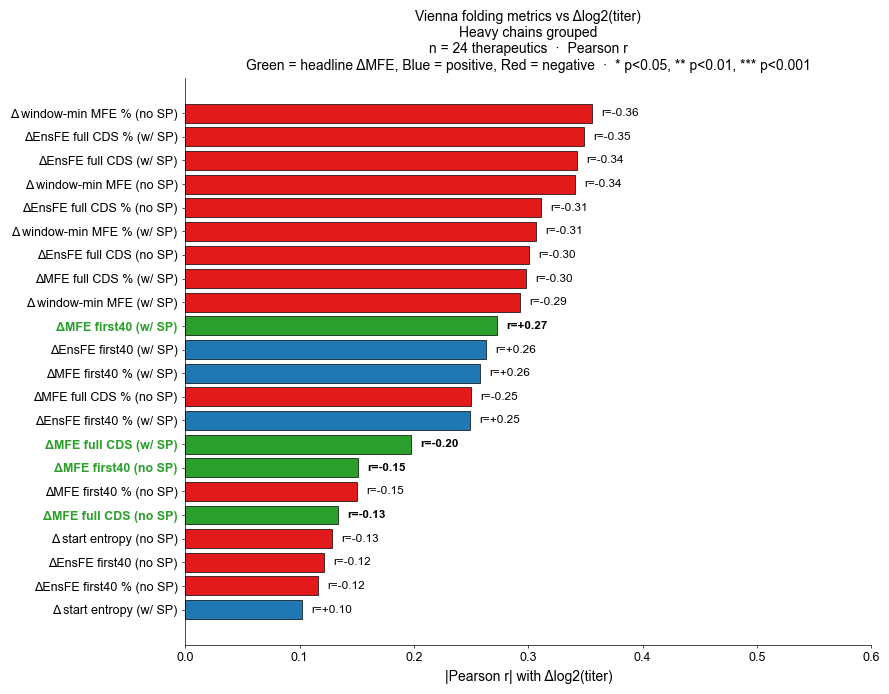

Saved: Figure_Vienna_vs_Titer_PearsonR_Heavy.pdf


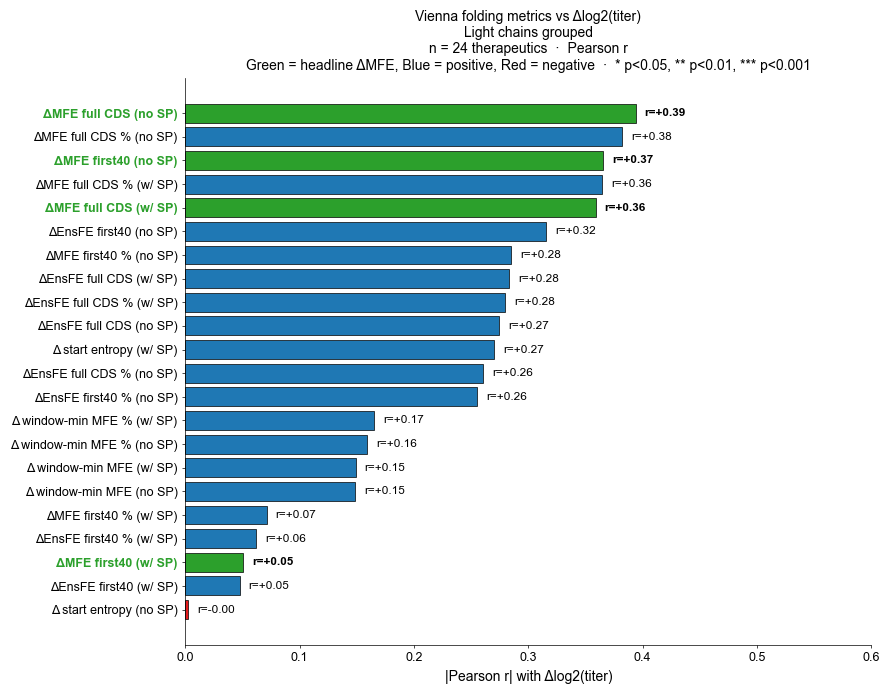

Saved: Figure_Vienna_vs_Titer_PearsonR_Light.pdf


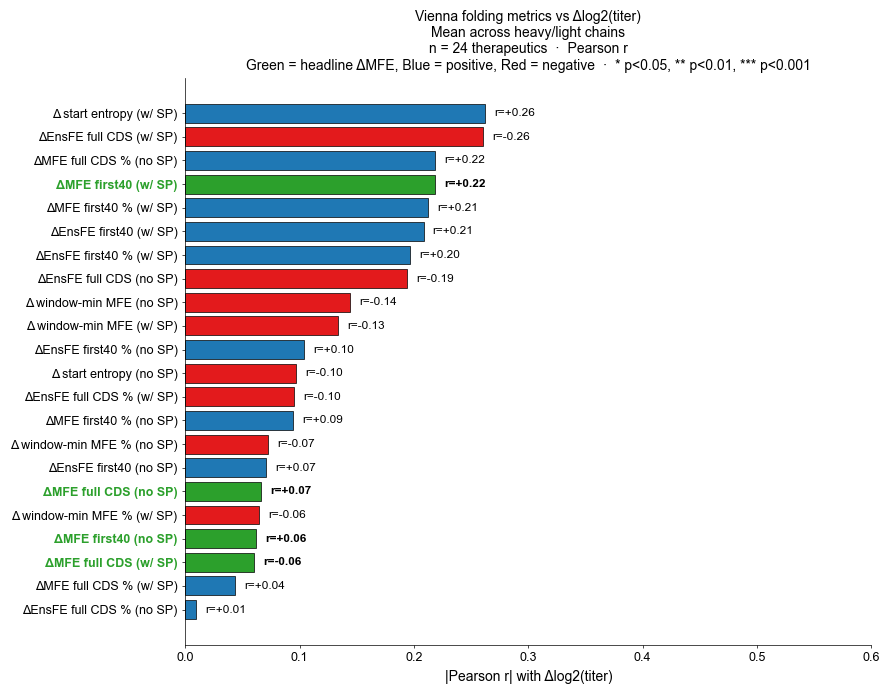

Saved: Figure_Vienna_vs_Titer_PearsonR_Mean.pdf

=== Heavy grouping (Pearson r) ===
 Rank                    Display  Pearson r  p_value  n
    1 Δ window-min MFE % (no SP)  -0.355647 0.088088 24
    2  ΔEnsFE full CDS % (w/ SP)  -0.348456 0.095173 24
    3    ΔEnsFE full CDS (w/ SP)  -0.342931 0.100899 24
    4   Δ window-min MFE (no SP)  -0.341277 0.102662 24
    5  ΔEnsFE full CDS % (no SP)  -0.311080 0.138976 24
    6 Δ window-min MFE % (w/ SP)  -0.306890 0.144660 24
    7    ΔEnsFE full CDS (no SP)  -0.300502 0.153641 24
    8    ΔMFE full CDS % (w/ SP)  -0.297759 0.157616 24
    9   Δ window-min MFE (w/ SP)  -0.293081 0.164561 24
   10       ΔMFE first40 (w/ SP)   0.272524 0.197618 24
   11     ΔEnsFE first40 (w/ SP)   0.262980 0.214402 24
   12     ΔMFE first40 % (w/ SP)   0.257751 0.223990 24
   13    ΔMFE full CDS % (no SP)  -0.250048 0.238629 24
   14   ΔEnsFE first40 % (w/ SP)   0.248940 0.240785 24
   15      ΔMFE full CDS (w/ SP)  -0.197605 0.354678 24
   16       ΔMFE fir

In [23]:
# ============================================================
# Δlog2(titer) vs Vienna RNA folding metrics
# Reads vienna_first40codons_metrics.xlsx, computes correlations
# against Δlog2(titer) for: headline 5′ ΔMFEs, ensemble FE,
# sliding-window min MFE, positional entropy, mountain AUC,
# and %-normalized versions.
#
# Three separate bar chart figures (Heavy / Light / Mean).
# ============================================================

CORRELATION_METRIC = "pearson"   # "pearson" | "spearman" | "r2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import re

# -----------------------------
# Input files
# -----------------------------
TITER_FILE  = "master-data.xlsx"
VIENNA_FILE = "vienna-mrna-structure-metrics.xlsx"
VIENNA_SHEET = "Vienna_Metrics"

# -----------------------------
# Settings
# -----------------------------
ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL    = "Mutated"
TOO_LOW_AS   = np.nan
TITER_PATTERN = r"^Titer\s*mg/L\s*Rep\s*\d+$"

COLOR_POS = "#1f78b4"   # blue
COLOR_NEG = "#e31a1c"   # red
COLOR_HL  = "#2ca02c"   # green — highlight the headline 5′ deltas

# -----------------------------
# Raw delta metrics (from updated Vienna script)
# -----------------------------
RAW_DELTAS = [
    # --- Original MFE deltas ---
    "Delta_first40_MFE_noSP",
    "Delta_first40_MFE_wSP",
    "Delta_full_MFE_noSP",
    "Delta_full_MFE_wSP",

    # --- Ensemble free energy (partition function) ---
    "Delta_first40_ensembleFE_noSP",
    "Delta_first40_ensembleFE_wSP",
    "Delta_full_ensembleFE_noSP",
    "Delta_full_ensembleFE_wSP",

    # --- Sliding-window min MFE along full CDS ---
    "Delta_window_minMFE_noSP",
    "Delta_window_minMFE_wSP",

    # --- Positional entropy over first 30 nt ---
    "Delta_startEntropy_noSP",
    "Delta_startEntropy_wSP",

    # --- Mountain plot AUC over first 40 codons ---
    "Delta_first40_mountainAUC_noSP",
    "Delta_first40_mountainAUC_wSP",
]

# Baselines used only for computing % deltas (not plotted)
PCT_BASELINES = {
    "Delta_first40_MFE_noSP":          "Original_first40_MFE_noSP",
    "Delta_first40_MFE_wSP":           "Original_first40_MFE_wSP",
    "Delta_full_MFE_noSP":             "Original_full_MFE_noSP",
    "Delta_full_MFE_wSP":              "Original_full_MFE_wSP",
    "Delta_first40_ensembleFE_noSP":   "Original_first40_ensembleFE_noSP",
    "Delta_first40_ensembleFE_wSP":    "Original_first40_ensembleFE_wSP",
    "Delta_full_ensembleFE_noSP":      "Original_full_ensembleFE_noSP",
    "Delta_full_ensembleFE_wSP":       "Original_full_ensembleFE_wSP",
    "Delta_window_minMFE_noSP":        "Original_window_minMFE_noSP",
    "Delta_window_minMFE_wSP":         "Original_window_minMFE_wSP",
}

# Friendly display names
DISPLAY_NAMES = {
    # Raw MFE
    "Delta_first40_MFE_noSP":   "ΔMFE first40 (no SP)",
    "Delta_first40_MFE_wSP":    "ΔMFE first40 (w/ SP)",
    "Delta_full_MFE_noSP":      "ΔMFE full CDS (no SP)",
    "Delta_full_MFE_wSP":       "ΔMFE full CDS (w/ SP)",

    # Ensemble FE
    "Delta_first40_ensembleFE_noSP":  "ΔEnsFE first40 (no SP)",
    "Delta_first40_ensembleFE_wSP":   "ΔEnsFE first40 (w/ SP)",
    "Delta_full_ensembleFE_noSP":     "ΔEnsFE full CDS (no SP)",
    "Delta_full_ensembleFE_wSP":      "ΔEnsFE full CDS (w/ SP)",

    # Sliding window min MFE
    "Delta_window_minMFE_noSP":  "Δ window-min MFE (no SP)",
    "Delta_window_minMFE_wSP":   "Δ window-min MFE (w/ SP)",

    # Positional entropy
    "Delta_startEntropy_noSP":   "Δ start entropy (no SP)",
    "Delta_startEntropy_wSP":    "Δ start entropy (w/ SP)",

    # Mountain AUC
    "Delta_first40_mountainAUC_noSP":  "Δ mountain AUC (no SP)",
    "Delta_first40_mountainAUC_wSP":   "Δ mountain AUC (w/ SP)",

    # % versions (added below)
    "Delta_first40_MFE_noSP_pct":         "ΔMFE first40 % (no SP)",
    "Delta_first40_MFE_wSP_pct":          "ΔMFE first40 % (w/ SP)",
    "Delta_full_MFE_noSP_pct":            "ΔMFE full CDS % (no SP)",
    "Delta_full_MFE_wSP_pct":             "ΔMFE full CDS % (w/ SP)",
    "Delta_first40_ensembleFE_noSP_pct":  "ΔEnsFE first40 % (no SP)",
    "Delta_first40_ensembleFE_wSP_pct":   "ΔEnsFE first40 % (w/ SP)",
    "Delta_full_ensembleFE_noSP_pct":     "ΔEnsFE full CDS % (no SP)",
    "Delta_full_ensembleFE_wSP_pct":      "ΔEnsFE full CDS % (w/ SP)",
    "Delta_window_minMFE_noSP_pct":       "Δ window-min MFE % (no SP)",
    "Delta_window_minMFE_wSP_pct":        "Δ window-min MFE % (w/ SP)",
}

# Highlight the four "headline" first-40-codons metrics (MFE only) in green
HIGHLIGHT_METRICS = {
    "Delta_first40_MFE_noSP",
    "Delta_first40_MFE_wSP",
    "Delta_full_MFE_noSP",
    "Delta_full_MFE_wSP",
}

# -----------------------------
# Correlation config
# -----------------------------
CORRELATION_METRIC = CORRELATION_METRIC.lower()
assert CORRELATION_METRIC in {"pearson", "spearman", "r2"}

METRIC_INFO = {
    "pearson":  {"stat_label": "Pearson r",   "abs_label": "|Pearson r|",
                 "value_prefix": "r",  "func": pearsonr,  "file_suffix": "PearsonR"},
    "spearman": {"stat_label": "Spearman ρ",  "abs_label": "|Spearman ρ|",
                 "value_prefix": "ρ",  "func": spearmanr, "file_suffix": "SpearmanRho"},
    "r2":       {"stat_label": "R²",          "abs_label": "R²",
                 "value_prefix": "R²", "func": pearsonr,  "file_suffix": "R2"},
}
CFG = METRIC_INFO[CORRELATION_METRIC]

GROUPING_CONFIG = {
    "Heavy": {"title": "Heavy chains grouped",
              "outfile": f"Figure_Vienna_vs_Titer_{CFG['file_suffix']}_Heavy.pdf"},
    "Light": {"title": "Light chains grouped",
              "outfile": f"Figure_Vienna_vs_Titer_{CFG['file_suffix']}_Light.pdf"},
    "Mean":  {"title": "Mean across heavy/light chains",
              "outfile": f"Figure_Vienna_vs_Titer_{CFG['file_suffix']}_Mean.pdf"},
}
OUT_TABLE = f"Vienna_vs_Titer_correlations_{CFG['file_suffix']}.csv"

# -----------------------------
# Helpers
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({"Too Low": TOO_LOW_AS, "too low": TOO_LOW_AS, "TOO LOW": TOO_LOW_AS,
                        "": np.nan, " ": np.nan, "NA": np.nan, "na": np.nan}),
        errors="coerce",
    )

def rep_num(c):
    m = re.search(r"(\d+)", str(c))
    return int(m.group(1)) if m else 999

def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"): return "Heavy"
    if s.startswith("light"): return "Light"
    return "Other"

def compute_stat(x, y):
    r, p = CFG["func"](x, y)
    sign = 1 if r >= 0 else -1
    if CORRELATION_METRIC == "r2":
        plot_value, signed_stat = r**2, r**2
    else:
        plot_value, signed_stat = abs(r), r
    return signed_stat, plot_value, sign, p

def fmt_value(signed_stat):
    pfx = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        return f"{pfx}={signed_stat:.2f}"
    return f"{pfx}={signed_stat:+.2f}"

# -----------------------------
# 1) Titer log2FC per therapeutic
# -----------------------------
df = pd.read_excel(TITER_FILE, engine="openpyxl")
df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE,
)
df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"]      = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

titer_cols = sorted(
    [c for c in df.columns if re.match(TITER_PATTERN, str(c).strip(), re.IGNORECASE)],
    key=rep_num,
)
for c in titer_cols:
    df[c] = clean_numeric(df[c])

df["Titer_row_mean"] = df[titer_cols].mean(axis=1, skipna=True)

titer_long = (df.groupby(["Base_Molecule", "Variant"], dropna=False)
                .agg(Titer_Mean=("Titer_row_mean", "mean"))
                .reset_index())
titer_wide = titer_long.pivot(index="Base_Molecule", columns="Variant",
                              values="Titer_Mean").reset_index()

for v in [PARENT_LABEL, MUT_LABEL]:
    if v not in titer_wide.columns:
        titer_wide[v] = np.nan

pos_vals = titer_wide[[PARENT_LABEL, MUT_LABEL]].values.flatten()
pos_vals = pos_vals[np.isfinite(pos_vals) & (pos_vals > 0)]
eps = 0.01 * np.min(pos_vals) if len(pos_vals) else 1e-6

titer_wide["Titer_log2FC"] = np.log2(
    (titer_wide[MUT_LABEL] + eps) / (titer_wide[PARENT_LABEL] + eps)
)
titer_wide = titer_wide.rename(columns={"Base_Molecule": "Therapeutic"})
titer_wide = titer_wide[["Therapeutic", "Titer_log2FC"]]

# -----------------------------
# 2) Vienna file — load + build %-normalized deltas
# -----------------------------
vienna = pd.read_excel(VIENNA_FILE, sheet_name=VIENNA_SHEET, engine="openpyxl")
vienna["Therapeutic"] = vienna["Therapeutic"].astype(str).str.strip()
vienna["Chain"]       = vienna["Chain"].astype(str).str.strip()
vienna["Chain_Group"] = vienna["Chain"].apply(get_chain_group)
vienna = vienna[vienna["Chain_Group"].isin(["Heavy", "Light"])].copy()

# Coerce all relevant columns to numeric
all_input_cols = set(RAW_DELTAS) | set(PCT_BASELINES.values())
for c in all_input_cols:
    if c in vienna.columns:
        vienna[c] = pd.to_numeric(vienna[c], errors="coerce")

# %-normalized deltas (only for energy-like metrics)
def safe_pct(delta, baseline):
    b = baseline.abs()
    return np.where(b > 1e-9, delta / b * 100.0, np.nan)

PCT_DELTAS = []
for delta_col, baseline_col in PCT_BASELINES.items():
    if delta_col in vienna.columns and baseline_col in vienna.columns:
        pct_col = f"{delta_col}_pct"
        vienna[pct_col] = safe_pct(vienna[delta_col], vienna[baseline_col])
        PCT_DELTAS.append(pct_col)

# All metrics to plot — deltas only (raw + %)
metric_cols = [c for c in RAW_DELTAS + PCT_DELTAS if c in vienna.columns]

print(f"Plotting {len(metric_cols)} metrics:")
for c in metric_cols:
    print(f"   • {DISPLAY_NAMES.get(c, c)}")

# -----------------------------
# 3) Aggregate per therapeutic / chain group
# -----------------------------
def agg_group(group_key):
    if group_key == "Mean":
        sub = vienna
    else:
        sub = vienna[vienna["Chain_Group"] == group_key]
    return sub.groupby("Therapeutic", as_index=False)[metric_cols].mean()

vienna_by_group = {g: agg_group(g) for g in ["Heavy", "Light", "Mean"]}

merged_by_group = {}
for g in ["Heavy", "Light", "Mean"]:
    m = titer_wide.merge(vienna_by_group[g], on="Therapeutic", how="inner")
    merged_by_group[g] = m
    print(f"{g} n: {len(m)}")

# -----------------------------
# 4) Correlation tables
# -----------------------------
def corr_table(merged, label):
    rows = []
    for c in metric_cols:
        d = merged[["Titer_log2FC", c]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(d) < 3 or d[c].nunique() < 2:
            continue
        signed_stat, plot_value, sign, p = compute_stat(d[c].values, d["Titer_log2FC"].values)
        rows.append({
            "Grouping":    label,
            "Metric":      c,
            "Display":     DISPLAY_NAMES.get(c, c),
            "Stat_signed": signed_stat,
            "Plot_value":  plot_value,
            "Sign":        sign,
            "p_value":     p,
            "n":           len(d),
        })
    return pd.DataFrame(rows)

results_by_group = {g: corr_table(merged_by_group[g], g) for g in ["Heavy", "Light", "Mean"]}

all_res = pd.concat(results_by_group.values(), ignore_index=True).rename(columns={
    "Stat_signed": f"{CFG['stat_label']} (signed)",
    "Plot_value":  CFG["abs_label"],
})
all_res.to_csv(OUT_TABLE, index=False)
print(f"\nSaved: {OUT_TABLE}")

# -----------------------------
# 5) Bar charts
# -----------------------------
def plot_grouping(res_df, merged_df, title, outfile):
    d = res_df.sort_values("Plot_value", ascending=True).copy()
    n_used = len(merged_df)

    fig, ax = plt.subplots(figsize=(9.0, max(5.0, 0.32 * len(d))))

    highlight_labels = {DISPLAY_NAMES[m] for m in HIGHLIGHT_METRICS
                        if m in DISPLAY_NAMES}

    colors = []
    for metric, sign in zip(d["Metric"], d["Sign"]):
        if metric in HIGHLIGHT_METRICS:
            colors.append(COLOR_HL)
        elif sign < 0:
            colors.append(COLOR_NEG)
        else:
            colors.append(COLOR_POS)

    ax.barh(d["Display"], d["Plot_value"],
            color=colors, edgecolor="black", linewidth=0.5)

    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() in highlight_labels:
            tick_label.set_fontweight("bold")
            tick_label.set_color(COLOR_HL)

    for y, (metric, signed_stat, pv, p) in enumerate(zip(
        d["Metric"], d["Stat_signed"], d["Plot_value"], d["p_value"]
    )):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        weight = "bold" if metric in HIGHLIGHT_METRICS else "normal"
        ax.text(pv + 0.008, y, f"{fmt_value(signed_stat)}{sig}",
                va="center", fontsize=8.5, fontweight=weight)

    ax.set_xlabel(f"{CFG['abs_label']} with Δlog2(titer)", fontsize=10)
    legend_line = "Green = headline ΔMFE, Blue = positive, Red = negative"
    ax.set_title(
        f"Vienna folding metrics vs Δlog2(titer)\n{title}\n"
        f"n = {n_used} therapeutics  ·  {CFG['stat_label']}\n"
        f"{legend_line}  ·  * p<0.05, ** p<0.01, *** p<0.001",
        fontsize=10,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, max(0.6, d["Plot_value"].max() * 1.30))
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    plt.tight_layout()
    fig.savefig(outfile, bbox_inches="tight")
    plt.show()
    print(f"Saved: {outfile}")

for key, cfg in GROUPING_CONFIG.items():
    plot_grouping(
        res_df=results_by_group[key],
        merged_df=merged_by_group[key],
        title=cfg["title"],
        outfile=cfg["outfile"],
    )

# -----------------------------
# 6) Console preview: full ranking per grouping
# -----------------------------
for label, res in results_by_group.items():
    ranked = res.sort_values("Plot_value", ascending=False).reset_index(drop=True)
    ranked["Rank"] = ranked.index + 1
    print(f"\n=== {label} grouping ({CFG['stat_label']}) ===")
    preview = ranked[["Rank", "Display", "Stat_signed", "p_value", "n"]].rename(
        columns={"Stat_signed": CFG["stat_label"]}
    )
    print(preview.to_string(index=False))

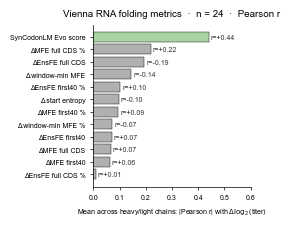

Saved: Figure_Vienna_vs_Titer_PearsonR_Mean.svg


In [24]:
# ============================================================
# Mean across heavy/light chains — Vienna structural metrics + Evo
# Nature-submission SVG styling to match the waterfall figure.
# Excludes all "w/ SP" metrics. Adds SynCodonLM Evo (r = 0.44).
# Only the Evo bar is green; everything else is gray.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# SVG / figure styling (matches waterfall)
# -----------------------------
MM_TO_INCH = 1 / 25.4

FIG_WIDTH_MM  = 70     # Nature single column
ROW_HEIGHT_MM = 3.2
BASE_PAD_MM   = 22     # room for title + xlabel

FONT_NAME       = "Arial"
TITLE_FONTSIZE  = 7
AXIS_FONTSIZE   = 5
TICK_FONTSIZE   = 5
TEXT_FONTSIZE   = 5

# Colors — classical metrics gray, SynCodonLM Evo pastel green
COLOR_CLASSICAL = "#b0b0b0"
COLOR_EVO       = "#a8d5a2"

# Keep SVG text editable
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"]  = FONT_NAME
plt.rcParams["pdf.fonttype"] = 42

OUT_FIG = f"Figure_Vienna_vs_Titer_{CFG['file_suffix']}_Mean.svg"

# -----------------------------
# Evo entry (SynCodonLM)
# -----------------------------
EVO_METRIC_NAME = "Evo_SynCodonLM"
EVO_DISPLAY     = "SynCodonLM Evo score"
EVO_R           = 0.44
EVO_P           = np.nan  # not shown

# -----------------------------
# Data — filter out w/ SP metrics, then append Evo
# -----------------------------
res_df    = results_by_group["Mean"].copy()
merged_df = merged_by_group["Mean"]
n_used    = len(merged_df)

# Drop anything containing "wSP" (raw or _pct)
res_df = res_df[~res_df["Metric"].str.contains("wSP", case=False, na=False)].copy()

# Build Evo row consistent with existing schema
if CORRELATION_METRIC == "r2":
    evo_plot, evo_signed = EVO_R ** 2, EVO_R ** 2
else:
    evo_plot, evo_signed = abs(EVO_R), EVO_R

evo_row = pd.DataFrame([{
    "Grouping":    "Mean",
    "Metric":      EVO_METRIC_NAME,
    "Display":     EVO_DISPLAY,
    "Stat_signed": evo_signed,
    "Plot_value":  evo_plot,
    "Sign":        1 if EVO_R >= 0 else -1,
    "p_value":     EVO_P,
    "n":           n_used,
}])

d = pd.concat([res_df, evo_row], ignore_index=True)
d = d.sort_values("Plot_value", ascending=True).reset_index(drop=True)

# Strip " (no SP)" from tick labels
d["Display"] = d["Display"].str.replace(r"\s*\(no SP\)", "", regex=True)

# -----------------------------
# Formatting helpers
# -----------------------------
def fmt_value(signed_stat):
    prefix = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        return f"{prefix}={signed_stat:.2f}"
    return f"{prefix}={signed_stat:+.2f}"

def sig_stars(p):
    if not np.isfinite(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# -----------------------------
# Figure
# -----------------------------
fig_height_mm = BASE_PAD_MM + ROW_HEIGHT_MM * len(d)
FIGSIZE = (FIG_WIDTH_MM * MM_TO_INCH, fig_height_mm * MM_TO_INCH)

fig, ax = plt.subplots(figsize=FIGSIZE)

colors = [
    COLOR_EVO if metric == EVO_METRIC_NAME else COLOR_CLASSICAL
    for metric in d["Metric"]
]

ax.barh(
    d["Display"], d["Plot_value"],
    color=colors, edgecolor="black", linewidth=0.3,
)

# Bar annotations — uniform styling for all bars
for y, (signed_stat, pv, p) in enumerate(zip(
    d["Stat_signed"], d["Plot_value"], d["p_value"]
)):
    ax.text(
        pv + 0.008, y,
        f"{fmt_value(signed_stat)}{sig_stars(p)}",
        va="center",
        fontsize=TEXT_FONTSIZE,
        fontname=FONT_NAME,
        color="#333333",
    )

# Labels / title
ax.set_xlabel(
    f"Mean across heavy/light chains: {CFG['abs_label']} with $\\Delta\\log_{{2}}$(titer)",
    fontsize=AXIS_FONTSIZE,
    fontname=FONT_NAME,
)
ax.set_title(
    f"Vienna RNA folding metrics  ·  "
    f"n = {n_used}  ·  {CFG['stat_label']}",
    fontsize=TITLE_FONTSIZE,
    fontname=FONT_NAME,
)

# Spines & ticks (waterfall style)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.tick_params(
    axis="both", which="major",
    labelsize=TICK_FONTSIZE, width=0.5, length=2,
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname(FONT_NAME)
    label.set_fontsize(TICK_FONTSIZE)

ax.set_xlim(0, max(0.6, d["Plot_value"].max() * 1.35))

plt.tight_layout()
fig.savefig(OUT_FIG, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_FIG}")

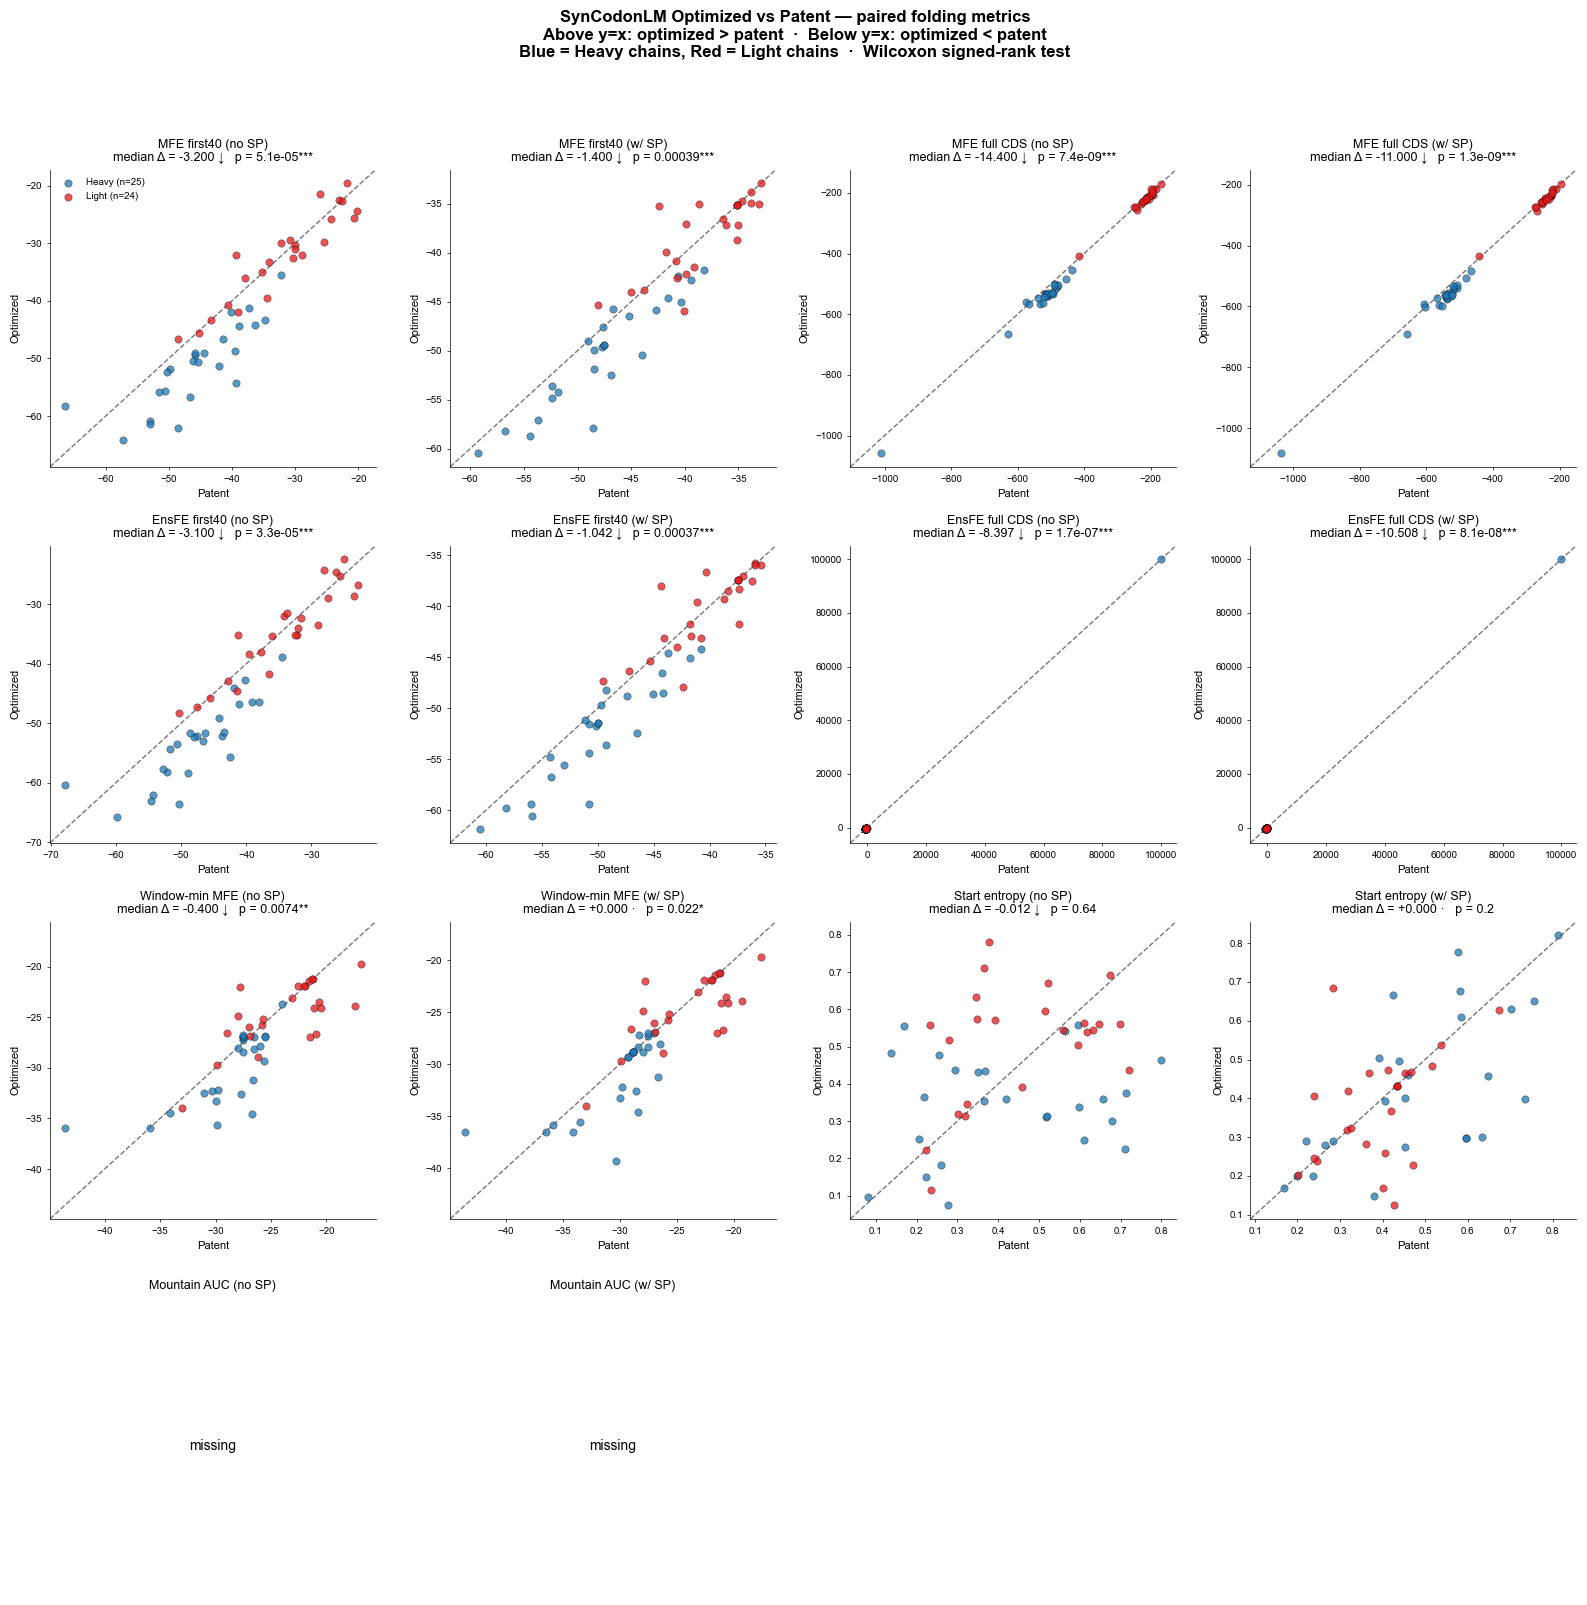

Saved: Figure_Vienna_Patent_vs_Optimized_paired.pdf

=== Per-metric paired test, split by chain class ===

                Metric Chain  n  median_Patent  median_Optimized  median_Delta      p_value sig
   MFE first40 (no SP) Heavy 25     -45.799999        -50.599998     -5.199997 1.507998e-05 ***
   MFE first40 (no SP) Light 24     -30.599999        -31.500000     -0.050000 6.147647e-01    
   MFE first40 (no SP)   All 49     -39.299999        -43.299999     -3.200001 5.054765e-05 ***
   MFE first40 (w/ SP) Heavy 25     -47.599998        -49.599998     -2.399998 3.081875e-05 ***
   MFE first40 (w/ SP) Light 24     -37.550001        -37.150000      0.000000 7.172904e-01    
   MFE first40 (w/ SP)   All 49     -41.799999        -44.000000     -1.400002 3.924188e-04 ***
  MFE full CDS (no SP) Heavy 25    -510.700012       -534.299988    -24.500000 2.980232e-07 ***
  MFE full CDS (no SP) Light 24    -208.699997       -215.150002     -4.899994 8.714795e-03  **
  MFE full CDS (no SP)   All 

In [25]:
# ============================================================
# Patent vs Optimized folding metrics — paired scatter plots
# Reads vienna_first40codons_metrics.xlsx and plots, for each
# folding metric, the Optimized value vs the Patent value with
# a y=x reference line, colored by chain class.
#
# A point above the y=x line means: optimized > patent
# A point below the y=x line means: optimized < patent
# (Sign interpretation depends on the metric — see notes)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import re

# -----------------------------
# Input
# -----------------------------
VIENNA_FILE  = "vienna-mrna-structure-metrics.xlsx"
VIENNA_SHEET = "Vienna_Metrics"
OUT_FIG      = "Figure_Vienna_Patent_vs_Optimized_paired.pdf"

# Colors
COLOR_HEAVY = "#1f78b4"   # blue
COLOR_LIGHT = "#e31a1c"   # red
COLOR_DIAG  = "#777777"

# -----------------------------
# Metric pairs: (display name, patent col, optimized col)
# -----------------------------
METRIC_PAIRS = [
    # --- MFE ---
    ("MFE first40 (no SP)",
     "Original_first40_MFE_noSP",  "Optimized_first40_MFE_noSP"),
    ("MFE first40 (w/ SP)",
     "Original_first40_MFE_wSP",   "Optimized_first40_MFE_wSP"),
    ("MFE full CDS (no SP)",
     "Original_full_MFE_noSP",     "Optimized_full_MFE_noSP"),
    ("MFE full CDS (w/ SP)",
     "Original_full_MFE_wSP",      "Optimized_full_MFE_wSP"),

    # --- Ensemble FE ---
    ("EnsFE first40 (no SP)",
     "Original_first40_ensembleFE_noSP", "Optimized_first40_ensembleFE_noSP"),
    ("EnsFE first40 (w/ SP)",
     "Original_first40_ensembleFE_wSP",  "Optimized_first40_ensembleFE_wSP"),
    ("EnsFE full CDS (no SP)",
     "Original_full_ensembleFE_noSP",    "Optimized_full_ensembleFE_noSP"),
    ("EnsFE full CDS (w/ SP)",
     "Original_full_ensembleFE_wSP",     "Optimized_full_ensembleFE_wSP"),

    # --- Sliding window min MFE ---
    ("Window-min MFE (no SP)",
     "Original_window_minMFE_noSP", "Optimized_window_minMFE_noSP"),
    ("Window-min MFE (w/ SP)",
     "Original_window_minMFE_wSP",  "Optimized_window_minMFE_wSP"),

    # --- Positional entropy ---
    ("Start entropy (no SP)",
     "Original_startEntropy_noSP", "Optimized_startEntropy_noSP"),
    ("Start entropy (w/ SP)",
     "Original_startEntropy_wSP",  "Optimized_startEntropy_wSP"),

    # --- Mountain AUC ---
    ("Mountain AUC (no SP)",
     "Original_first40_mountainAUC_noSP", "Optimized_first40_mountainAUC_noSP"),
    ("Mountain AUC (w/ SP)",
     "Original_first40_mountainAUC_wSP",  "Optimized_first40_mountainAUC_wSP"),
]

# -----------------------------
# Helpers
# -----------------------------
def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"): return "Heavy"
    if s.startswith("light"): return "Light"
    return "Other"

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# -----------------------------
# Load Vienna metrics
# -----------------------------
vienna = pd.read_excel(VIENNA_FILE, sheet_name=VIENNA_SHEET, engine="openpyxl")
vienna["Chain_Group"] = vienna["Chain"].apply(get_chain_group)
vienna = vienna[vienna["Chain_Group"].isin(["Heavy", "Light"])].copy()

# Coerce all metric columns to numeric
all_cols = set()
for _, pat, opt in METRIC_PAIRS:
    all_cols.add(pat); all_cols.add(opt)
for c in all_cols:
    if c in vienna.columns:
        vienna[c] = pd.to_numeric(vienna[c], errors="coerce")

# -----------------------------
# Plot grid
# -----------------------------
ncols = 4
nrows = int(np.ceil(len(METRIC_PAIRS) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for ax_idx, (display, pat_col, opt_col) in enumerate(METRIC_PAIRS):
    ax = axes[ax_idx]

    if pat_col not in vienna.columns or opt_col not in vienna.columns:
        ax.text(0.5, 0.5, "missing", ha="center", va="center")
        ax.set_title(display, fontsize=9)
        ax.axis("off")
        continue

    d = vienna[[pat_col, opt_col, "Chain_Group"]].replace(
        [np.inf, -np.inf], np.nan).dropna()

    if len(d) < 3:
        ax.text(0.5, 0.5, "n<3", ha="center", va="center")
        ax.set_title(display, fontsize=9)
        ax.axis("off")
        continue

    # Plot Heavy and Light separately
    for chain_grp, color in [("Heavy", COLOR_HEAVY), ("Light", COLOR_LIGHT)]:
        sub = d[d["Chain_Group"] == chain_grp]
        if len(sub) == 0:
            continue
        ax.scatter(sub[pat_col], sub[opt_col],
                   c=color, s=28, alpha=0.75,
                   edgecolor="black", linewidth=0.3,
                   label=f"{chain_grp} (n={len(sub)})")

    # y = x reference line
    lo = min(d[pat_col].min(), d[opt_col].min())
    hi = max(d[pat_col].max(), d[opt_col].max())
    pad = 0.05 * (hi - lo) if hi > lo else 1
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            "--", color=COLOR_DIAG, linewidth=1.0, zorder=0)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)

    # Paired Wilcoxon signed-rank test (Optimized - Patent)
    deltas = d[opt_col].values - d[pat_col].values
    try:
        stat, p = wilcoxon(deltas)
    except ValueError:
        p = np.nan

    median_delta = float(np.median(deltas))
    direction = "↑" if median_delta > 0 else ("↓" if median_delta < 0 else "·")

    ax.set_title(
        f"{display}\nmedian Δ = {median_delta:+.3f} {direction}   "
        f"p = {p:.2g}{sig_stars(p) if not np.isnan(p) else ''}",
        fontsize=9,
    )
    ax.set_xlabel("Patent", fontsize=8)
    ax.set_ylabel("Optimized", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if ax_idx == 0:
        ax.legend(fontsize=7, loc="best", frameon=False)

# Hide unused axes
for k in range(len(METRIC_PAIRS), len(axes)):
    axes[k].axis("off")

fig.suptitle(
    "SynCodonLM Optimized vs Patent — paired folding metrics\n"
    "Above y=x: optimized > patent  ·  Below y=x: optimized < patent\n"
    "Blue = Heavy chains, Red = Light chains  ·  Wilcoxon signed-rank test",
    fontsize=12, fontweight="bold", y=1.00,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_FIG, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_FIG}")

# -----------------------------
# Summary table per chain class
# -----------------------------
print("\n=== Per-metric paired test, split by chain class ===\n")
summary_rows = []
for display, pat_col, opt_col in METRIC_PAIRS:
    if pat_col not in vienna.columns or opt_col not in vienna.columns:
        continue
    for chain_grp in ["Heavy", "Light", "All"]:
        if chain_grp == "All":
            sub = vienna
        else:
            sub = vienna[vienna["Chain_Group"] == chain_grp]
        d = sub[[pat_col, opt_col]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(d) < 3:
            continue
        deltas = d[opt_col].values - d[pat_col].values
        try:
            _, p = wilcoxon(deltas)
        except ValueError:
            p = np.nan
        summary_rows.append({
            "Metric": display,
            "Chain": chain_grp,
            "n": len(d),
            "median_Patent":   float(np.median(d[pat_col])),
            "median_Optimized": float(np.median(d[opt_col])),
            "median_Delta":    float(np.median(deltas)),
            "p_value":         p,
            "sig":             sig_stars(p) if not np.isnan(p) else "",
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv("Vienna_Patent_vs_Optimized_paired_summary.csv", index=False)
print("\nSaved: Vienna_Patent_vs_Optimized_paired_summary.csv")

Loaded 54 chain pairs (Heavy=28, Light=26)
Saved per-chain summary: Mutation_Position_PerChain_Summary.csv
  Heavy chains:    28
  Light chains:    26
  Mean % codons mutated  Heavy: 9.9%
  Mean % codons mutated  Light: 9.7%


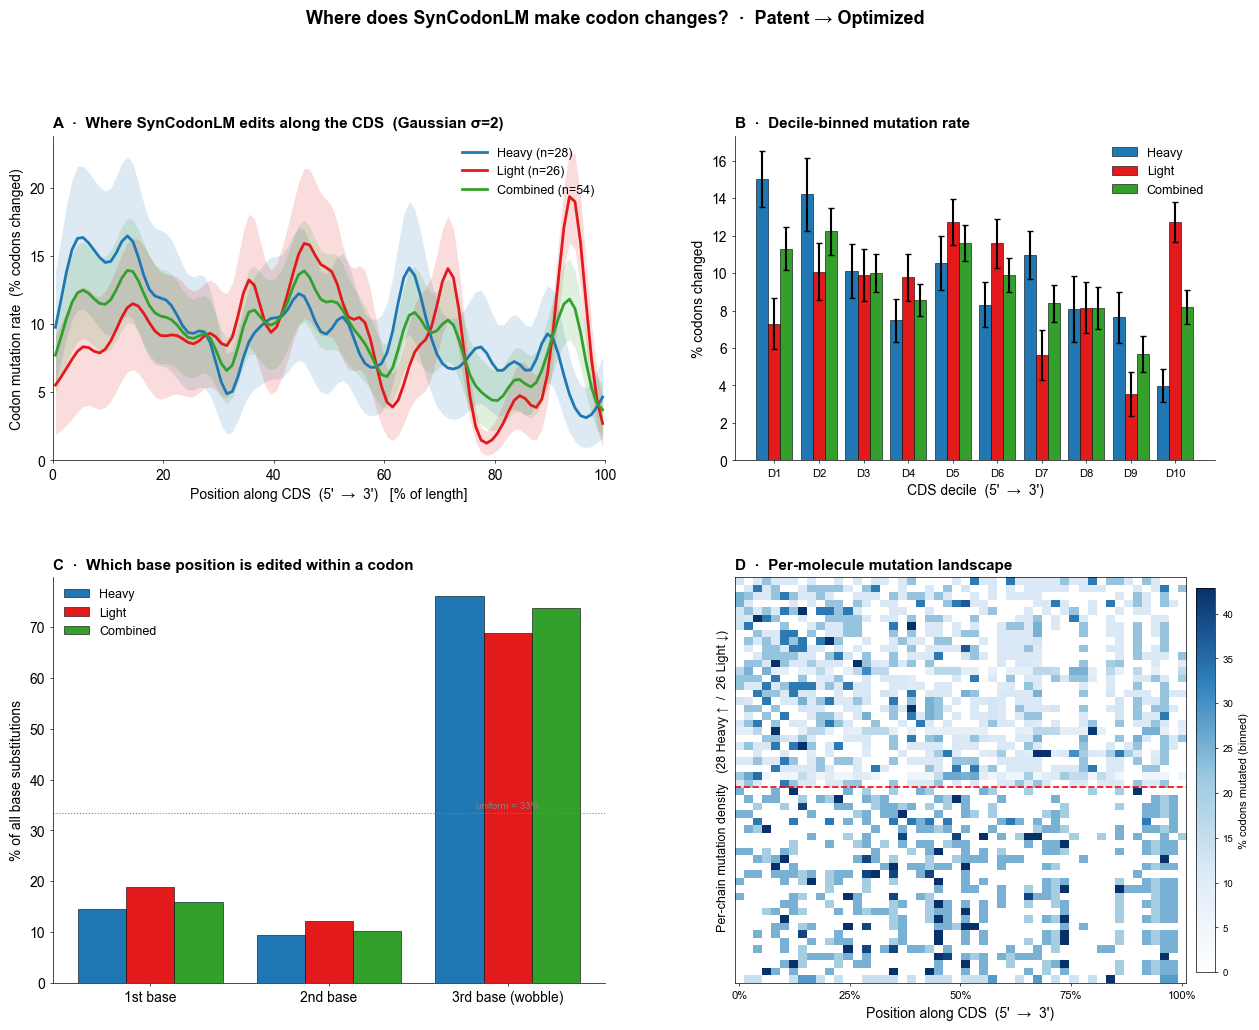

Saved figure: Figure_Mutation_Position_Landscape.pdf

=== Summary statistics ===

Heavy (n=28 chains)
  Mean % codons mutated: 9.90%  (median 9.89%, range 9.8–10.0%)
  Mean codons per chain:  479
  Base-position distribution of nt changes:
     position 1:  14.6%   (234 substitutions)
     position 2:   9.4%   (150 substitutions)
     position 3:  76.0%   (1218 substitutions)

Light (n=26 chains)
  Mean % codons mutated: 9.68%  (median 9.81%, range 7.5–9.9%)
  Mean codons per chain:  219
  Base-position distribution of nt changes:
     position 1:  18.9%   (139 substitutions)
     position 2:  12.2%   (90 substitutions)
     position 3:  68.9%   (507 substitutions)


In [26]:
# ============================================================
# Where does SynCodonLM make codon changes?
# Positional mutation landscape: Heavy vs Light vs Combined
#
# For every Patent → Optimized pair this cell:
#   1) Aligns sequences codon-by-codon (length-matched)
#   2) Flags codons where ≥1 nt differs (= synonymous codon swap)
#   3) Tracks WHERE along the CDS the changes occur
#   4) Tracks WHICH base position within the codon was edited
#                                                            (1st / 2nd / 3rd)
#
# Output: 4-panel figure
#   A) Smoothed codon-mutation rate vs normalized CDS position
#   B) Decile-binned mutation rate (5'→3') as grouped bars
#   C) Within-codon base-position preference (1st / 2nd / 3rd)
#   D) Per-molecule heatmap of mutation density (sorted by length)
#
# Also writes a tidy CSV with per-chain mutation stats.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter1d

# -----------------------------
# Inputs / outputs
# -----------------------------
SEQ_FILE    = "patented+mutated-sequences-with-evo-scores.xlsx"
SEQ_SHEET   = "Scored_Sequences"
PAT_SEQ_COL = "Original_DNA"
OPT_SEQ_COL = "Optimized_DNA"

OUT_FIG = "Figure_Mutation_Position_Landscape.pdf"
OUT_CSV = "Mutation_Position_PerChain_Summary.csv"

N_BINS_LINE   = 100   # smoothing resolution along normalized position
N_BINS_DECILE = 10    # bins for panel B
HEATMAP_BINS  = 50    # columns in panel D heatmap

# Smoothing strength for Panel A only.
# Sigma is in units of N_BINS_LINE bins, so SMOOTH_SIGMA = 4 means a Gaussian
# kernel with sigma ~ 4% of the normalized CDS length. Increase for more
# smoothing, decrease for more local detail.
SMOOTH_SIGMA = 2

COLOR_HEAVY    = "#1f78b4"
COLOR_LIGHT    = "#e31a1c"
COLOR_COMBINED = "#33a02c"
COLOR_DIAG     = "#777777"

# -----------------------------
# Helpers
# -----------------------------
def clean_dna(seq):
    if not isinstance(seq, str):
        return ""
    s = "".join(seq.split()).upper().replace("U", "T")
    return "".join(c if c in "ACGT" else "" for c in s)

def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"): return "Heavy"
    if s.startswith("light"): return "Light"
    return "Other"

def codon_diff_profile(pat, opt):
    """
    Returns
        per_codon_changed : 1 if codon differs (any nt), else 0  (length n_codons)
        per_base_changed  : per-base 0/1 array within changed codons only,
                            grouped by position 1, 2, 3  -> dict of counts
    """
    n = min(len(pat), len(opt))
    n -= n % 3                    # truncate to whole codons
    if n == 0:
        return np.array([]), {1: 0, 2: 0, 3: 0}, 0

    n_codons = n // 3
    pat_codons = [pat[i:i+3] for i in range(0, n, 3)]
    opt_codons = [opt[i:i+3] for i in range(0, n, 3)]

    changed = np.zeros(n_codons, dtype=int)
    base_pos_counts = {1: 0, 2: 0, 3: 0}

    for k, (pc, oc) in enumerate(zip(pat_codons, opt_codons)):
        if pc == oc:
            continue
        changed[k] = 1
        for j in range(3):
            if pc[j] != oc[j]:
                base_pos_counts[j + 1] += 1

    return changed, base_pos_counts, n_codons

def smooth1d(vec, sigma):
    """Gaussian smoothing along a 1D array. Edges use 'nearest' so the ends
    don't get artificially pulled toward zero."""
    if sigma is None or sigma <= 0 or len(vec) < 3:
        return vec
    return gaussian_filter1d(vec, sigma=sigma, mode="nearest")

# -----------------------------
# 1) Load sequence file
# -----------------------------
seq_df = pd.read_excel(SEQ_FILE, sheet_name=SEQ_SHEET, engine="openpyxl")
seq_df = seq_df.dropna(subset=["Therapeutic", "Chain",
                               PAT_SEQ_COL, OPT_SEQ_COL]).copy()
seq_df["Chain_Group"] = seq_df["Chain"].apply(get_chain_group)
seq_df = seq_df[seq_df["Chain_Group"].isin(["Heavy", "Light"])].copy()

seq_df[PAT_SEQ_COL] = seq_df[PAT_SEQ_COL].apply(clean_dna)
seq_df[OPT_SEQ_COL] = seq_df[OPT_SEQ_COL].apply(clean_dna)

print(f"Loaded {len(seq_df)} chain pairs "
      f"(Heavy={sum(seq_df['Chain_Group']=='Heavy')}, "
      f"Light={sum(seq_df['Chain_Group']=='Light')})")

# -----------------------------
# 2) Per-chain profiles + accumulators
# -----------------------------
per_chain_rows = []
profiles = {"Heavy": [], "Light": []}
base_pos_totals = {"Heavy": {1: 0, 2: 0, 3: 0},
                   "Light": {1: 0, 2: 0, 3: 0}}
heatmap_rows = []

for _, row in seq_df.iterrows():
    pat = row[PAT_SEQ_COL]
    opt = row[OPT_SEQ_COL]
    if len(pat) == 0 or len(opt) == 0:
        continue
    if len(pat) != len(opt):
        m = min(len(pat), len(opt))
        pat, opt = pat[:m], opt[:m]

    changed, bp_counts, n_codons = codon_diff_profile(pat, opt)
    if n_codons < 10:
        continue
    grp = row["Chain_Group"]
    label = f"{row['Therapeutic']} {row['Chain']}"

    pct_mutated = 100 * changed.mean()
    per_chain_rows.append({
        "Therapeutic": str(row["Therapeutic"]).strip(),
        "Chain":       str(row["Chain"]).strip(),
        "Chain_Group": grp,
        "n_codons":    n_codons,
        "n_mutated":   int(changed.sum()),
        "pct_mutated": pct_mutated,
        "base_pos1":   bp_counts[1],
        "base_pos2":   bp_counts[2],
        "base_pos3":   bp_counts[3],
    })

    norm_x_native = (np.arange(n_codons) + 0.5) / n_codons
    norm_x_line   = (np.arange(N_BINS_LINE) + 0.5) / N_BINS_LINE
    interp = np.interp(norm_x_line, norm_x_native, changed.astype(float))
    profiles[grp].append(interp)

    for j in (1, 2, 3):
        base_pos_totals[grp][j] += bp_counts[j]

    bin_edges = np.linspace(0, n_codons, HEATMAP_BINS + 1).astype(int)
    binned = np.array([
        changed[bin_edges[i]:bin_edges[i+1]].mean()
        if bin_edges[i+1] > bin_edges[i] else 0.0
        for i in range(HEATMAP_BINS)
    ])
    heatmap_rows.append({
        "label":   label,
        "group":   grp,
        "n_codons": n_codons,
        "density":  binned,
        "overall":  pct_mutated,
    })

per_chain_df = pd.DataFrame(per_chain_rows)
per_chain_df.to_csv(OUT_CSV, index=False)
print(f"Saved per-chain summary: {OUT_CSV}")
print(f"  Heavy chains:    {sum(per_chain_df['Chain_Group']=='Heavy')}")
print(f"  Light chains:    {sum(per_chain_df['Chain_Group']=='Light')}")
print(f"  Mean % codons mutated  Heavy: "
      f"{per_chain_df.loc[per_chain_df['Chain_Group']=='Heavy','pct_mutated'].mean():.1f}%")
print(f"  Mean % codons mutated  Light: "
      f"{per_chain_df.loc[per_chain_df['Chain_Group']=='Light','pct_mutated'].mean():.1f}%")

# -----------------------------
# 3) Aggregate panel data
# -----------------------------
def stack_or_empty(lst):
    return np.vstack(lst) if len(lst) else np.zeros((0, N_BINS_LINE))

heavy_stack = stack_or_empty(profiles["Heavy"])
light_stack = stack_or_empty(profiles["Light"])
combined_stack = np.vstack([heavy_stack, light_stack]) if (len(heavy_stack) and len(light_stack)) else \
                 (heavy_stack if len(heavy_stack) else light_stack)

def mean_sem(stack):
    if stack.shape[0] == 0:
        return np.zeros(N_BINS_LINE), np.zeros(N_BINS_LINE)
    return stack.mean(axis=0), stack.std(axis=0, ddof=1) / np.sqrt(stack.shape[0])

mean_h, sem_h = mean_sem(heavy_stack)
mean_l, sem_l = mean_sem(light_stack)
mean_c, sem_c = mean_sem(combined_stack)

# Apply Gaussian smoothing for Panel A only.
# Decile bars and heatmap stay unsmoothed so the underlying data is unaltered.
mean_h_smooth, sem_h_smooth = smooth1d(mean_h, SMOOTH_SIGMA), smooth1d(sem_h, SMOOTH_SIGMA)
mean_l_smooth, sem_l_smooth = smooth1d(mean_l, SMOOTH_SIGMA), smooth1d(sem_l, SMOOTH_SIGMA)
mean_c_smooth, sem_c_smooth = smooth1d(mean_c, SMOOTH_SIGMA), smooth1d(sem_c, SMOOTH_SIGMA)

# Decile bins (panel B) — unsmoothed
def decile_means(stack, n_dec=N_BINS_DECILE):
    if stack.shape[0] == 0:
        return np.zeros(n_dec), np.zeros(n_dec)
    edges = np.linspace(0, N_BINS_LINE, n_dec + 1).astype(int)
    per_chain_dec = np.stack([
        stack[:, edges[i]:edges[i+1]].mean(axis=1) for i in range(n_dec)
    ], axis=1)
    return per_chain_dec.mean(axis=0), per_chain_dec.std(axis=0, ddof=1) / np.sqrt(per_chain_dec.shape[0])

dec_h, dec_h_sem = decile_means(heavy_stack)
dec_l, dec_l_sem = decile_means(light_stack)
dec_c, dec_c_sem = decile_means(combined_stack)

def bp_fractions(d):
    tot = d[1] + d[2] + d[3]
    return np.array([d[1], d[2], d[3]]) / tot if tot > 0 else np.zeros(3)

bp_h = bp_fractions(base_pos_totals["Heavy"])
bp_l = bp_fractions(base_pos_totals["Light"])
bp_c_counts = {j: base_pos_totals["Heavy"][j] + base_pos_totals["Light"][j] for j in (1, 2, 3)}
bp_c = bp_fractions(bp_c_counts)

heavy_rows = [r for r in heatmap_rows if r["group"] == "Heavy"]
light_rows = [r for r in heatmap_rows if r["group"] == "Light"]
heavy_rows.sort(key=lambda r: r["overall"])
light_rows.sort(key=lambda r: r["overall"])
ordered = heavy_rows + light_rows
heatmap_matrix = np.vstack([r["density"] for r in ordered]) if ordered else np.zeros((0, HEATMAP_BINS))
heatmap_labels = [r["label"] for r in ordered]
group_boundary = len(heavy_rows)

# -----------------------------
# 4) Build figure
# -----------------------------
fig = plt.figure(figsize=(15, 11))
gs = GridSpec(2, 2, width_ratios=[1.15, 1], height_ratios=[1, 1.25],
              hspace=0.32, wspace=0.25)

x_norm = (np.arange(N_BINS_LINE) + 0.5) / N_BINS_LINE * 100  # % of CDS, 5'→3'

# Panel A: smoothed mutation rate vs normalized position
axA = fig.add_subplot(gs[0, 0])
for vec, sem, color, label in [
    (mean_h_smooth, sem_h_smooth, COLOR_HEAVY,    f"Heavy (n={heavy_stack.shape[0]})"),
    (mean_l_smooth, sem_l_smooth, COLOR_LIGHT,    f"Light (n={light_stack.shape[0]})"),
    (mean_c_smooth, sem_c_smooth, COLOR_COMBINED, f"Combined (n={combined_stack.shape[0]})"),
]:
    if vec.sum() == 0:
        continue
    axA.plot(x_norm, vec * 100, color=color, linewidth=2, label=label)
    axA.fill_between(x_norm, (vec - sem) * 100, (vec + sem) * 100,
                     color=color, alpha=0.15, linewidth=0)
axA.set_xlabel("Position along CDS  (5'  →  3')   [% of length]", fontsize=10)
axA.set_ylabel("Codon mutation rate  (% codons changed)", fontsize=10)
axA.set_title(f"A  ·  Where SynCodonLM edits along the CDS  (Gaussian σ={SMOOTH_SIGMA:g})",
              fontsize=11, fontweight="bold", loc="left")
axA.legend(fontsize=9, frameon=False, loc="best")
axA.spines["top"].set_visible(False)
axA.spines["right"].set_visible(False)
axA.set_xlim(0, 100)
axA.set_ylim(bottom=0)

# Panel B: decile bars
axB = fig.add_subplot(gs[0, 1])
deciles = np.arange(1, N_BINS_DECILE + 1)
width = 0.27
axB.bar(deciles - width, dec_h * 100, width=width, yerr=dec_h_sem * 100,
        color=COLOR_HEAVY,    label="Heavy",    capsize=2, edgecolor="black", linewidth=0.4)
axB.bar(deciles,         dec_l * 100, width=width, yerr=dec_l_sem * 100,
        color=COLOR_LIGHT,    label="Light",    capsize=2, edgecolor="black", linewidth=0.4)
axB.bar(deciles + width, dec_c * 100, width=width, yerr=dec_c_sem * 100,
        color=COLOR_COMBINED, label="Combined", capsize=2, edgecolor="black", linewidth=0.4)
axB.set_xticks(deciles)
axB.set_xticklabels([f"D{d}" for d in deciles], fontsize=8)
axB.set_xlabel("CDS decile  (5'  →  3')", fontsize=10)
axB.set_ylabel("% codons changed", fontsize=10)
axB.set_title("B  ·  Decile-binned mutation rate",
              fontsize=11, fontweight="bold", loc="left")
axB.legend(fontsize=9, frameon=False, loc="best")
axB.spines["top"].set_visible(False)
axB.spines["right"].set_visible(False)

# Panel C: within-codon base position preference
axC = fig.add_subplot(gs[1, 0])
positions = np.arange(3)
width = 0.27
axC.bar(positions - width, bp_h * 100, width=width,
        color=COLOR_HEAVY,    label="Heavy",    edgecolor="black", linewidth=0.4)
axC.bar(positions,         bp_l * 100, width=width,
        color=COLOR_LIGHT,    label="Light",    edgecolor="black", linewidth=0.4)
axC.bar(positions + width, bp_c * 100, width=width,
        color=COLOR_COMBINED, label="Combined", edgecolor="black", linewidth=0.4)
axC.set_xticks(positions)
axC.set_xticklabels(["1st base", "2nd base", "3rd base (wobble)"], fontsize=10)
axC.set_ylabel("% of all base substitutions", fontsize=10)
axC.set_title("C  ·  Which base position is edited within a codon",
              fontsize=11, fontweight="bold", loc="left")
axC.legend(fontsize=9, frameon=False, loc="best")
axC.spines["top"].set_visible(False)
axC.spines["right"].set_visible(False)

axC.axhline(33.33, color="gray", linestyle=":", linewidth=0.8)
axC.text(2.0, 34, "uniform = 33%", fontsize=7, color="gray", va="bottom", ha="center")

# Panel D: per-molecule heatmap
axD = fig.add_subplot(gs[1, 1])
if heatmap_matrix.size > 0:
    cmap = LinearSegmentedColormap.from_list(
        "wb", ["#ffffff", "#deebf7", "#9ecae1", "#3182bd", "#08306b"]
    )
    im = axD.imshow(heatmap_matrix * 100, aspect="auto", cmap=cmap,
                    vmin=0, vmax=np.percentile(heatmap_matrix * 100, 98))
    axD.axhline(group_boundary - 0.5, color="red", linewidth=1.2, linestyle="--")
    xtick_positions = np.linspace(0, HEATMAP_BINS - 1, 5)
    axD.set_xticks(xtick_positions)
    axD.set_xticklabels([f"{int(p*100/(HEATMAP_BINS-1))}%" for p in xtick_positions], fontsize=8)
    axD.set_xlabel("Position along CDS  (5'  →  3')", fontsize=10)
    axD.set_yticks([])
    axD.set_ylabel(f"Per-chain mutation density   ({len(heavy_rows)} Heavy ↑  /  {len(light_rows)} Light ↓)",
                   fontsize=9)
    axD.set_title("D  ·  Per-molecule mutation landscape",
                  fontsize=11, fontweight="bold", loc="left")
    cbar = plt.colorbar(im, ax=axD, fraction=0.04, pad=0.02)
    cbar.set_label("% codons mutated (binned)", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

fig.suptitle(
    "Where does SynCodonLM make codon changes?  ·  Patent → Optimized",
    fontsize=13, fontweight="bold", y=0.995
)
plt.savefig(OUT_FIG, bbox_inches="tight")
plt.show()
print(f"Saved figure: {OUT_FIG}")

# -----------------------------
# 5) Console summary
# -----------------------------
print("\n=== Summary statistics ===")
for grp in ["Heavy", "Light"]:
    sub = per_chain_df[per_chain_df["Chain_Group"] == grp]
    if len(sub) == 0:
        continue
    pos_counts = base_pos_totals[grp]
    tot = sum(pos_counts.values())
    print(f"\n{grp} (n={len(sub)} chains)")
    print(f"  Mean % codons mutated: {sub['pct_mutated'].mean():.2f}%  "
          f"(median {sub['pct_mutated'].median():.2f}%, "
          f"range {sub['pct_mutated'].min():.1f}–{sub['pct_mutated'].max():.1f}%)")
    print(f"  Mean codons per chain:  {sub['n_codons'].mean():.0f}")
    print(f"  Base-position distribution of nt changes:")
    if tot > 0:
        for j in (1, 2, 3):
            print(f"     position {j}: {100*pos_counts[j]/tot:5.1f}%   ({pos_counts[j]} substitutions)")